In [ ]:
# !pip install qiskit
# !pip install qiskit-aer
# !pip install matplotlib
# !pip install supermarq
# !pip install --upgrade pip
# !pip install qiskit_ibm_runtime
# !pip install pylatexenc

In [71]:
import sys, os
sys.path.append(os.getcwd())   # เพิ่ม current dir ลง sys.path
import MPI
import MPI_collective

In [72]:
from qiskit_aer import AerSimulator
import MPI_collective
# from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile 
from qiskit import *
# from qiskit import IBMQ, execute, assemble, Aer

import numpy as np
# from convert import *
# aer_sim = Aer.get_backend('aer_simulator')
aer_sim = AerSimulator()
from qiskit.visualization import plot_histogram
from qiskit.circuit.library import QFT
import matplotlib.pyplot as plt
# import testCases
import math
from qiskit.visualization import plot_coupling_map, plot_gate_map, plot_error_map, plot_circuit_layout

# from qiskit.tools.monitor import job_monitor
import qiskit
from supermarq import *
# from cirq.contrib.qasm_import import circuit_from_qasm
from qiskit_ibm_runtime.fake_provider import *

In [73]:
%run MPI.py
%run MPI_collective.py

In [74]:
backend_list = [
    FakeAlgiers(),
    FakeAlmadenV2(),
    FakeArmonkV2(),
    FakeAthensV2(),
    FakeAuckland(),
    FakeBelemV2(),
    FakeBoeblingenV2(),
    FakeBogotaV2(),
    FakeBrisbane(),
    FakeBrooklynV2(),
    FakeBurlingtonV2(),
    FakeCairoV2(),
    FakeCambridgeV2(),
    FakeCasablancaV2(),
    FakeCusco(),
    FakeEssexV2(),
    FakeFractionalBackend(),
    FakeGeneva(),
    FakeGuadalupeV2(),
    FakeHanoiV2(),
    FakeJakartaV2(),
    FakeJohannesburgV2(),
    FakeKawasaki(),
    FakeKolkataV2(),
    FakeKyiv(),
    FakeKyoto(),
    FakeLagosV2(),
    FakeLimaV2(),
    FakeLondonV2(),
    FakeManhattanV2(),
    FakeManilaV2(),
    FakeMelbourneV2(),
    FakeMontrealV2(),
    FakeMumbaiV2(),
    FakeNairobiV2(),
    FakeOsaka(),
    FakeOslo(),
    FakeOurenseV2(),
    FakeParisV2(),
    FakePeekskill(),
    FakePerth(),
    FakePoughkeepsieV2(),
    FakePrague(),
    FakeQuebec(),
    FakeQuitoV2(),
    FakeRochesterV2(),
    FakeRomeV2(),
    FakeSantiagoV2(),
    FakeSherbrooke(),
    FakeSingaporeV2(),
    FakeSydneyV2(),
    FakeTorino(),
    FakeTorontoV2(),
    FakeValenciaV2(),
    FakeVigoV2(),
    FakeWashingtonV2(),
    FakeYorktownV2(),
]

In [ ]:
results = []
two_qubit_gates = [
    'cx', 'cz', 'cy', 'swap', 'iswap', 'ecr', 'rxx', 'ryy', 'rzz',
    'ms', 'ch', 'cp', 'crx', 'cry', 'crz'
]
optimization_levels = [0, 1, 2, 3]

def transpile_circuit(qc, results):
	for backend in backend_list:
		backend_name = backend.name
		for level in optimization_levels:
			try:
				# Transpile a circuit
				transpiled_circuit = transpile(qc, backend=backend, optimization_level=level)

				# นับจำนวน 2-qubit gates (ในตัวอย่างนี้คือ 'cx')
				# คุณสามารถเพิ่มชื่อเกต 2-qubit อื่นๆ ได้ตามต้องการ เช่น 'cz', 'swap'
				ops_counts = transpiled_circuit.count_ops()

				# รวมจำนวนของเกต 2 คิวบิตทั้งหมดจากลิสต์ด้านบน
				two_qubit_gate_count = sum(ops_counts.get(gate, 0) for gate in two_qubit_gates)

				# เก็บผลลัพธ์
				results.append({
					'backend': backend_name,
					'level': level,
					'2_qubit_gate_count': two_qubit_gate_count,
					'backend_obj': backend
				})
				print(f"✅ Transpiled สำเร็จ: Backend={backend_name}, Level={level}, 2-Qubit Gates={two_qubit_gate_count}")

			except Exception as e:
				# หากเกิด error ให้ข้ามไป
				print(f"❌ Transpiled ไม่สำเร็จ: Backend={backend_name}, Level={level}. Error: {e}")
				continue
	return results

def plotting_(results, str):
	"""
	ฟังก์ชันสำหรับพล็อต Grouped Bar Chart จากผลลัพธ์การ transpile
	แก้ไขให้รองรับกรณีที่การ transpile บาง level ล้มเหลวได้
	"""
	if not results:
		print("\nไม่สามารถสร้างกราฟได้เนื่องจากไม่มีผลลัพธ์จากการ transpile")
		return

	# --- เริ่มส่วนที่แก้ไข ---

	# 1. จัดโครงสร้างข้อมูลใหม่โดยใช้ Nested Dictionary
	# โครงสร้าง: {'backend_name': {level_0: count, level_1: count, ...}, ...}
	# วิธีนี้จะป้องกันข้อมูลผิดตำแหน่งเมื่อ transpile บาง level ล้มเหลว
	plot_data = {}
	for r in results:
		backend = r['backend']
		level = r['level']
		count = r['2_qubit_gate_count']

		if backend not in plot_data:
			plot_data[backend] = {}
		plot_data[backend][level] = count

	# ดึงชื่อ backend และ level (เรียงลำดับเพื่อให้แน่ใจว่าถูกต้อง)
	backend_names = sorted(plot_data.keys())
	optimization_levels = [0, 1, 2, 3]
	n_levels = len(optimization_levels)

	# 2. ตั้งค่าการพล็อต
	x = np.arange(len(backend_names))
	bar_width = 0.2
	fig, ax = plt.subplots(figsize=(25, 11)) #ปรับขนาดให้เหมาะสม

	# 3. วนลูปเพื่อวาดกราฟทีละ Level
	for i, level in enumerate(optimization_levels):
		# !! ส่วนสำคัญที่แก้ไข !!
		# ดึงข้อมูลโดยใช้ .get(level, 0)
		# หมายความว่า "พยายามดึงข้อมูลของ level นี้ ถ้าไม่มี (เพราะ transpile ล้มเหลว) ให้ใช้ค่า 0"
		counts_for_level = [plot_data[b].get(level, 0) for b in backend_names]

		# คำนวณตำแหน่งของแท่งกราฟสำหรับ level ปัจจุบัน
		position = x - (bar_width * (n_levels - 1) / 2) + (i * bar_width)

		# วาดแท่งกราฟและเพิ่มตัวเลขกำกับ
		bars = ax.bar(position, counts_for_level, bar_width, label=f'Level {level}')
		ax.bar_label(bars, padding=3, fontsize=8)


	# 4. ตกแต่งกราฟให้สวยงาม
	ax.set_ylabel('Number of 2-Qubit Gates', fontsize=14)
	ax.set_xlabel('Backend', fontsize=14)
	ax.set_title(f'2-Qubit Gate Count after Transpilation ({str})', fontsize=16)

	# ตั้งค่าแกน X
	ax.set_xticks(x)
	ax.set_xticklabels(backend_names, rotation=45, ha="right")
	ax.set_ylim(top=ax.get_ylim()[1] * 1.1) # เพิ่มพื้นที่ด้านบนของกราฟเล็กน้อย

	# เพิ่ม Legend
	ax.legend(title='Optimization Level', fontsize=12)

	ax.grid(axis='y', linestyle='--', alpha=0.7)
	fig.tight_layout()

	plt.show()

def plot_backend_topo(results):
	"""
	Plots the topology of multiple backends from the results list on a single figure.

	Args:
		results_list (list): List of dictionaries containing 'backend_obj' and 'backend'.
		save_path (str, optional): Path to save the final image.
	"""
	level_0_results = [r for r in results if r['level'] == 0]
	num_backends = len(level_0_results)
	if num_backends == 0:
		print("No results to plot.")
		return

	# คำนวณขนาด Grid (แถว x คอลัมน์) ให้สวยงาม
	cols = 3  # กำหนดให้มี 3 คอลัมน์ต่อแถว (ปรับได้ตามชอบ)
	rows = math.ceil(num_backends / cols)

	# สร้าง Figure และ Axes
	# figsize ปรับขนาดตามจำนวนแถวและคอลัมน์ (กว้าง x สูง)
	fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))

	# กรณีที่มีแค่ 1 รูป axes จะไม่เป็น array ต้องแปลงให้วนลูปได้
	if num_backends == 1:
		axes = [axes]
	else:
		axes = axes.flatten() # แปลงเป็น 1D array เพื่อง่ายต่อการวนลูป

	# วนลูปวาดกราฟ
	for i, res in enumerate(level_0_results):
		if res['level'] == 0:
			backend = res['backend_obj']
			name = res['backend']
			ax = axes[i]
			
			try:
				# ใช้ plot_gate_map วาดลงบน ax ที่กำหนด
				plot_gate_map(backend, plot_directed=False, ax=ax)
				ax.set_title(f"Backend: {name}", fontsize=12)
			except Exception as e:
				ax.text(0.5, 0.5, f"Error plotting {name}", 
						horizontalalignment='center', verticalalignment='center')
				print(f"Error plotting {name}: {e}")

	# ซ่อนแกนที่ว่าง (ถ้าจำนวนรูปไม่เต็ม grid)
	for j in range(i + 1, len(axes)):
		axes[j].axis('off')
		# หรือถ้าอยากซ่อนทั้งกล่อง: axes[j].set_visible(False)

	plt.tight_layout() # จัดระยะห่างให้อัตโนมัติ
	plt.show()

def plot_layout(qc, backend_name, backend_list):
    # 1. หา Backend Object ที่ชื่อตรงกัน
    backend = next(b for b in backend_list if b.name == backend_name)
    # 2. Transpile level 3 และ Plot ทันที
    return plot_circuit_layout(transpile(qc, backend, optimization_level=3), backend)

In [ ]:
N = 3  # node
qregs = [QuantumRegister(1, f"q{i}") for i in range(N)]
qc = QuantumCircuit(*qregs)

# |1> at (q0)
qc.x(qregs[0][0])

# ==== 2) CollectiveMPI
coll = MPI_collective.CollectiveMPI(qc)

# broadcast q0 -> q1,q2
coll.broadcast([qregs[0][0], qregs[1][0], qregs[2][0]])

# # ==== 3) unbroadcast
#for i in range(1, N):
#    epr = MPI.EPRsetup(qc, qregs[0][0], qregs[i][0], n=1)
#    instrs = epr.uncopy()
#    for instr, qargs, cargs in instrs:
#        qc.append(instr, qargs, cargs)

qc.draw("mpl")

AttributeError: 'CollectiveMPI' object has no attribute 'broadcast'

✅ Transpiled สำเร็จ: Backend=fake_algiers, Level=0, 2-Qubit Gates=21
✅ Transpiled สำเร็จ: Backend=fake_algiers, Level=1, 2-Qubit Gates=6
✅ Transpiled สำเร็จ: Backend=fake_algiers, Level=2, 2-Qubit Gates=6
✅ Transpiled สำเร็จ: Backend=fake_algiers, Level=3, 2-Qubit Gates=6
❌ Transpiled ไม่สำเร็จ: Backend=fake_almaden, Level=0. Error: "The control-flow construct 'if_else' is not supported by the backend."
❌ Transpiled ไม่สำเร็จ: Backend=fake_almaden, Level=1. Error: "The control-flow construct 'if_else' is not supported by the backend."
❌ Transpiled ไม่สำเร็จ: Backend=fake_almaden, Level=2. Error: "The control-flow construct 'if_else' is not supported by the backend."
❌ Transpiled ไม่สำเร็จ: Backend=fake_almaden, Level=3. Error: "The control-flow construct 'if_else' is not supported by the backend."
❌ Transpiled ไม่สำเร็จ: Backend=fake_armonk, Level=0. Error: 'Number of qubits (9) in circuit-171 is greater than maximum (1) in the coupling_map'
❌ Transpiled ไม่สำเร็จ: Backend=fake_armonk,

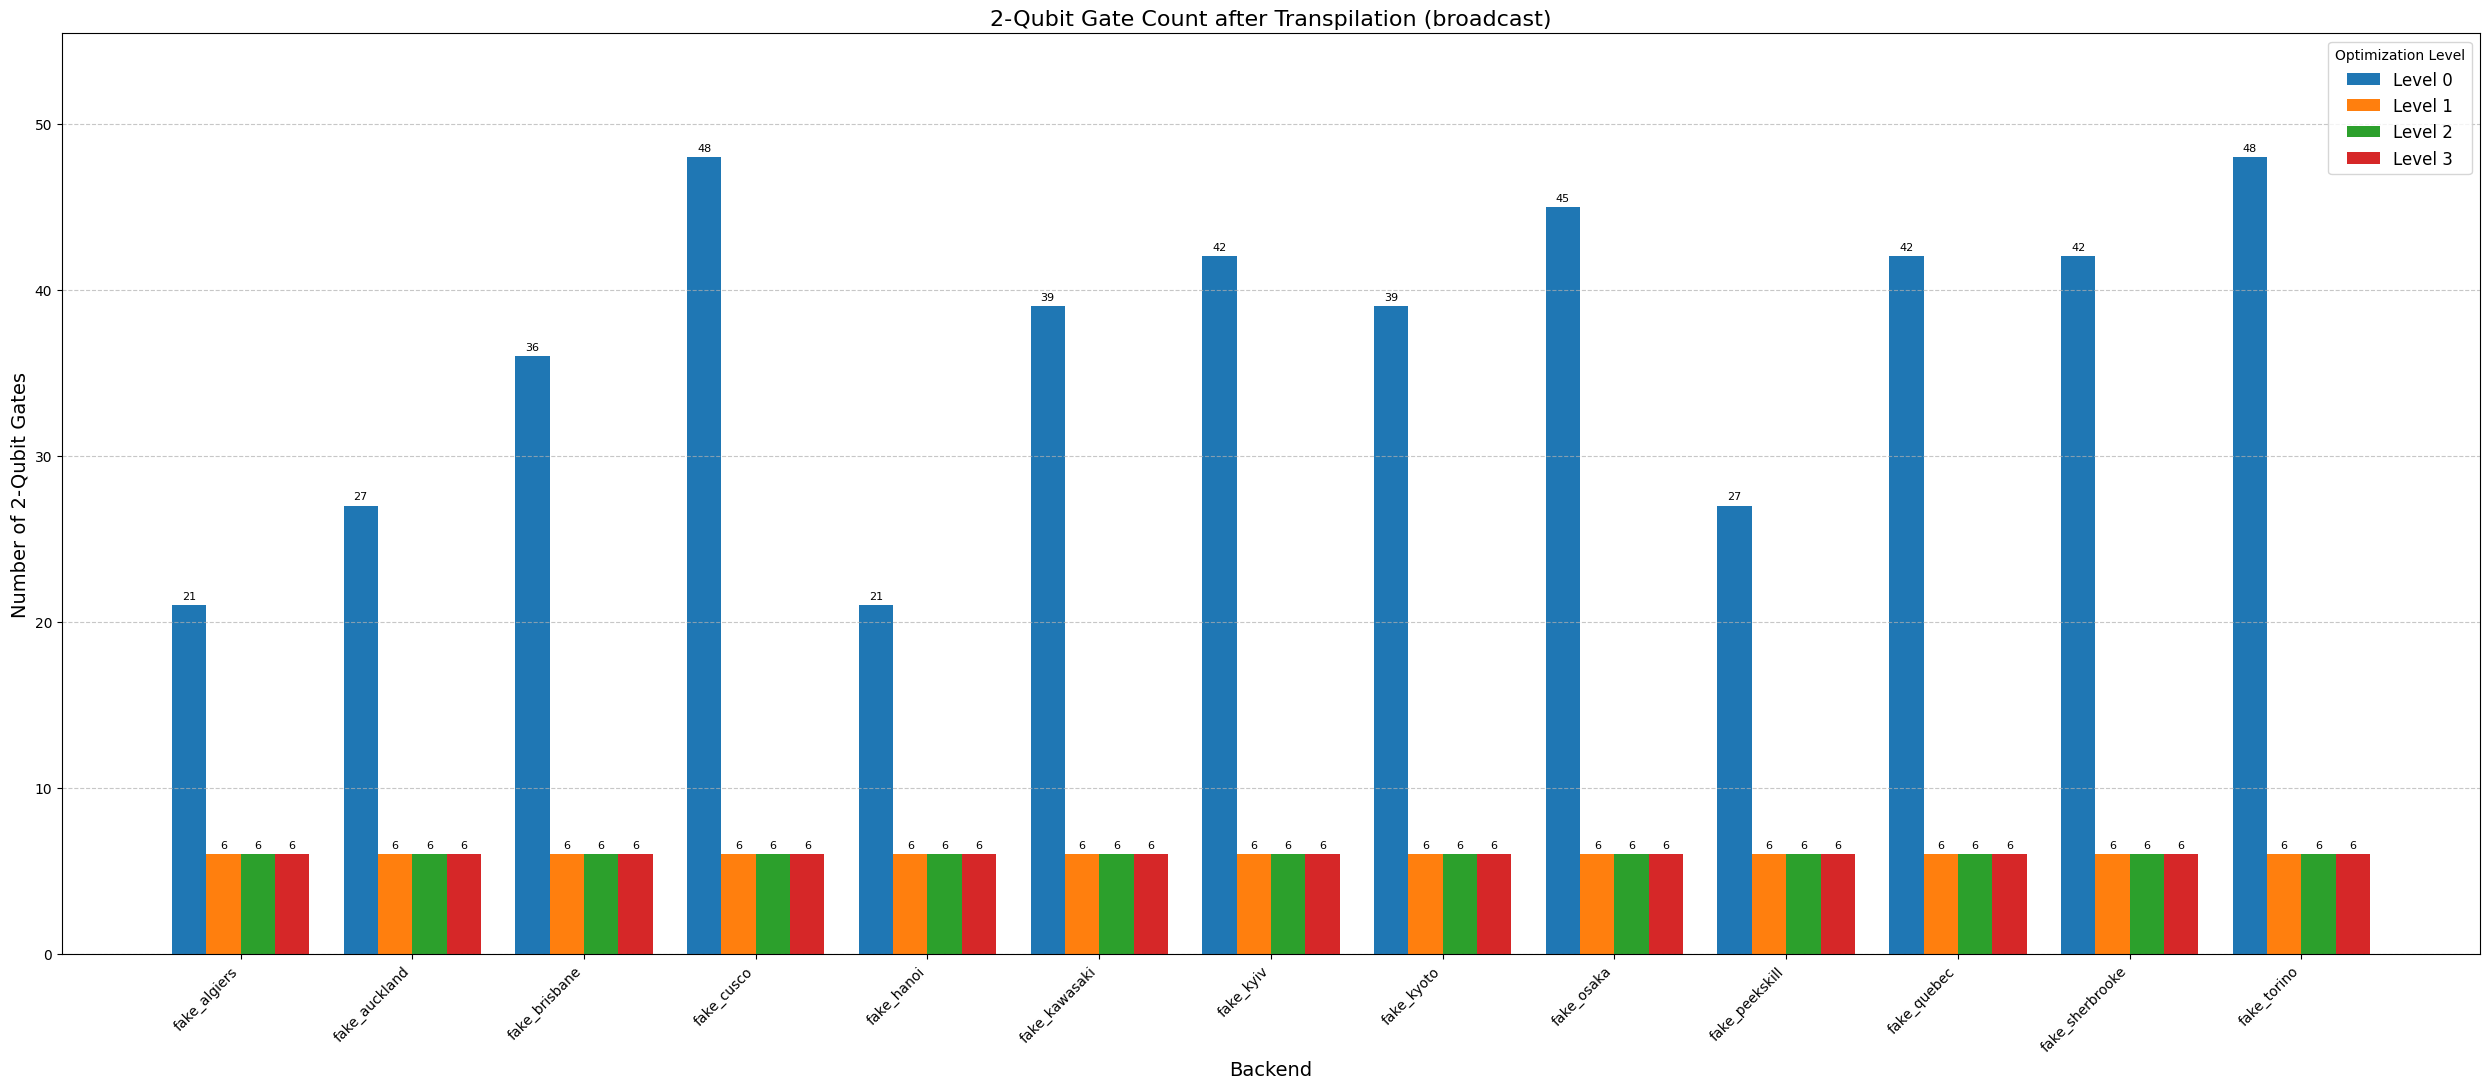

In [ ]:
bradcast_tp = transpile_circuit(qc, results)
plotting_(bradcast_tp, "broadcast")

In [ ]:
plot_backend_topo(results)

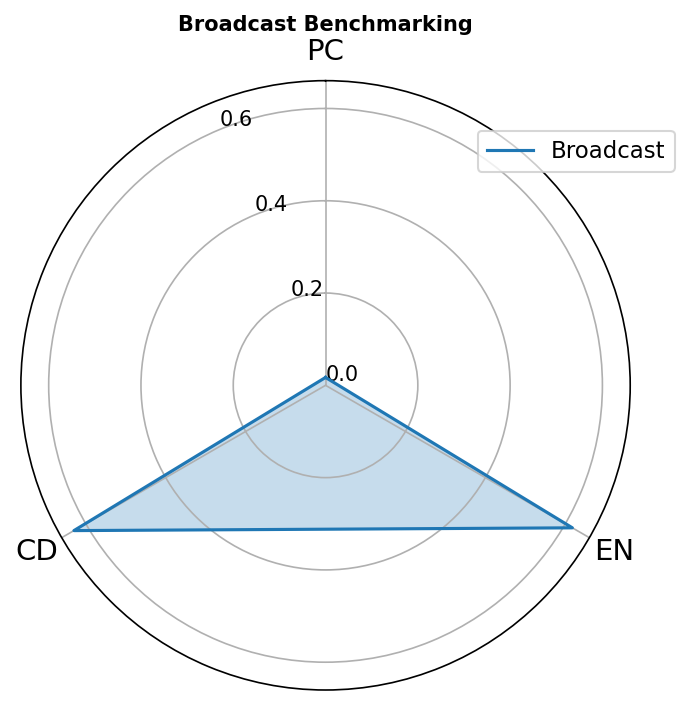

In [ ]:
send_feat = [
  converters.compute_communication_with_qiskit(transpile(qc, backend=FakeAlgiers(), optimization_level=0)),
  converters.compute_depth_with_qiskit(transpile(qc, backend=FakeAlgiers(), optimization_level=0)),
  converters.compute_entanglement_with_qiskit(transpile(qc, backend=FakeAlgiers(), optimization_level=0)),
  #converters.compute_liveness_with_qiskit(transpiled_circuit),
  #converters.compute_measurement_with_qiskit(transpiled_circuit),
  #converters.compute_parallelism_with_qiskit(transpiled_circuit)
]

spoke_labels = ["PC", "CD", "EN"]
plotting.plot_benchmark(
    title="Broadcast Benchmarking",
    labels=["Broadcast"],             # one label
    features=[send_feat],        # must be a list of feature lists
    spoke_labels=spoke_labels,
    show=True
)

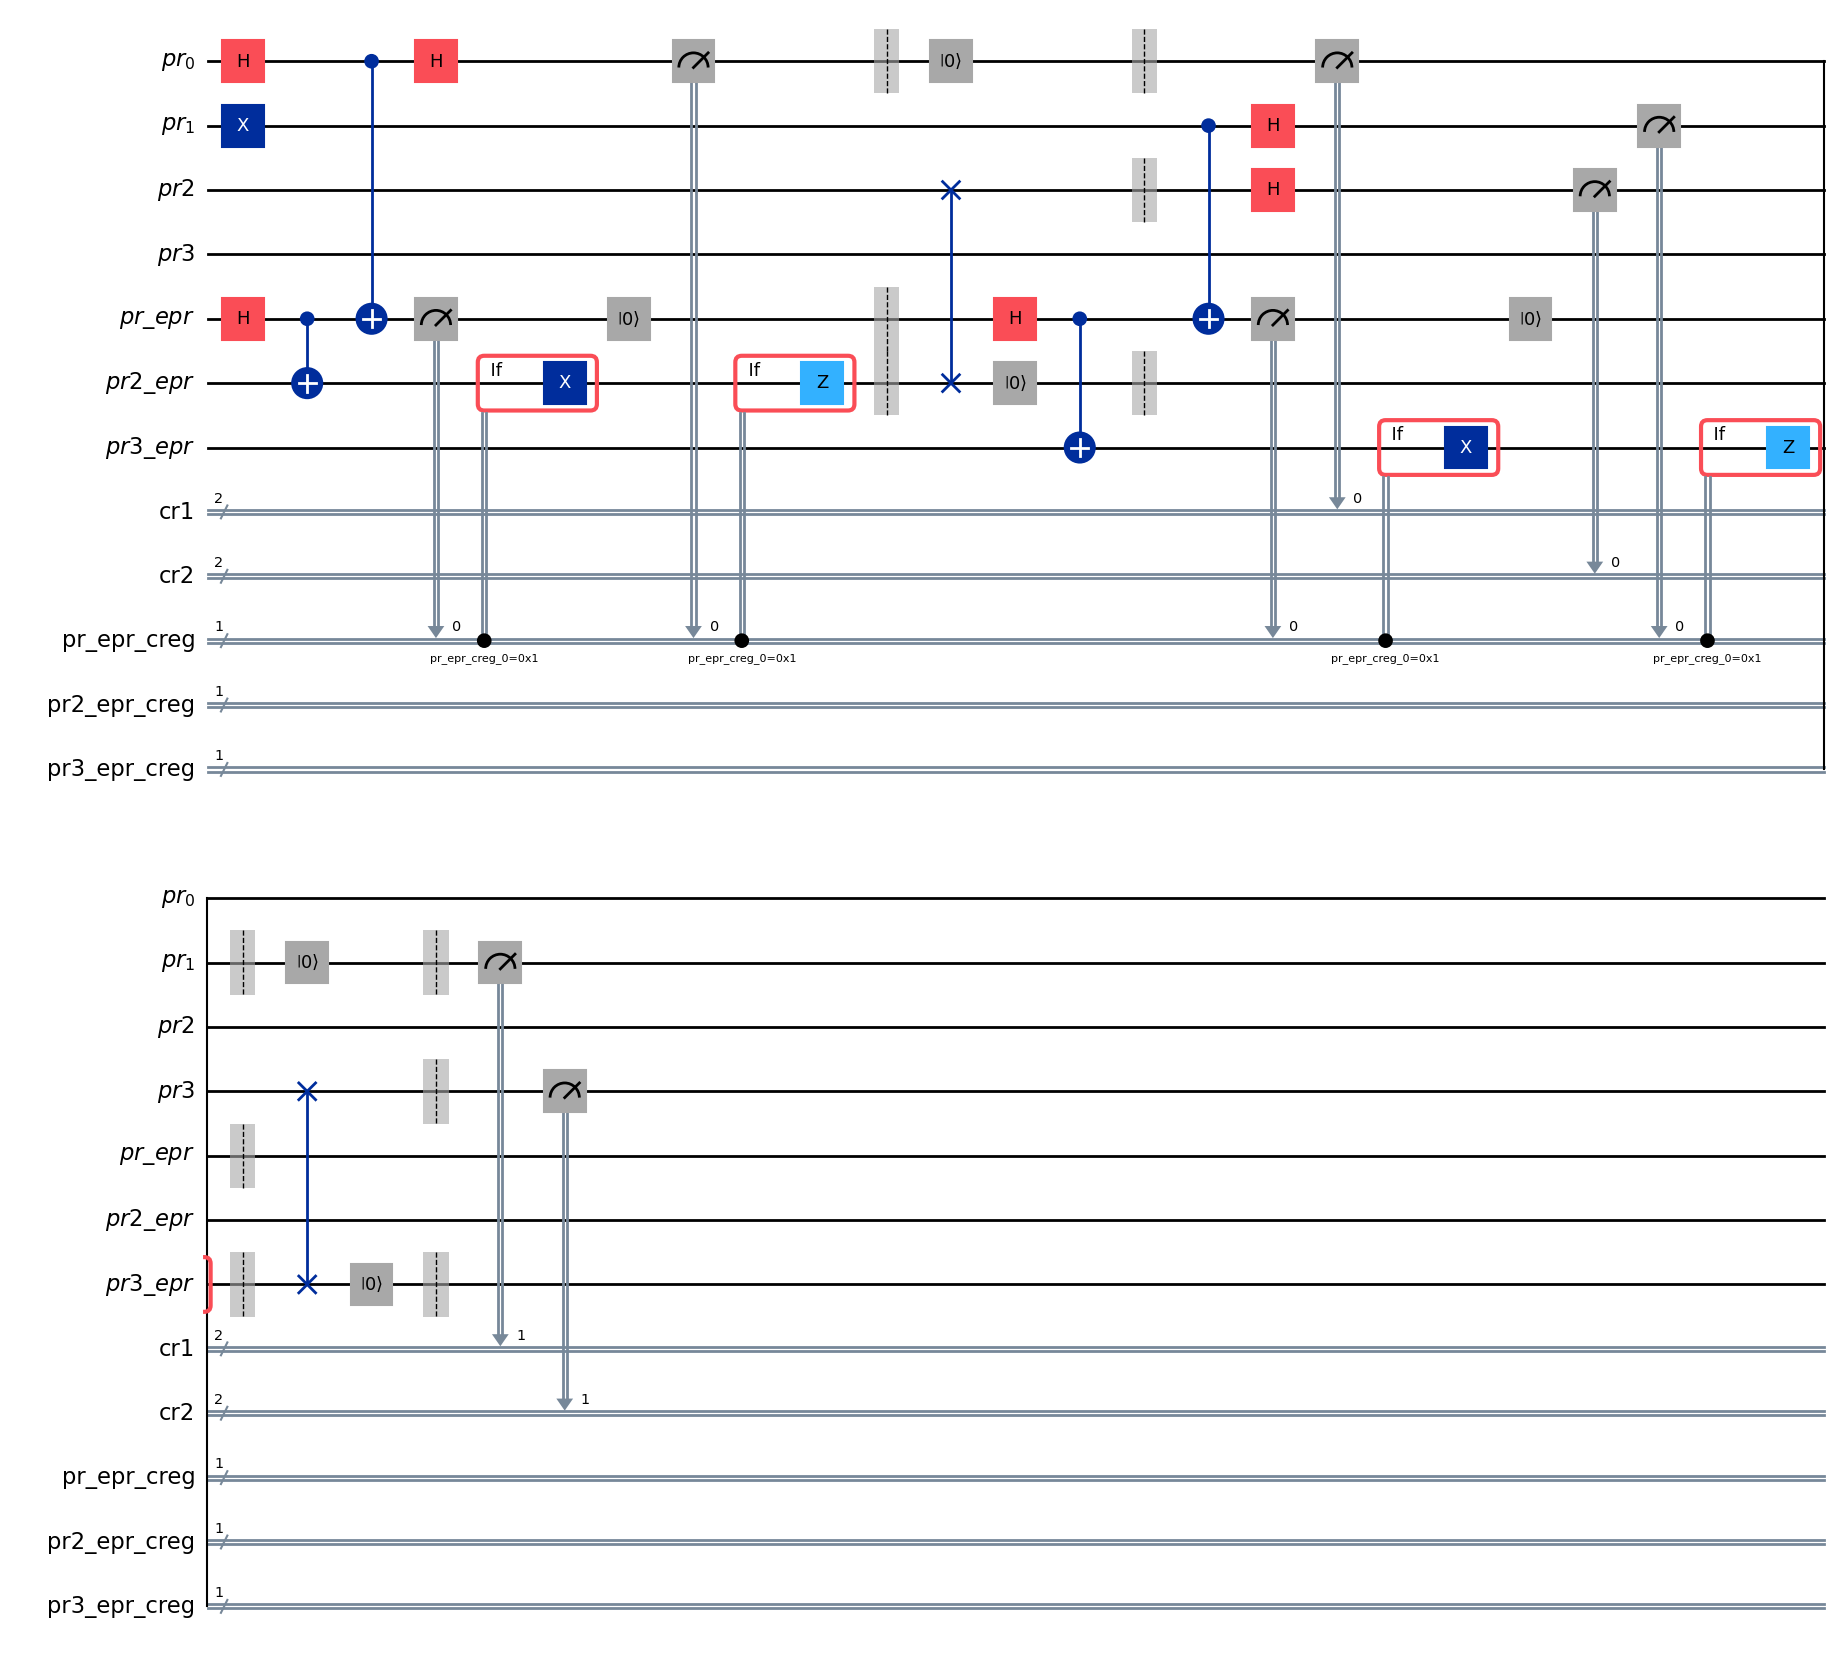

In [ ]:
# check out scatter
pp = QuantumCircuit()
pr = QuantumRegister(2, 'pr')
pr2 = QuantumRegister(1, 'pr2')
pr3 = QuantumRegister(1, 'pr3')
cr1 = ClassicalRegister(2, 'cr1')
cr2 = ClassicalRegister(2, 'cr2')
pp.add_register(pr,pr2,pr3,cr1,cr2)
pp.h(pr[0])
pp.x(pr[1])
m = MPI_collective.CollectiveMPI(pp, pr, n=1)
m.scatter([pr[0], pr[1]], [pr2[0],pr3[0]])
pp.h(pr2[0])
pp.measure([pr[0],pr[1], pr2[0],pr3[0]], [cr1[0],cr1[1], cr2[0],cr2[1]])
pp.draw('mpl')

✅ Transpiled สำเร็จ: Backend=fake_algiers, Level=0, 2-Qubit Gates=37
✅ Transpiled สำเร็จ: Backend=fake_algiers, Level=1, 2-Qubit Gates=13
✅ Transpiled สำเร็จ: Backend=fake_algiers, Level=2, 2-Qubit Gates=7
✅ Transpiled สำเร็จ: Backend=fake_algiers, Level=3, 2-Qubit Gates=7
❌ Transpiled ไม่สำเร็จ: Backend=fake_almaden, Level=0. Error: "The control-flow construct 'if_else' is not supported by the backend."
❌ Transpiled ไม่สำเร็จ: Backend=fake_almaden, Level=1. Error: "The control-flow construct 'if_else' is not supported by the backend."
❌ Transpiled ไม่สำเร็จ: Backend=fake_almaden, Level=2. Error: "The control-flow construct 'if_else' is not supported by the backend."
❌ Transpiled ไม่สำเร็จ: Backend=fake_almaden, Level=3. Error: "The control-flow construct 'if_else' is not supported by the backend."
❌ Transpiled ไม่สำเร็จ: Backend=fake_armonk, Level=0. Error: 'Number of qubits (7) in circuit-2061 is greater than maximum (1) in the coupling_map'
❌ Transpiled ไม่สำเร็จ: Backend=fake_armon

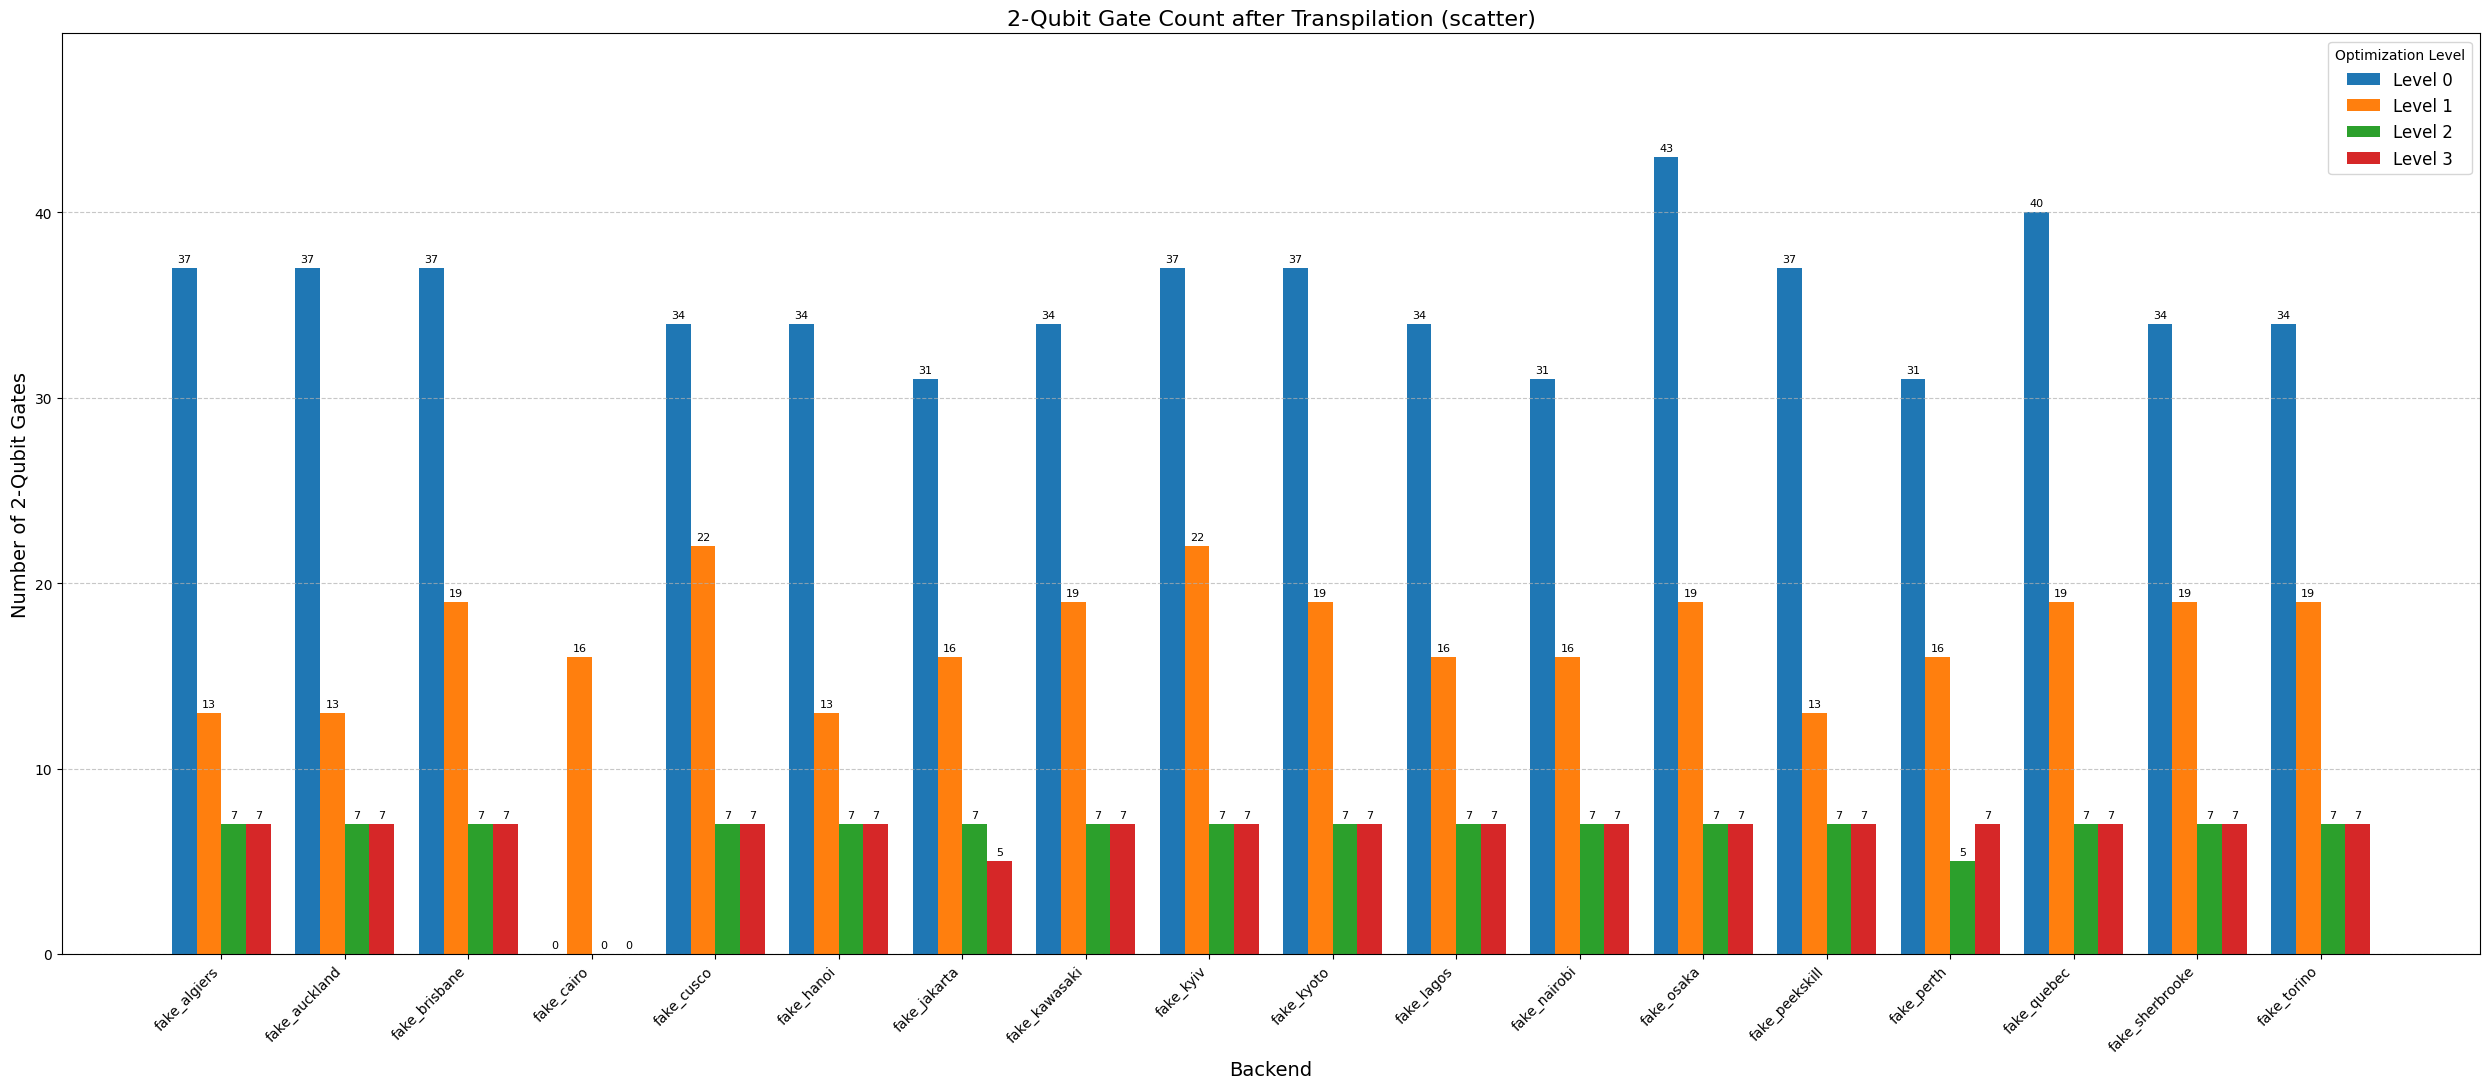

In [ ]:
scatter_tp = transpile_circuit(pp, results)
plotting_(scatter_tp, "scatter")

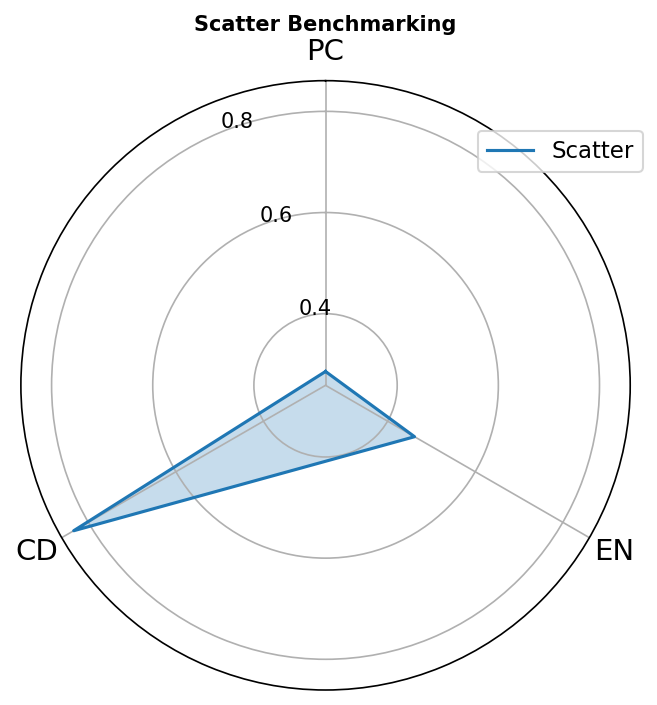

In [ ]:
send_feat = [
  converters.compute_communication_with_qiskit(pp),
  converters.compute_depth_with_qiskit(pp),
  converters.compute_entanglement_with_qiskit(pp),
  #converters.compute_liveness_with_qiskit(transpiled_circuit),
  #converters.compute_measurement_with_qiskit(transpiled_circuit),
  #converters.compute_parallelism_with_qiskit(transpiled_circuit)
]

spoke_labels = ["PC", "CD", "EN"]
plotting.plot_benchmark(
    title="Scatter Benchmarking",
    labels=["Scatter"],             # one label
    features=[send_feat],        # must be a list of feature lists
    spoke_labels=spoke_labels,
    show=True
)

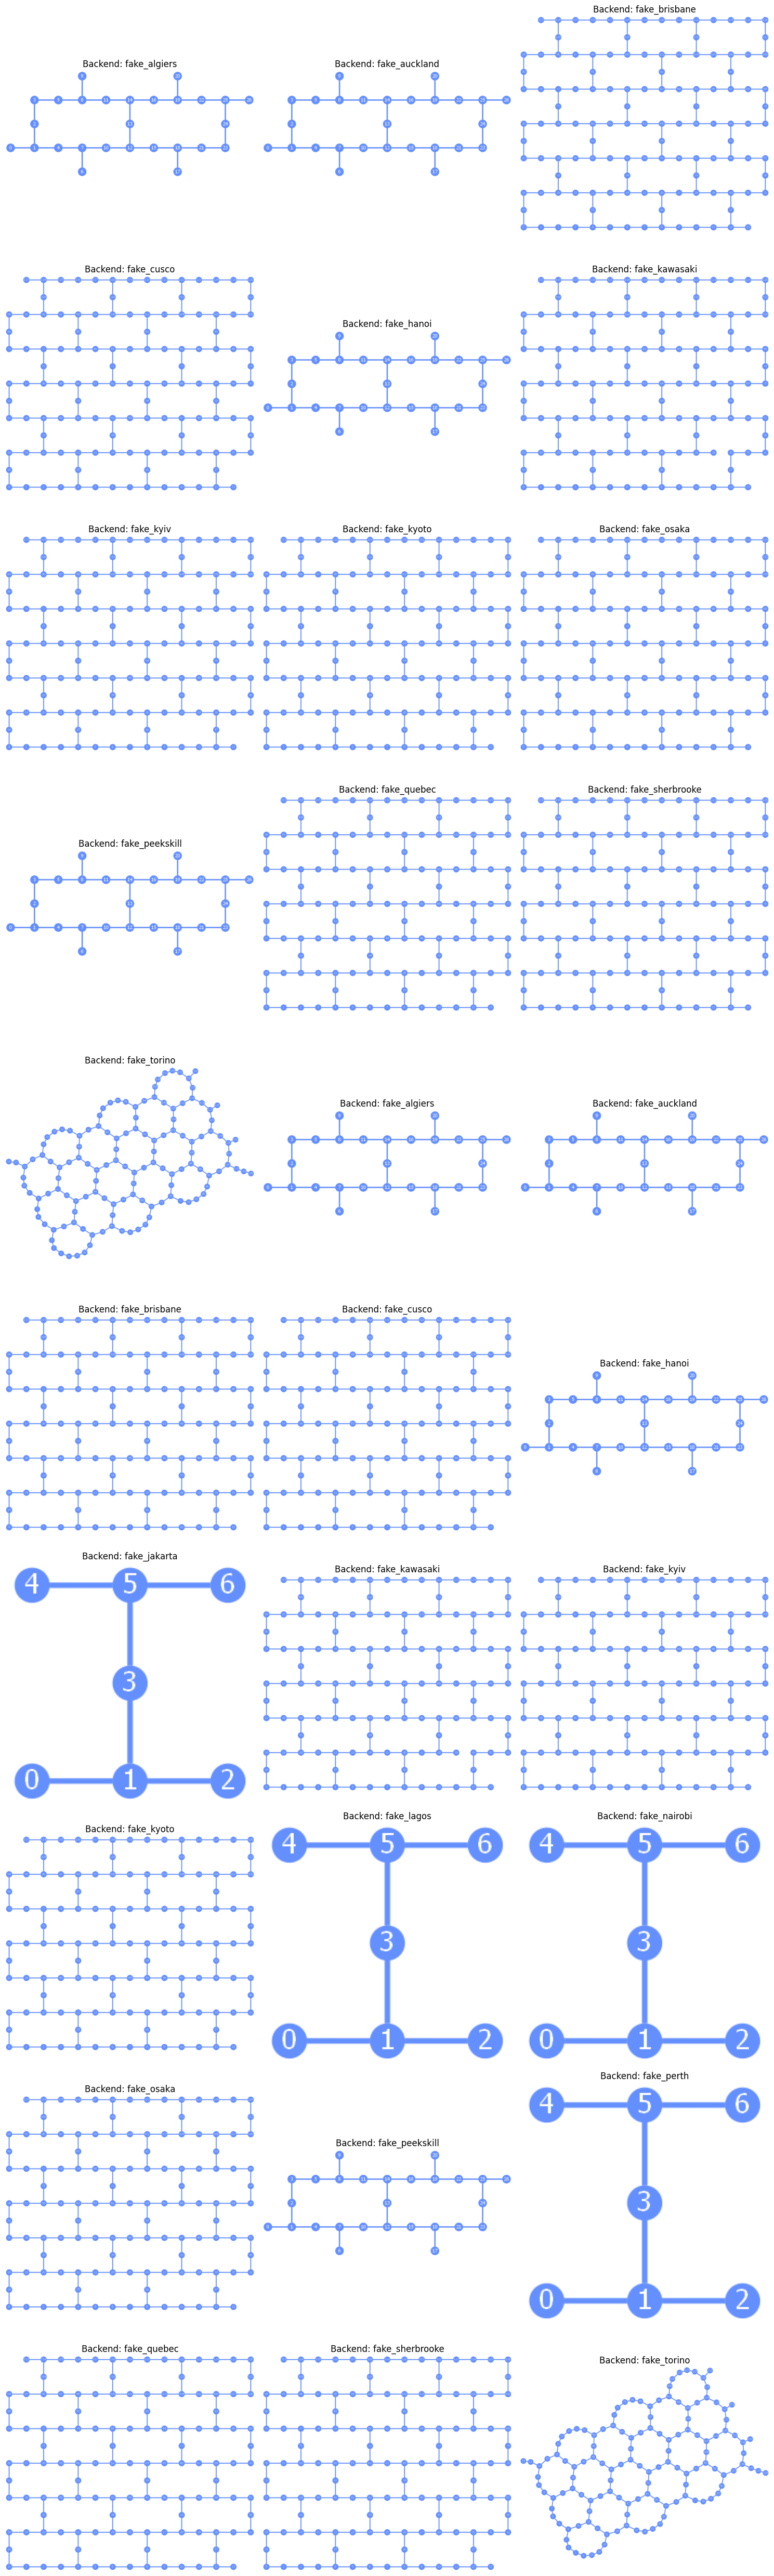

In [ ]:
plot_backend_topo(scatter_tp)

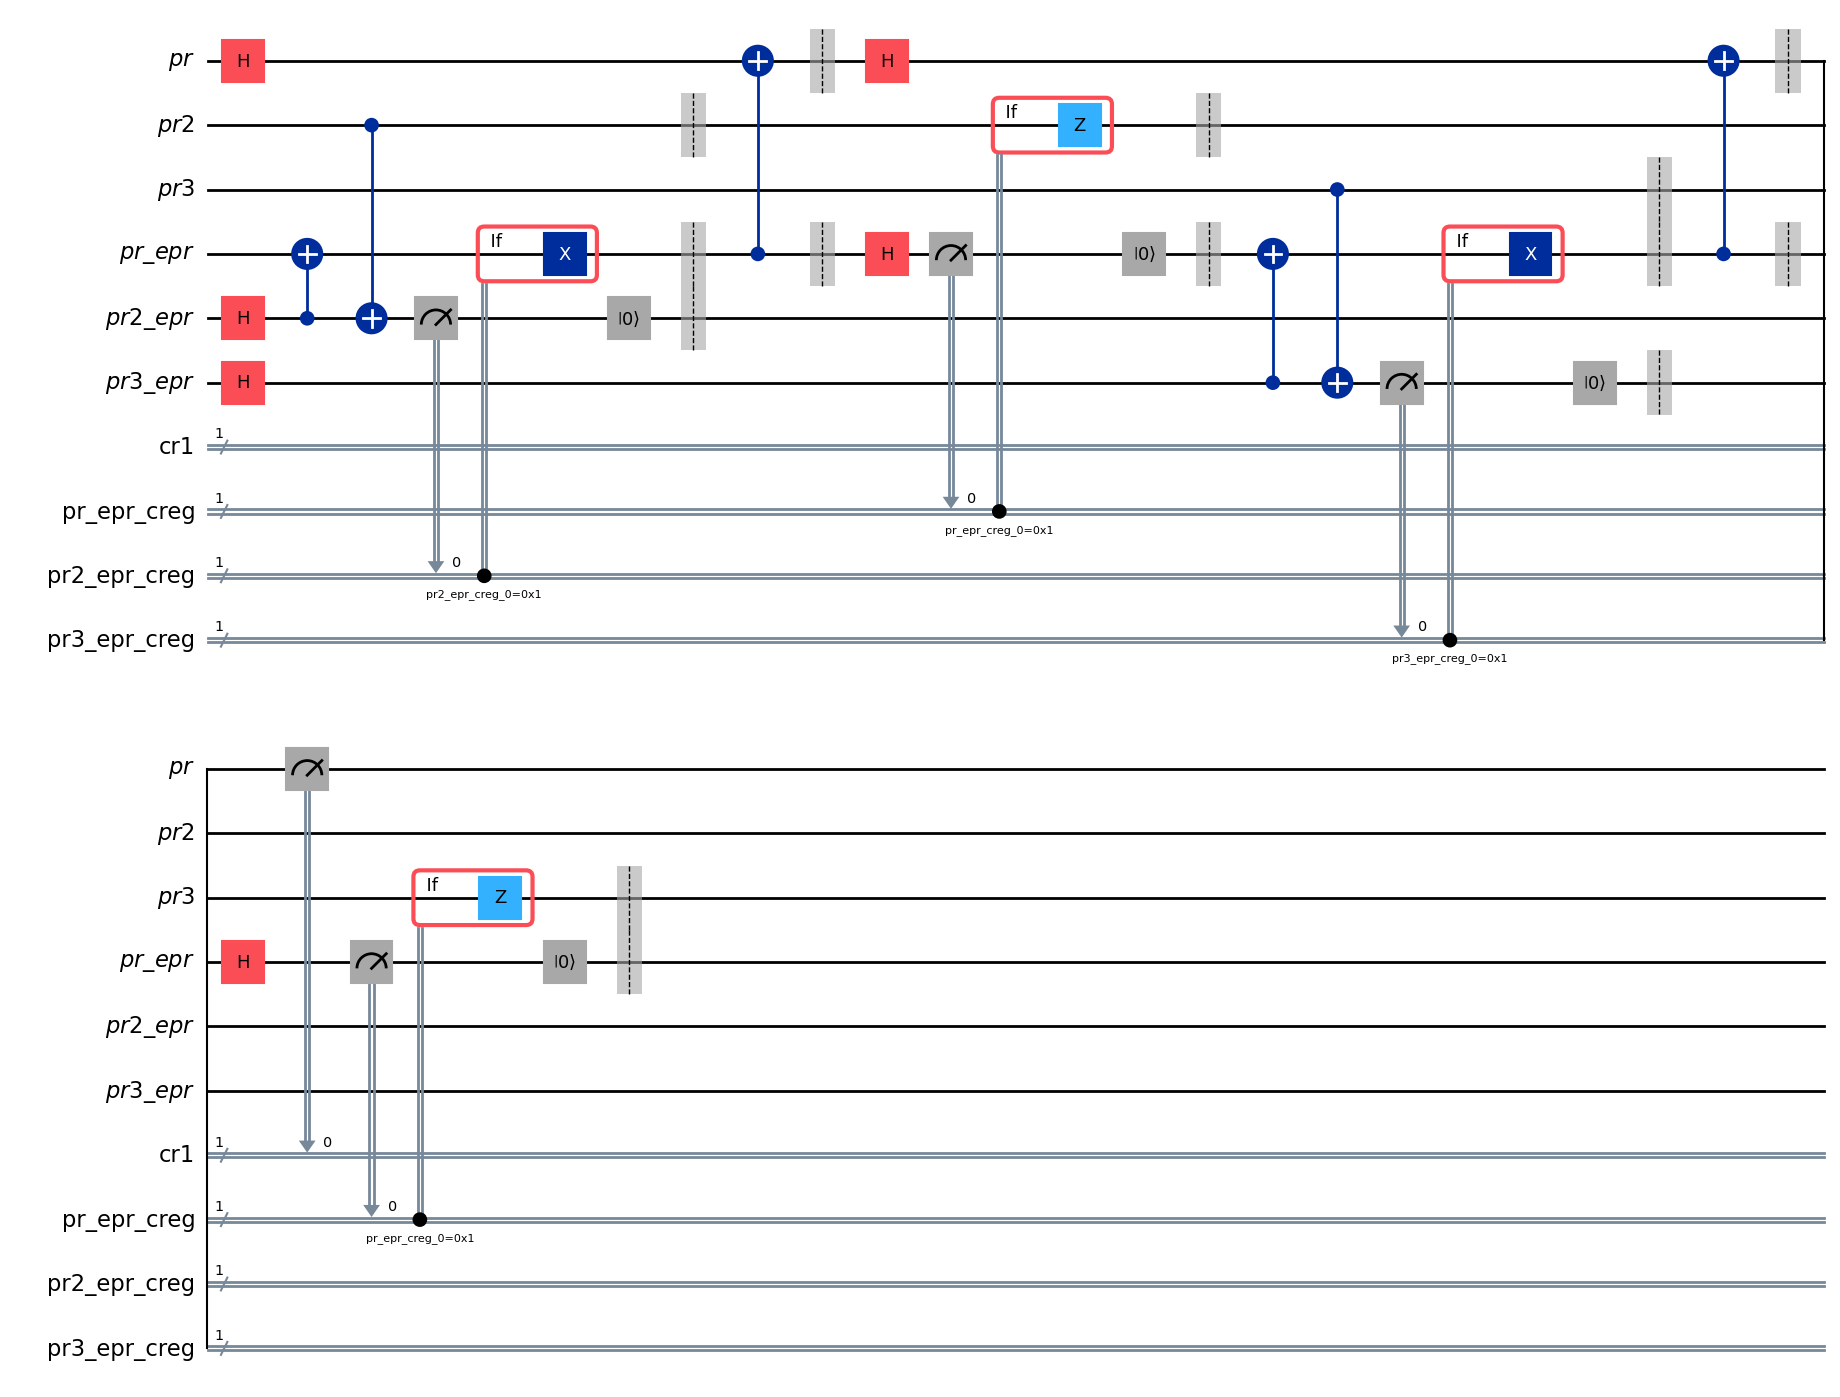

In [ ]:
# check out reduce (แก้จาก sequential reduce)
pp = QuantumCircuit()
pr = QuantumRegister(1, 'pr')
pr2 = QuantumRegister(1, 'pr2')
pr3 = QuantumRegister(1, 'pr3')
#target = QuantumRegister(1, 'target')  # เพิ่ม target qubit
cr1 = ClassicalRegister(1, 'cr1')      # เปลี่ยนเป็น 1 bit (วัดแค่ target)
pp.add_register(pr, pr2, pr3, cr1)
#pp.h([pr[0], pr[1], pr[2]])
m = MPI_collective.CollectiveMPI(pp, pr, n=1)

ppp = QuantumCircuit(2)
ppp.h(1)
ppp.cx(0, 1)

# เปลี่ยนจาก sequentialReduce เป็น reduce
m.reduce([pr2[0], pr3[0]], pr[0], ppp)  # รวมทุกอย่างไปที่ target[0]

pp.measure(pr[0], cr1[0])  # วัดแค่ target qubit
pp.draw('mpl')

✅ Transpiled สำเร็จ: Backend=fake_algiers, Level=0, 2-Qubit Gates=18
✅ Transpiled สำเร็จ: Backend=fake_algiers, Level=1, 2-Qubit Gates=6
✅ Transpiled สำเร็จ: Backend=fake_algiers, Level=2, 2-Qubit Gates=6
✅ Transpiled สำเร็จ: Backend=fake_algiers, Level=3, 2-Qubit Gates=6
❌ Transpiled ไม่สำเร็จ: Backend=fake_almaden, Level=0. Error: "The control-flow construct 'if_else' is not supported by the backend."
❌ Transpiled ไม่สำเร็จ: Backend=fake_almaden, Level=1. Error: "The control-flow construct 'if_else' is not supported by the backend."
❌ Transpiled ไม่สำเร็จ: Backend=fake_almaden, Level=2. Error: "The control-flow construct 'if_else' is not supported by the backend."
❌ Transpiled ไม่สำเร็จ: Backend=fake_almaden, Level=3. Error: "The control-flow construct 'if_else' is not supported by the backend."
❌ Transpiled ไม่สำเร็จ: Backend=fake_armonk, Level=0. Error: 'Number of qubits (6) in circuit-2246 is greater than maximum (1) in the coupling_map'
❌ Transpiled ไม่สำเร็จ: Backend=fake_armonk

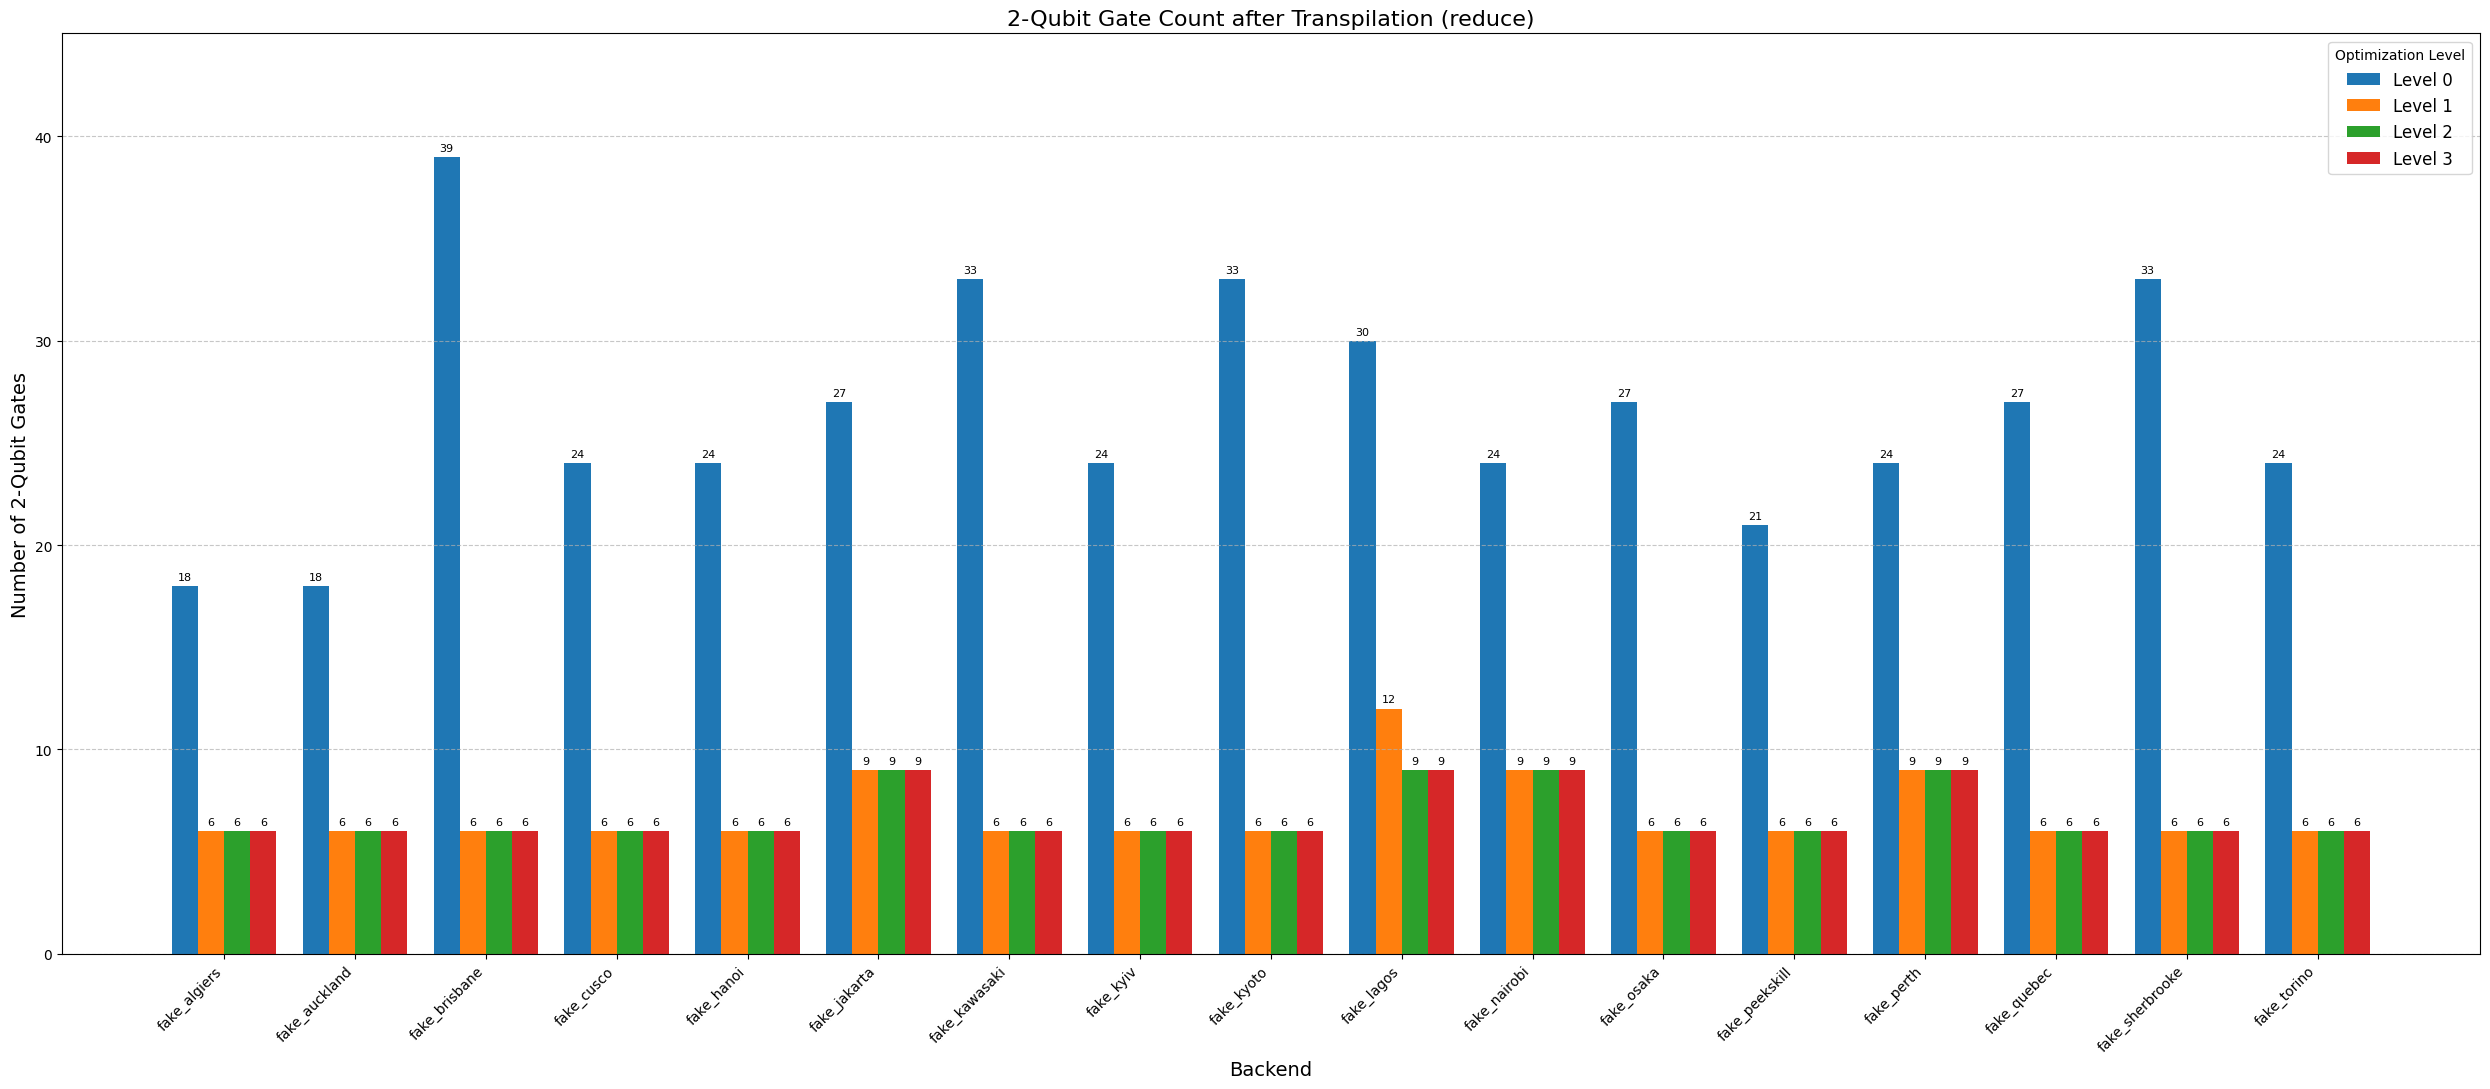

In [ ]:
plotting_(transpile_circuit(pp, results), "reduce")

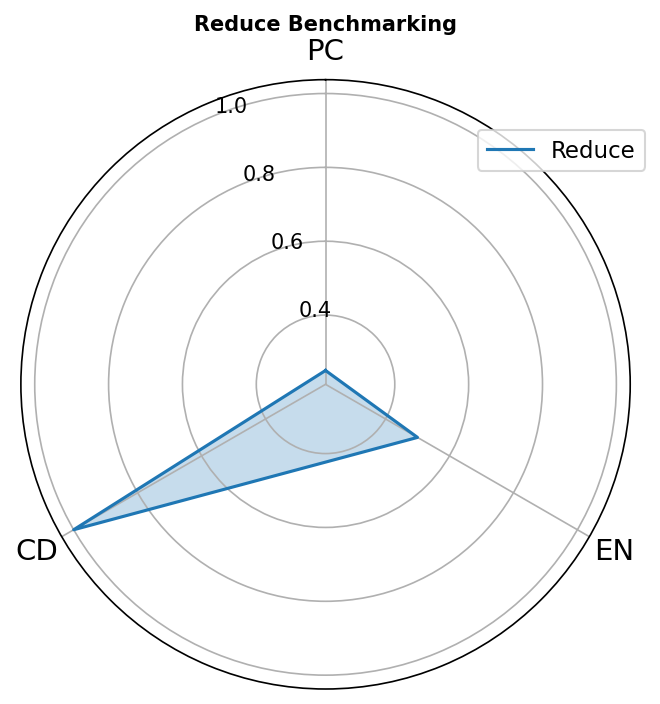

In [ ]:
send_feat = [
  converters.compute_communication_with_qiskit(pp),
  converters.compute_depth_with_qiskit(pp),
  converters.compute_entanglement_with_qiskit(pp),
  #converters.compute_liveness_with_qiskit(transpiled_circuit),
  #converters.compute_measurement_with_qiskit(transpiled_circuit),
  #converters.compute_parallelism_with_qiskit(transpiled_circuit)
]

spoke_labels = ["PC", "CD", "EN"]
plotting.plot_benchmark(
    title="Reduce Benchmarking",
    labels=["Reduce"],             # one label
    features=[send_feat],        # must be a list of feature lists
    spoke_labels=spoke_labels,
    show=True
)

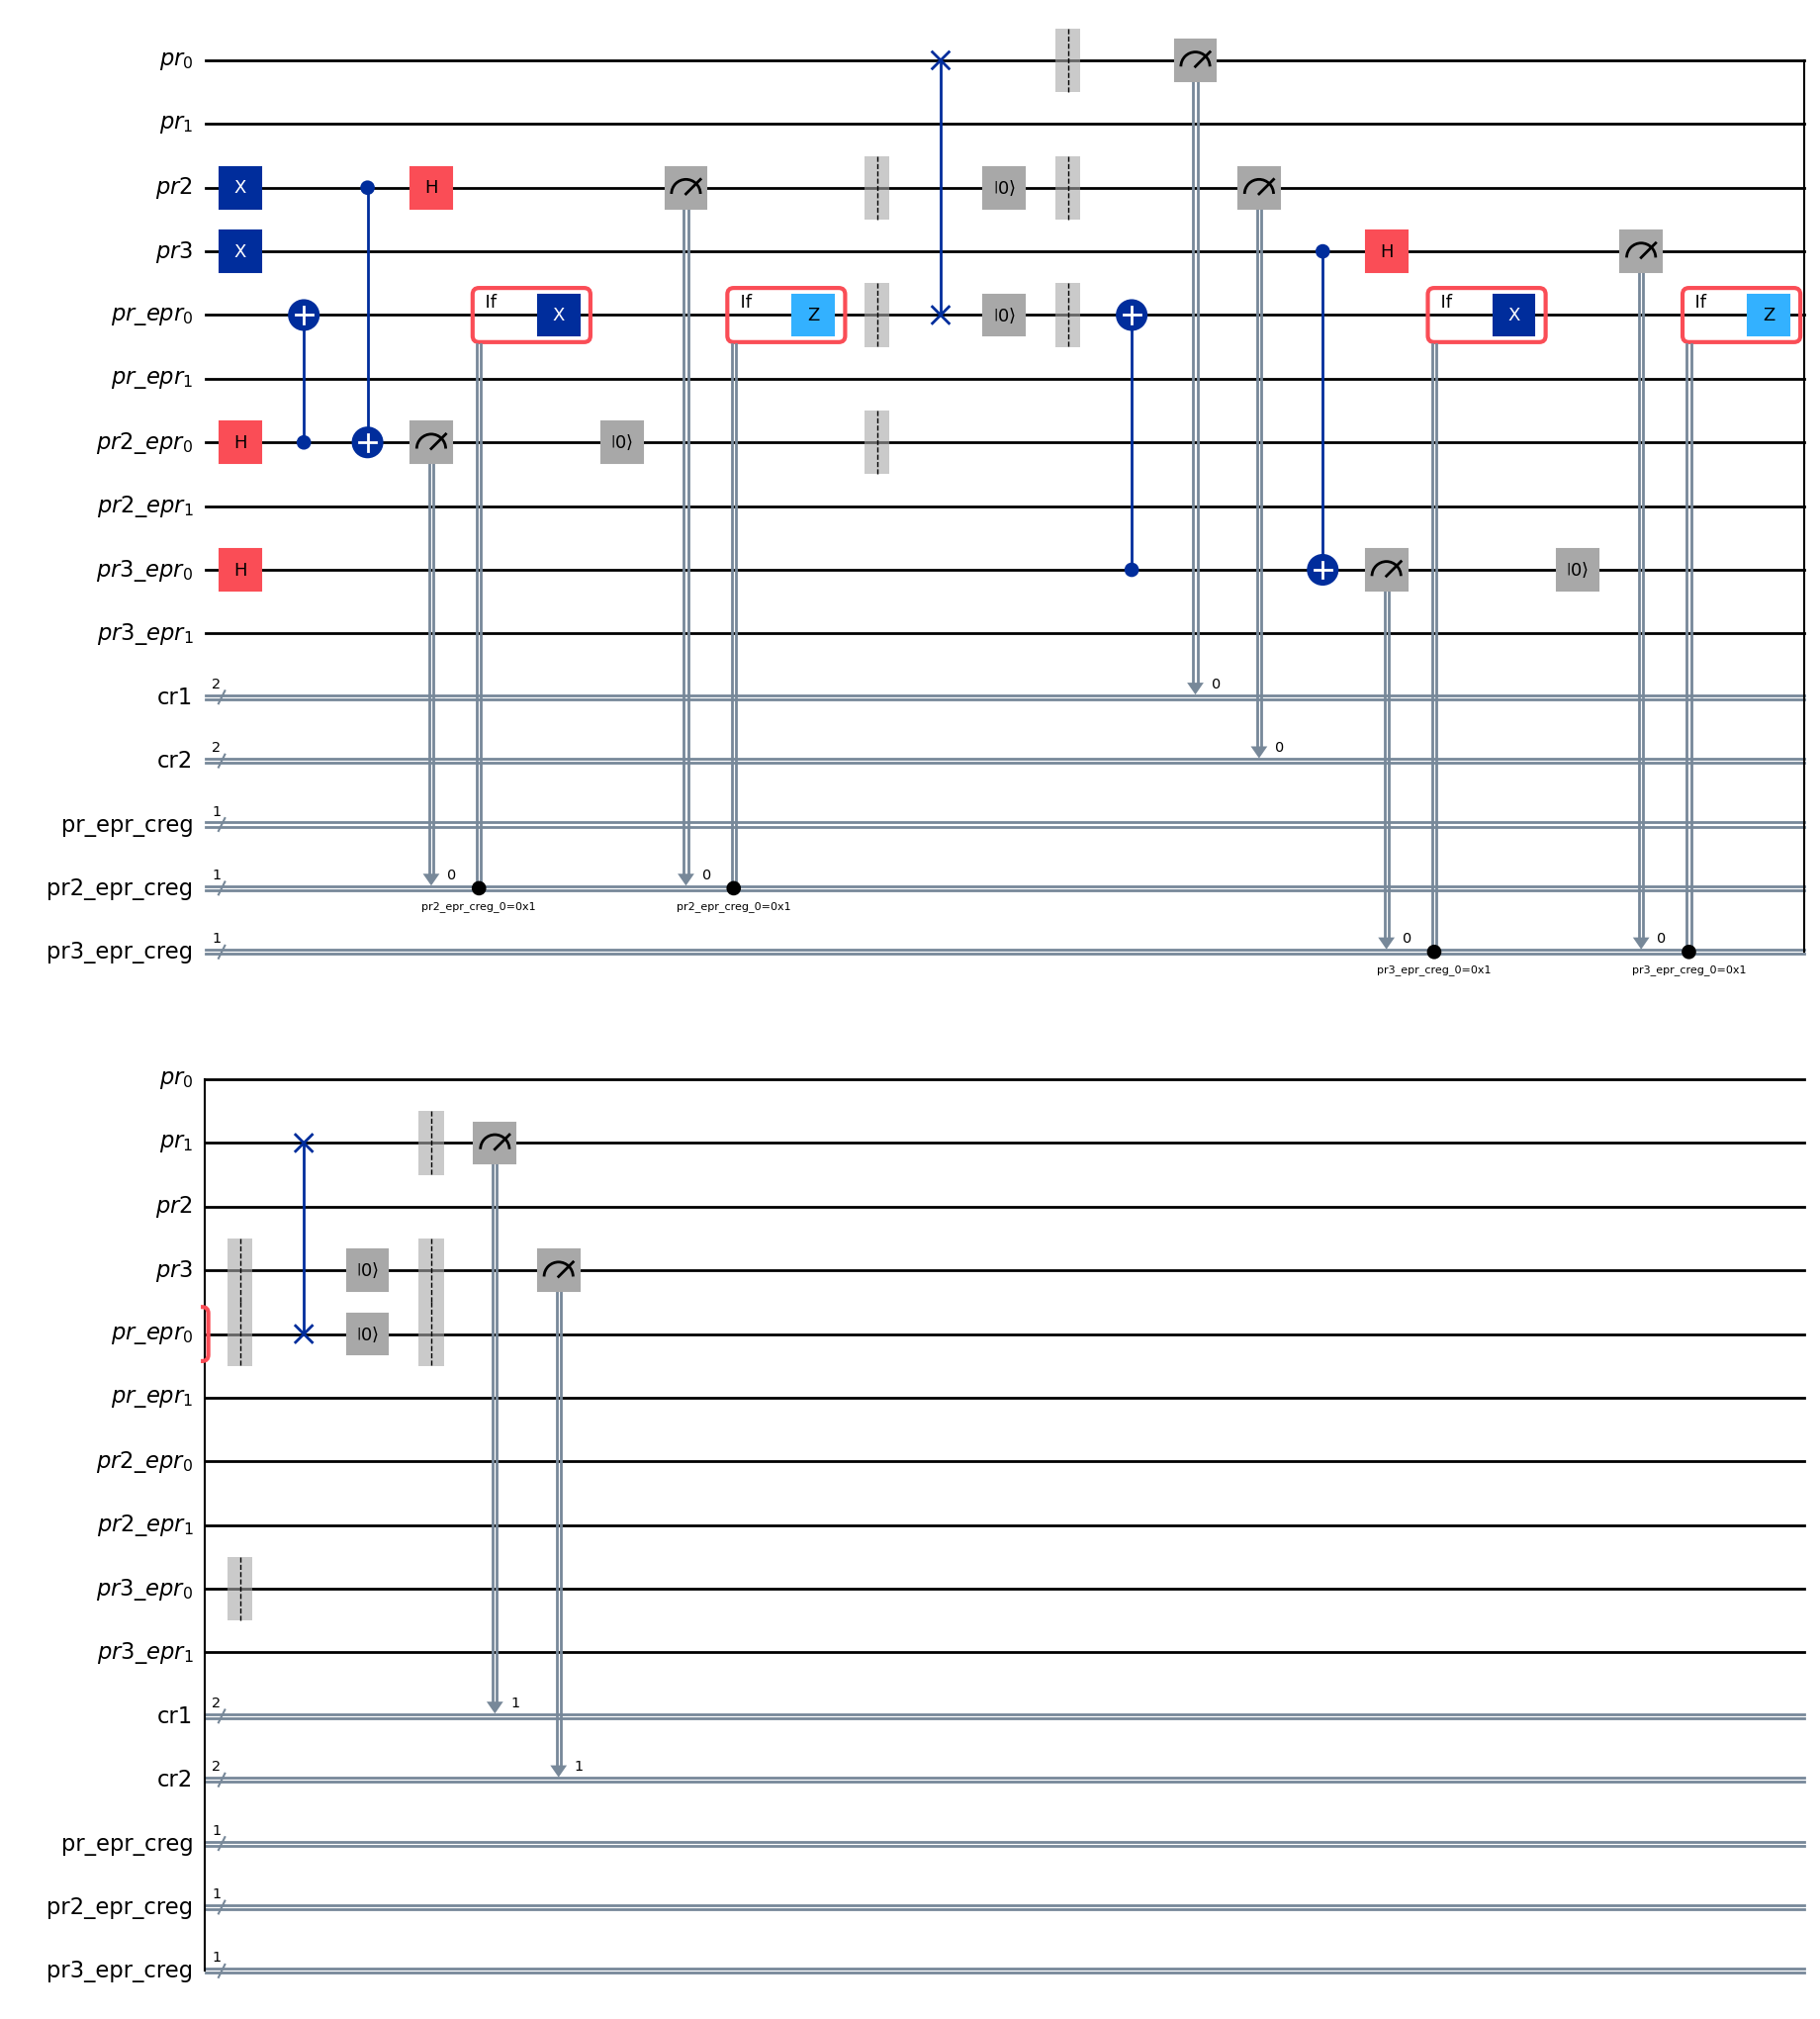

In [ ]:
# check out gather
pp = QuantumCircuit()
pr = QuantumRegister(2, 'pr')
pr2 = QuantumRegister(1, 'pr2')
pr3 = QuantumRegister(1, 'pr3')
cr1 = ClassicalRegister(2, 'cr1')
cr2 = ClassicalRegister(2, 'cr2')
cr3 = ClassicalRegister(2, 'cr3')
pp.add_register(pr,pr2,pr3,cr1,cr2)
pp.x(pr2[0])
pp.x(pr3[0])
m = MPI_collective.CollectiveMPI(pp, pr)
m.gather([pr2[0], pr3[0]], [pr[0],pr[1]])
pp.measure([pr[0],pr[1], pr2[0],pr3[0]], [cr1[0],cr1[1], cr2[0],cr2[1]])
pp.draw('mpl')

✅ Transpiled สำเร็จ: Backend=fake_algiers, Level=0, 2-Qubit Gates=34
✅ Transpiled สำเร็จ: Backend=fake_algiers, Level=1, 2-Qubit Gates=13
✅ Transpiled สำเร็จ: Backend=fake_algiers, Level=2, 2-Qubit Gates=4
✅ Transpiled สำเร็จ: Backend=fake_algiers, Level=3, 2-Qubit Gates=4
❌ Transpiled ไม่สำเร็จ: Backend=fake_almaden, Level=0. Error: "The control-flow construct 'if_else' is not supported by the backend."
❌ Transpiled ไม่สำเร็จ: Backend=fake_almaden, Level=1. Error: "The control-flow construct 'if_else' is not supported by the backend."
❌ Transpiled ไม่สำเร็จ: Backend=fake_almaden, Level=2. Error: "The control-flow construct 'if_else' is not supported by the backend."
❌ Transpiled ไม่สำเร็จ: Backend=fake_almaden, Level=3. Error: "The control-flow construct 'if_else' is not supported by the backend."
❌ Transpiled ไม่สำเร็จ: Backend=fake_armonk, Level=0. Error: 'Number of qubits (10) in circuit-11028 is greater than maximum (1) in the coupling_map'
❌ Transpiled ไม่สำเร็จ: Backend=fake_arm

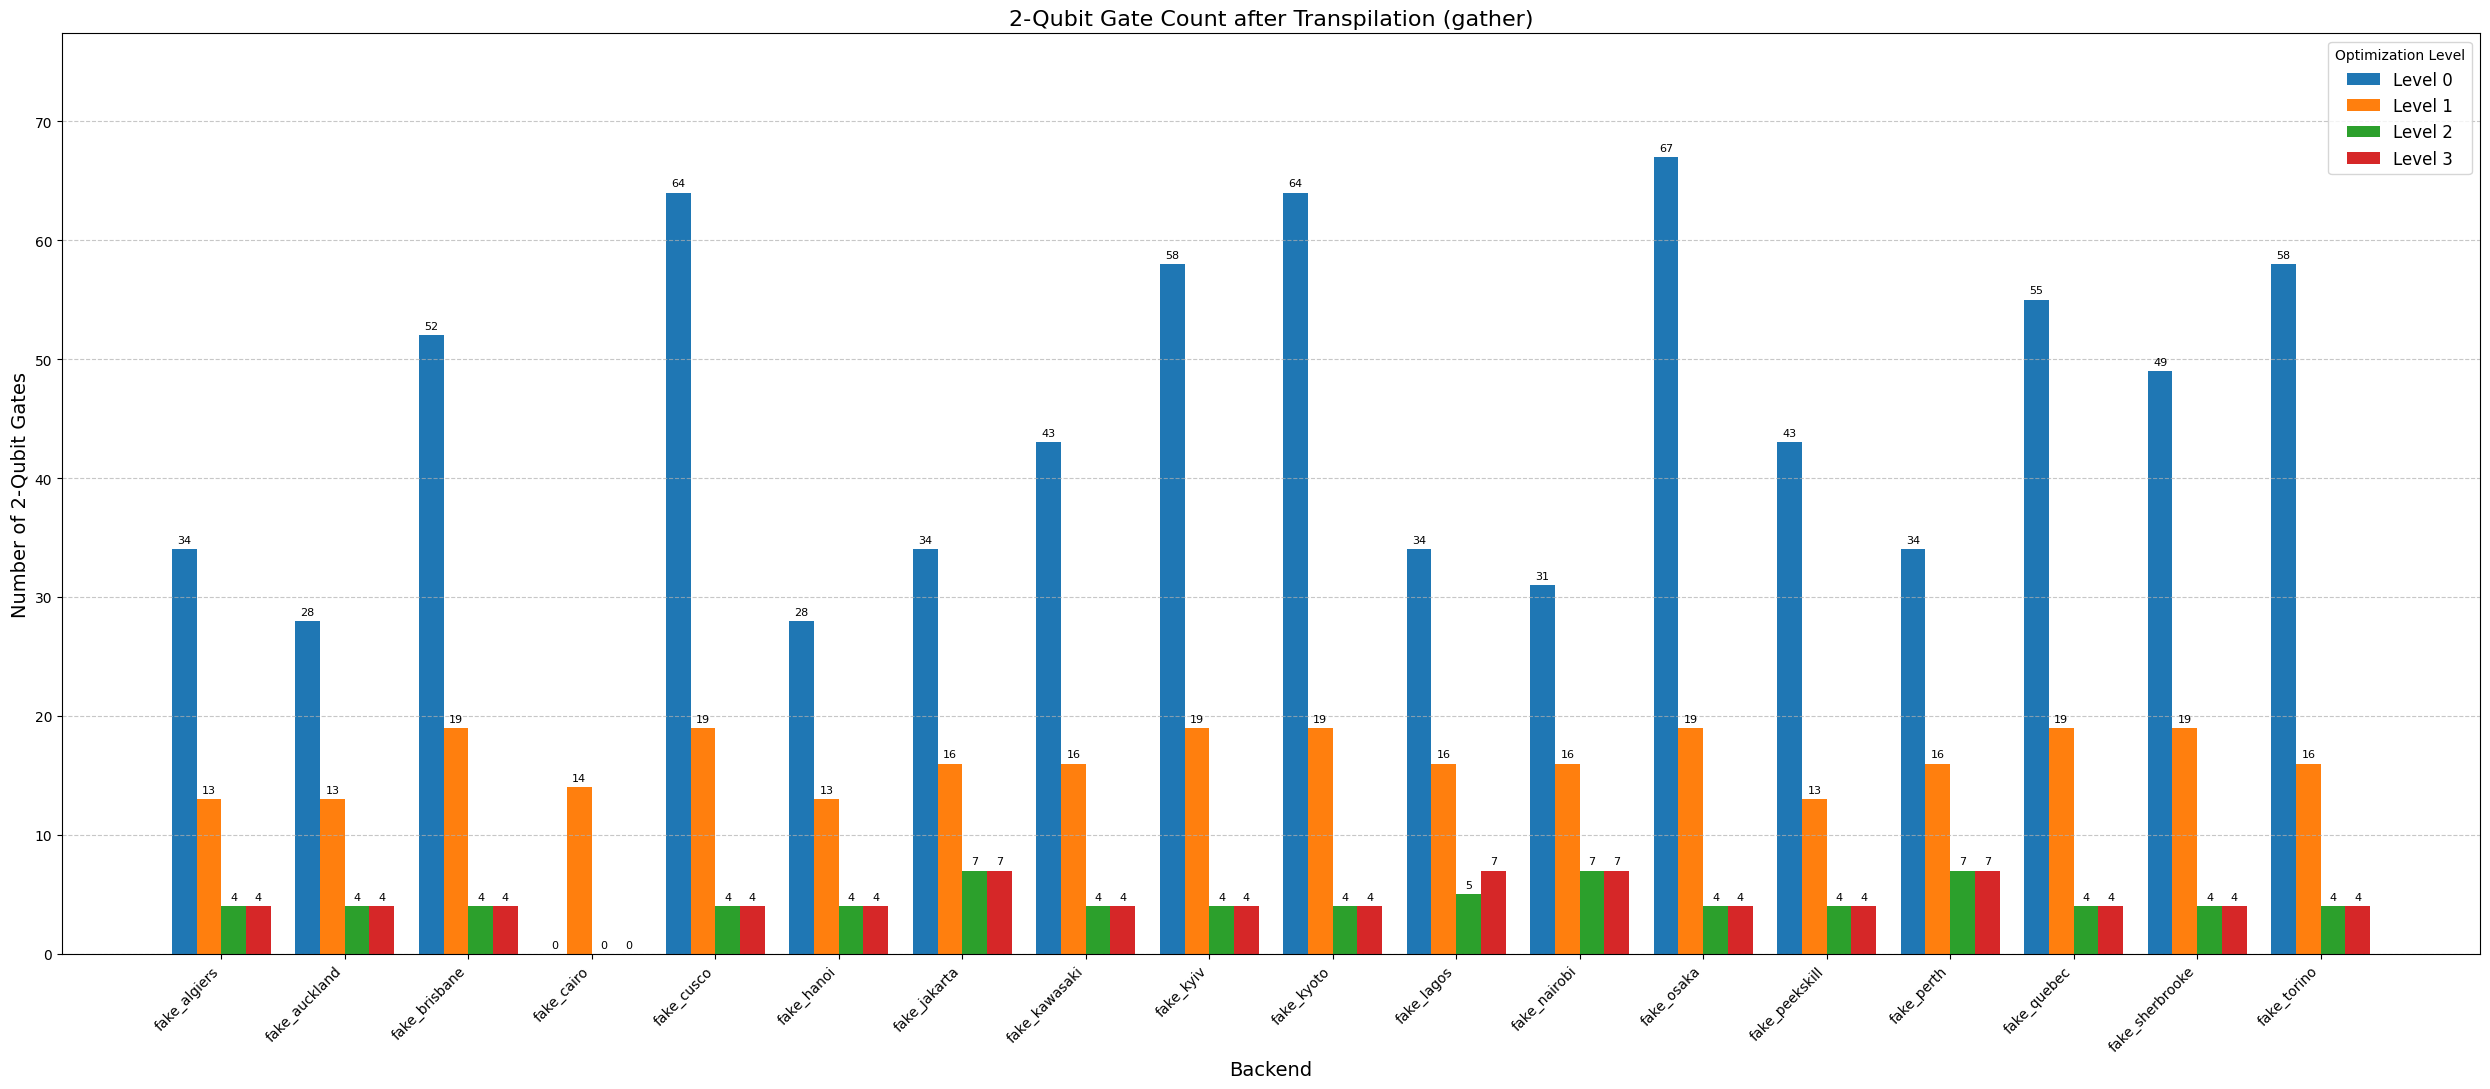

In [ ]:
plotting_(transpile_circuit(pp, results), "gather")

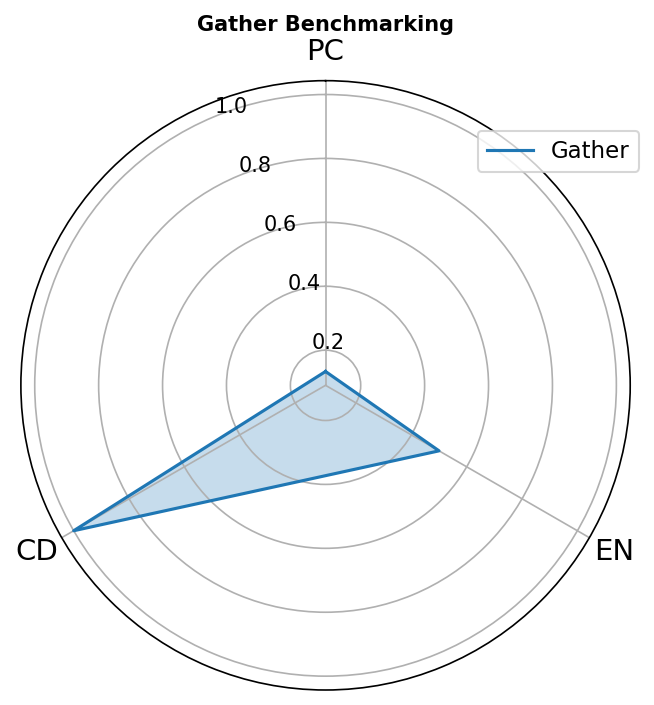

In [ ]:
send_feat = [
  converters.compute_communication_with_qiskit(pp),
  converters.compute_depth_with_qiskit(pp),
  converters.compute_entanglement_with_qiskit(pp),
  #converters.compute_liveness_with_qiskit(transpiled_circuit),
  #converters.compute_measurement_with_qiskit(transpiled_circuit),
  #converters.compute_parallelism_with_qiskit(transpiled_circuit)
]

spoke_labels = ["PC", "CD", "EN"]
plotting.plot_benchmark(
    title="Gather Benchmarking",
    labels=["Gather"],             # one label
    features=[send_feat],        # must be a list of feature lists
    spoke_labels=spoke_labels,
    show=True
)

In [ ]:
# check out allGather
pp = QuantumCircuit()
# สร้าง 3 nodes (แต่ละ node มี 3 qubits เพื่อรับข้อมูลจาก node อื่น)
pr = QuantumRegister(2, 'pr')    # node 0
pr2 = QuantumRegister(2, 'pr2')  # node 1
cr = ClassicalRegister(4, 'cr')  # วัดทั้งหมด 4 qubits
pp.add_register(pr, pr2, cr)

# เตรียมข้อมูลเริ่มต้นที่แต่ละ node (qubit แรกของแต่ละ node)
pp.x(pr[0])    # node 0 มีข้อมูล |1⟩
pp.h(pr2[0])   # node 1 มีข้อมูล |+⟩

m = MPI_collective.CollectiveMPI(pp, pr, n=1)

# qubits ที่จะส่ง (qubit แรกของแต่ละ node)
send_qubits = [pr[0], pr2[0]]

# arrs: 2D Array ที่บอกว่าแต่ละ Node จะรับข้อมูลมาเก็บที่ไหน
# Node 0 (qregs[0]) เก็บข้อมูล [จาก0, จาก1, จาก2] ที่บิต 0, 1, 2 ตามลำดับ
# Node 1 (qregs[1]) ก็เช่นกัน ...
receive_arrs = [
    [pr[0], pr[1]], # สำหรับ Node 0
    [pr2[0], pr2[1]], # สำหรับ Node 1
]

m.allGather(send_qubits, receive_arrs)

# วัดทั้งหมด
pp.measure(list(pr) + list(pr2), list(range(4)))
pp.draw('mpl')

In [ ]:
send_feat = [
  converters.compute_communication_with_qiskit(transpiled_circuit),
  converters.compute_depth_with_qiskit(transpiled_circuit),
  converters.compute_entanglement_with_qiskit(transpiled_circuit),
  #converters.compute_liveness_with_qiskit(transpiled_circuit),
  #converters.compute_measurement_with_qiskit(transpiled_circuit),
  #converters.compute_parallelism_with_qiskit(transpiled_circuit)
]

spoke_labels = ["PC", "CD", "EN"]
plotting.plot_benchmark(
    title="Point-to-Point Communication Benchmark (Send and Unsend)",
    labels=["send"],             # one label
    features=[send_feat],        # must be a list of feature lists
    spoke_labels=spoke_labels,
    show=True
)

In [ ]:
qc.clear()

In [ ]:
import numpy as np

backend_use = [FakeAuckland(), FakeBrisbane(), FakeCusco(), FakeKawasaki(), FakeKyiv(), FakeKyoto(), FakeQuebec(), FakeSherbrooke(), FakeTorino(),
			   FakeAlgiers(), FakeHanoiV2(), FakePeekskill(),
			   FakeLagosV2(), FakeNairobiV2()]

for i in range(len(backend_use)):
	try:
		target = backend_use[i].target
		cx_props = target['cx', 'ecr']
		errors = []
		for qubits, props in cx_props.items():
			if props is not None and props.error is not None:
					errors.append(props.error)
		if len(errors) > 0:
			avg_cx_error = np.mean(errors) * 100
			print(f"Backend: {backend_use[i].name}, Average CX Error: {avg_cx_error:.2e}")
		else:
			print(f"Backend: {backend_use[i].name}, No CX error data available.")
	except KeyError:
		#pass
		print(f"Backend: {backend_use[i].name}, No CX gate data available.")
	except Exception as e:
		#pass
		print(f"Backend: {backend_use[i].name}, Error retrieving data: {e}")

# for backend in backend_use:
# 	print(f"Backend: {backend.name}")
# 	print(list(backend.target.keys()))

Backend: fake_auckland, No CX gate data available.
Backend: fake_brisbane, No CX gate data available.
Backend: fake_cusco, No CX gate data available.
Backend: fake_kawasaki, No CX gate data available.
Backend: fake_kyiv, No CX gate data available.
Backend: fake_kyoto, No CX gate data available.
Backend: fake_quebec, No CX gate data available.
Backend: fake_sherbrooke, No CX gate data available.
Backend: fake_torino, No CX gate data available.
Backend: fake_algiers, No CX gate data available.
Backend: fake_hanoi, No CX gate data available.
Backend: fake_peekskill, No CX gate data available.
Backend: fake_lagos, No CX gate data available.
Backend: fake_nairobi, No CX gate data available.


<!-- ## benchmark -->

In [75]:
collective_circuit = QuantumCircuit()
nodes_count = 4
qnode = {}
probe_cr = {}
for i in range(nodes_count):
    qnode[i] = QuantumRegister(1, name = f"node{i}")
    collective_circuit.add_register(qnode[i])
for i in range(nodes_count):
    probe_cr[i] = ClassicalRegister(1, name = f"node{i}_probe")
    collective_circuit.add_register(probe_cr[i])
# Initiate ให้ node1[0] มีโอกาส ket(0) ~75%
collective_circuit.rx(math.pi/4, qnode[0][0])   # หมุนแกน X มุม π/4 บน qubit 0
collective_circuit.ry(math.pi/4, qnode[0][0])   # หมุนแกน X มุม π/4 บน qubit 0

collective_class = MPI_collective.CollectiveMPI(collective_circuit)
# collective_class.q.draw('mpl')
# print(collective_class.length)

# Broadcast 
operation = collective_class.brodcast([qnode[0][0], qnode[1][0], qnode[2][0], qnode[3][0]])
#operation = collective_class.broadcast([qnode[0][0], qnode[1][0], qnode[2][0]])

collective_class.q.measure(qnode[0][0], probe_cr[0])
collective_class.q.measure(qnode[1][0], probe_cr[1])
collective_class.q.measure(qnode[2][0], probe_cr[2])
#collective_class.q.measure(qnode[3][0], probe_cr[3])

# qdata_to_circuit(collective_class.q, operation)

In [76]:
# %pip install pylatexenc matplotlib

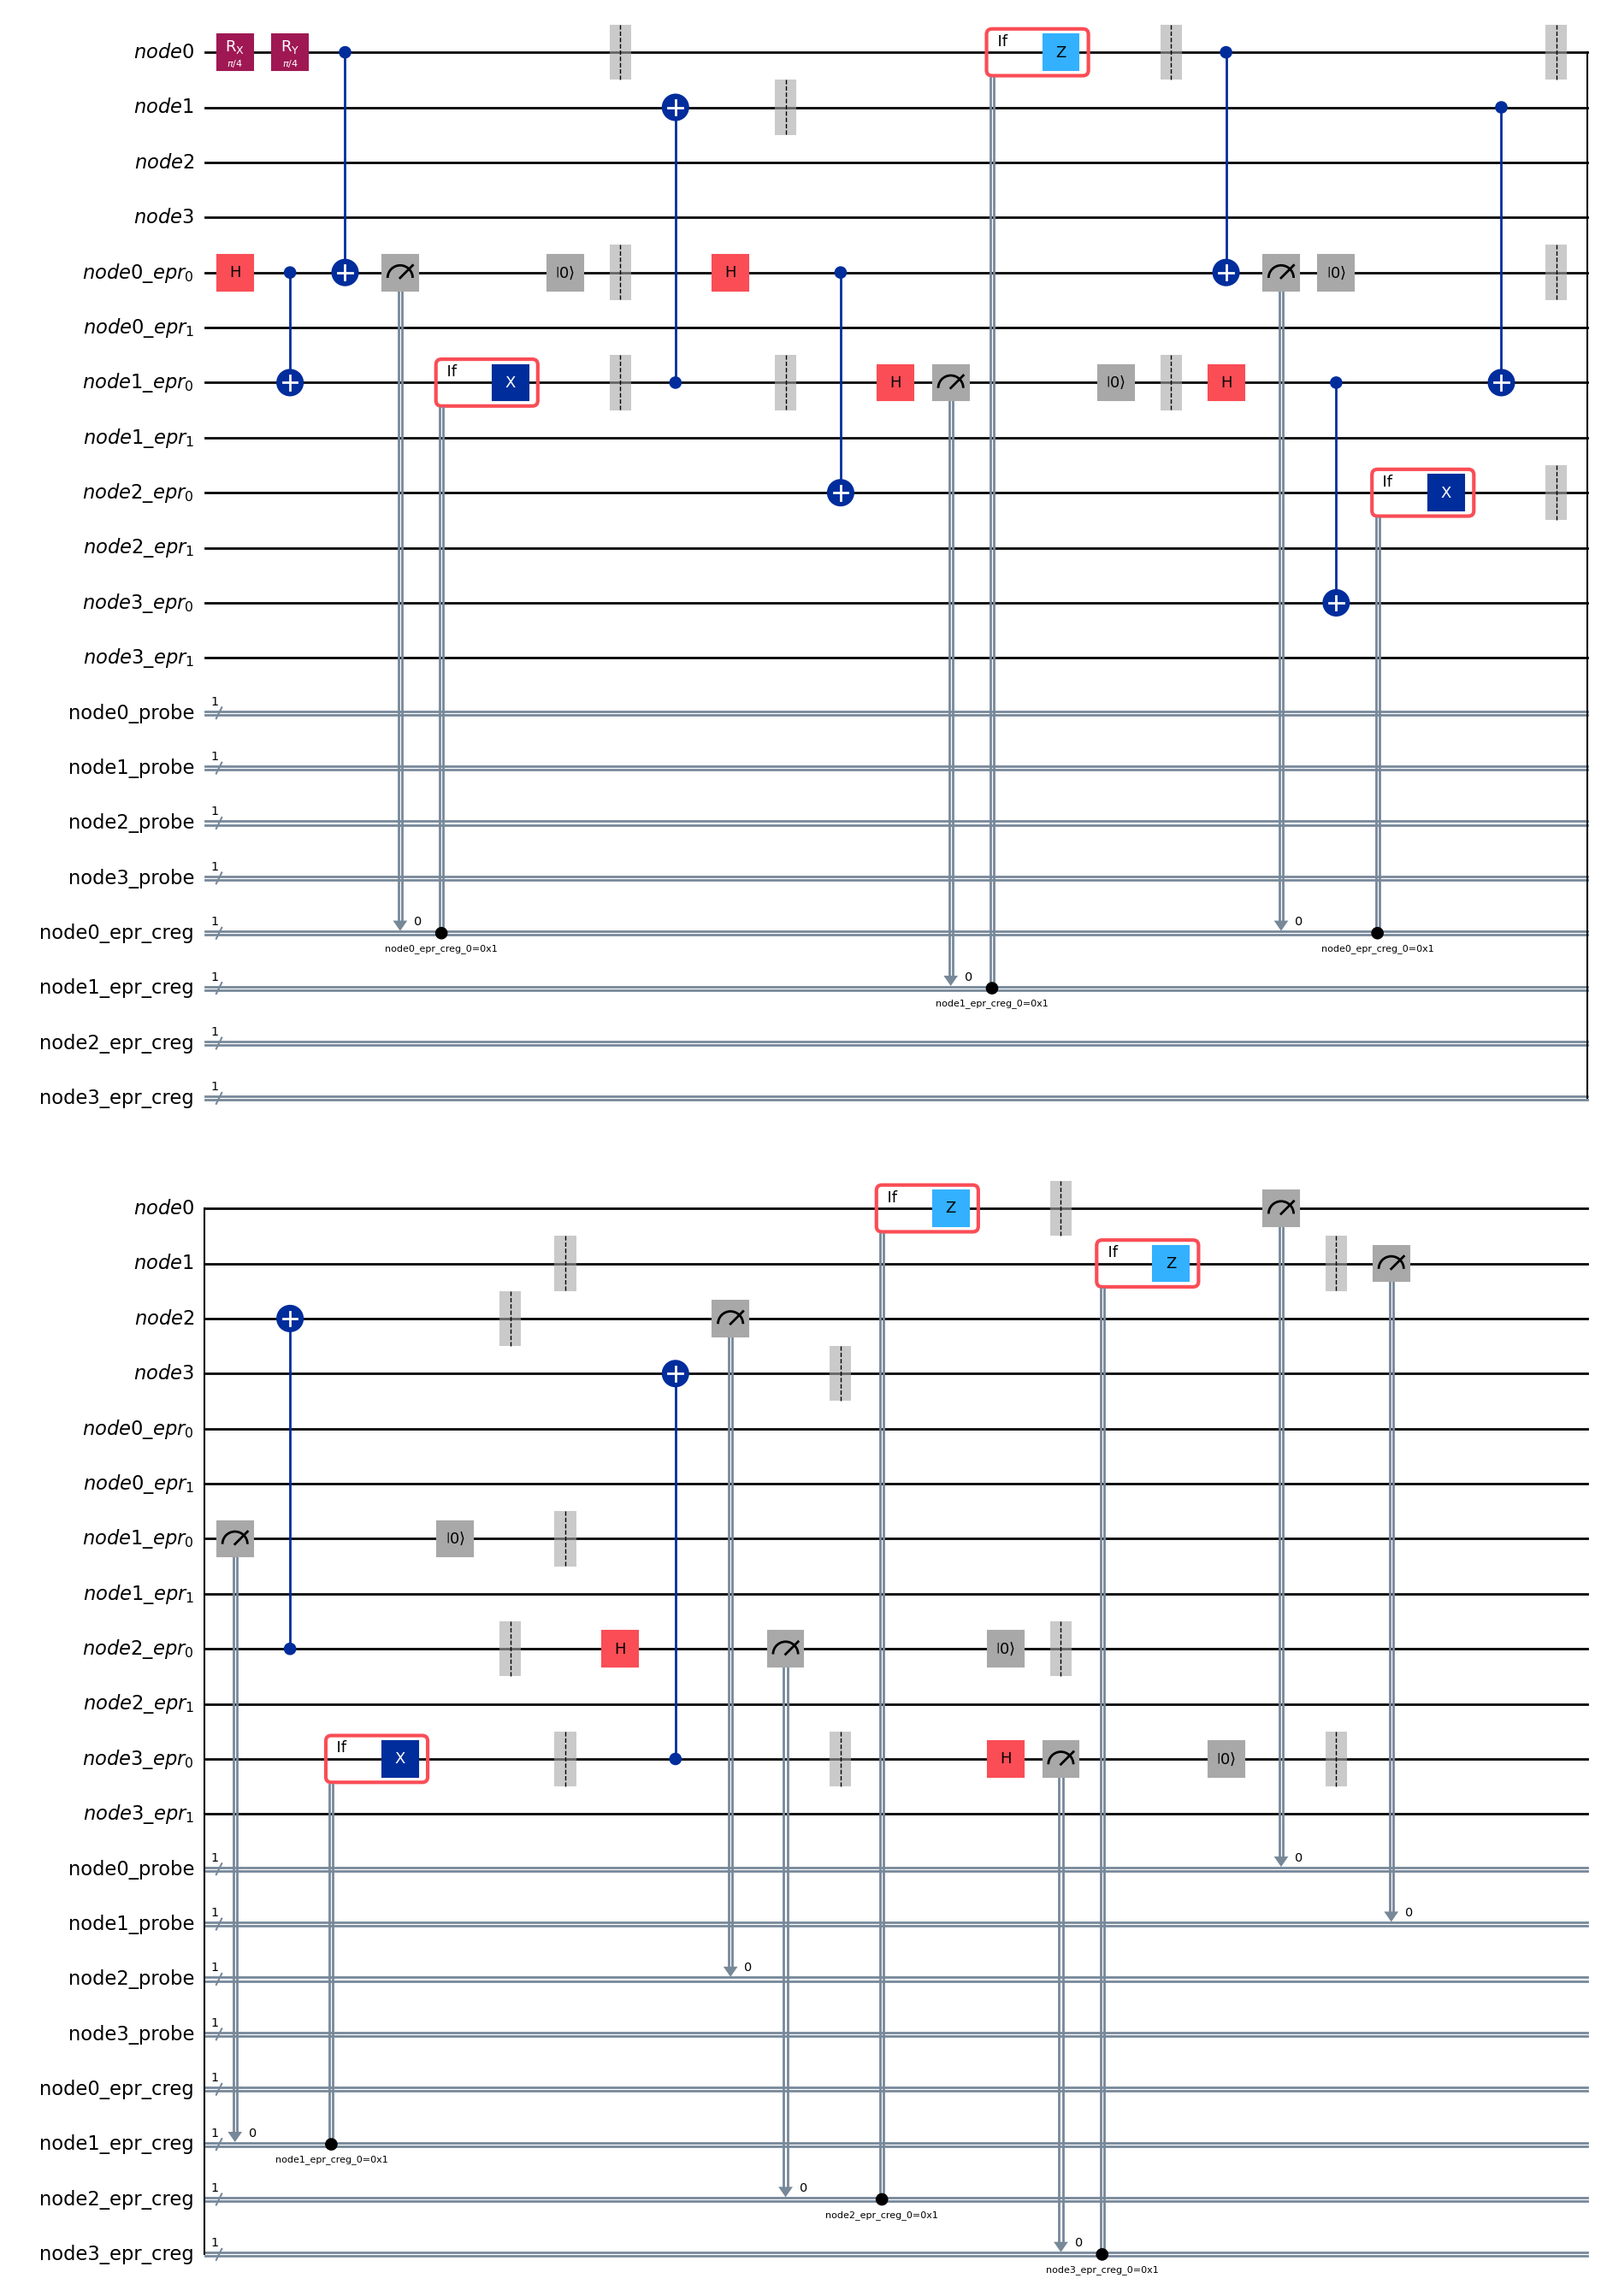

In [77]:
collective_class.q.draw('mpl')

In [91]:
# Function พวกนี้ เราเขียนมาเพื่อให้ใช้งานง่ายขึ้นเฉยๆนะ

def qdata_to_circuit(qc, qdata):
    # for inst, qargs, cargs in qdata:
    #     qc.append(inst, qargs, cargs)
    for instr in qdata:
        qc.append(instr.operation, instr.qubits, instr.clbits)

def beautiful_print_result(qc, counts):
    creg_sequence = []
    for creg in qc.cregs:
        creg_sequence.append(f"{creg.name}[{creg.size}]")
    creg_sequence.reverse()
    print("Classical registers (left→right):", " → ".join(creg_sequence))

    print("\nCounts:")
    for bits, count in counts.items():
        print(f"{bits} : {count}")

def prob_single_cbit(counts, target_index):
    # index ของ cbit ตรงกลาง (จากซ้ายไปขวา)
    total = sum(counts.values())

    p0 = sum(v for k, v in counts.items() if k.split()[target_index] == '0') / total
    p1 = sum(v for k, v in counts.items() if k.split()[target_index] == '1') / total

    print(f"P(cbit[{target_index}] = 0) = {p0:.4f}")
    print(f"P(cbit[{target_index}] = 1) = {p1:.4f}")

def mbu(qq, contain_qbit, uncompute_qbit, creg):
    qq.q.h(uncompute_qbit)
    qq.recieveEPR(qq.q, uncompute_qbit, creg)
    qq.q.barrier(contain_qbit, uncompute_qbit) 
    with qq.q.if_test((creg,1)):
        qq.q.z(contain_qbit)
    qq.q.barrier(contain_qbit, uncompute_qbit)
    return qq

def my_qtp(qq, src, eprsrc, dsc, srccreg):
    qq.q.cx(src, eprsrc)
    qq.recieveEPR(qq.q, eprsrc, srccreg)
    qq.q.h(src)
    qq.q.reset(eprsrc)
    with qq.q.if_test((srccreg,1)):
        qq.q.x(dsc)
    qq.recieveEPR(qq.q, src, srccreg)

    # This barrier is very important
    # Because it can help to do phase correction
    qq.q.barrier(src, eprsrc, dsc) 

    with qq.q.if_test((srccreg,1)):
        qq.q.z(dsc)
    qq.q.barrier(src, eprsrc, dsc)
    return qq

def my_qtp2(qq, src, eprsrc, dsc, srccreg):
    qq.cx(src, eprsrc)
    qq.measure(eprsrc, srccreg)
    qq.h(src)
    qq.reset(eprsrc)
    with qq.if_test((srccreg,1)):
        qq.x(dsc)
    qq.measure(src, srccreg)

    # This barrier is very important
    # Because it can help to do phase correction
    qq.barrier(src, eprsrc, dsc) 

    with qq.if_test((srccreg,1)):
        qq.z(dsc)
    qq.barrier(src, eprsrc, dsc)
    return qq

def weird_function1(qq, eprsrc, dsc, srccreg):
    qq.measure(eprsrc, srccreg)
    qq.reset(eprsrc)
    with qq.if_test((srccreg,1)):
        qq.x(dsc)
    qq.barrier(eprsrc, eprsrc, dsc)
    return qq

def my_copy(qq, src, eprsrc, dsc, srccreg):
    qq.h(eprsrc)
    qq.cx(eprsrc, dsc)
    qq.cx(src, eprsrc)
    qq.measure(eprsrc, srccreg)
    #qq.x(self.EPRdestbit).c_if(self.Csrcbit,1)
    with qq.if_test((srccreg,1)):
        qq.x(dsc)
    qq.barrier()
    return qq

In [92]:
# Original

collective_circuit_tinthai = QuantumCircuit()
node0 = QuantumRegister(1, name = "node0")
node1 = QuantumRegister(1, name = "node1")
node2 = QuantumRegister(1, name = "node2")
node3 = QuantumRegister(1, name = "node3")
#node4 = QuantumRegister(1, name = "node4")
node0_epr = QuantumRegister(2, name = "node0_epr")
node1_epr = QuantumRegister(2, name = "node1_epr")
node2_epr = QuantumRegister(2, name = "node2_epr")
node3_epr = QuantumRegister(2, name = "node3_epr")
#node4_epr = QuantumRegister(2, name = "node4_epr")
node0_epr_creg = ClassicalRegister(1, name = "node0_epr_creg")
node1_epr_creg = ClassicalRegister(1, name = "node1_epr_creg")
node2_epr_creg = ClassicalRegister(1, name = "node2_epr_creg")
node3_epr_creg = ClassicalRegister(1, name = "node3_epr_creg")
#node4_epr_creg = ClassicalRegister(1, name = "node4_epr_creg")

bcast_buffer = QuantumRegister(1, name = "bcast_buffer")
bcast_buffer_epr = QuantumRegister(2, name = "bcast_buffer_epr")
bcast_buffer_epr_creg = ClassicalRegister(1, name = "bcast_buffer_epr_creg")
bcast_device = QuantumRegister(3, name = "bcast_device")
bcast_device_epr = QuantumRegister(3, name = "bcast_device_epr")
bcast_device_epr_creg = ClassicalRegister(3, name = "bcast_device_epr_creg")

uncompute_creg = ClassicalRegister(1, name = "uncompute_creg")

# collective_circuit_tinthai.add_register(node0, node0_epr, bcast_buffer, bcast_buffer_epr, bcast_device, bcast_device_epr, node1, node1_epr, node2, node2_epr, node3, node3_epr)
# collective_circuit_tinthai.add_register(node0_epr_creg, bcast_buffer_epr_creg, bcast_device_epr_creg, node1_epr_creg, node2_epr_creg, node3_epr_creg, uncompute_creg)
collective_circuit_tinthai.add_register(node0, node1, node2, node3, node0_epr, node1_epr, node2_epr, node3_epr, bcast_buffer, bcast_buffer_epr, bcast_device, bcast_device_epr)
collective_circuit_tinthai.add_register(node0_epr_creg, node1_epr_creg, node2_epr_creg, node3_epr_creg, bcast_buffer_epr_creg, bcast_device_epr_creg, uncompute_creg)
#collective_circuit_tinthai.add_register(node0, node1, node2, node0_epr, node1_epr, node2_epr, bcast_buffer, bcast_buffer_epr, bcast_device, bcast_device_epr)
#collective_circuit_tinthai.add_register(node0_epr_creg, node1_epr_creg, node2_epr_creg, bcast_buffer_epr_creg, bcast_device_epr_creg, uncompute_creg)

# Initiate ให้ node1[0] มีโอกาส ket(0) ~75%
collective_circuit_tinthai.rx(math.pi/4, node0[0])   # หมุนแกน X มุม π/4 บน qubit 0
collective_circuit_tinthai.ry(math.pi/4, node0[0])   # หมุนแกน Y มุม π/4 บน qubit 0

# ลองใช้ QMPI ของ Tom Nguyen ดู
collective_circuit_tinthai = MPI.EPRsetup(collective_circuit_tinthai, node0[0], bcast_buffer[0])

# EPR Pair Preparation
collective_circuit_tinthai.q.h(bcast_device_epr[0])
collective_circuit_tinthai.q.h(bcast_device_epr[1])
collective_circuit_tinthai.q.h(bcast_device_epr[2])
collective_circuit_tinthai.q.cx(bcast_device_epr[0], node1[0])
collective_circuit_tinthai.q.cx(bcast_device_epr[1], node2[0])
collective_circuit_tinthai.q.cx(bcast_device_epr[2], node3[0])
collective_circuit_tinthai.q.barrier()

# Copy to buffer
operation = collective_circuit_tinthai.copy()
qdata_to_circuit(collective_circuit_tinthai.q, operation)
collective_circuit_tinthai.q.cx(bcast_buffer_epr[0], bcast_buffer[0])

# Device setup
collective_circuit_tinthai.q.barrier()
collective_circuit_tinthai.q.cx(bcast_buffer[0], bcast_device[0])
collective_circuit_tinthai.q.cx(bcast_device[0], bcast_device[1])
collective_circuit_tinthai.q.cx(bcast_device[1], bcast_device[2])

# Bcast
collective_circuit_tinthai.q.barrier()
collective_circuit_tinthai = my_qtp(collective_circuit_tinthai, bcast_device[0], bcast_device_epr[0], node1[0], bcast_device_epr_creg[0])
collective_circuit_tinthai = my_qtp(collective_circuit_tinthai, bcast_device[1], bcast_device_epr[1], node2[0], bcast_device_epr_creg[1])
collective_circuit_tinthai = my_qtp(collective_circuit_tinthai, bcast_device[2], bcast_device_epr[2], node3[0], bcast_device_epr_creg[2])

# # UnBroadcast
# collective_circuit_tinthai.q.barrier()
# collective_circuit_tinthai.q.barrier()
# collective_circuit_tinthai.q.reset(node3_epr[0])
# collective_circuit_tinthai.q.reset(node0[0])
# collective_circuit_tinthai.q.reset(bcast_buffer[0])
# collective_circuit_tinthai.q.barrier()
# collective_circuit_tinthai = mbu(collective_circuit_tinthai, node3[0], node1[0], uncompute_creg[0])
# collective_circuit_tinthai = mbu(collective_circuit_tinthai, node3[0], node2[0], uncompute_creg[0])
# #Prepare epr
# collective_circuit_tinthai.q.h(bcast_buffer[0])
# collective_circuit_tinthai.q.cx(node3[0], bcast_buffer[0])
# collective_circuit_tinthai = my_qtp(collective_circuit_tinthai, node3[0], node3_epr[0], bcast_buffer[0], node3_epr_creg[0])
# collective_circuit_tinthai.q.barrier()
# operation = collective_circuit_tinthai.unsend()
# qdata_to_circuit(collective_circuit_tinthai.q, operation)

# การวัดด้วยตัวเอง
collective_circuit_tinthai.q.barrier()

# ทดสอบว่ามี node 0 entanglement กับอะไร ไหม
# collective_circuit_tinthai.q.reset(node1[0])
# collective_circuit_tinthai.q.reset(node2[0])
# collective_circuit_tinthai.q.reset(node3[0])

collective_circuit_tinthai.recieveEPR(collective_circuit_tinthai.q, node0[0], node0_epr_creg[0])
collective_circuit_tinthai.recieveEPR(collective_circuit_tinthai.q, node1[0], node1_epr_creg[0])
collective_circuit_tinthai.recieveEPR(collective_circuit_tinthai.q, node2[0], node2_epr_creg[0])
collective_circuit_tinthai.recieveEPR(collective_circuit_tinthai.q, node3[0], node3_epr_creg[0])

collective_circuit_tinthai = collective_circuit_tinthai.q

In [ ]:
# #Switch type

# collective_circuit_tinthai = QuantumCircuit()
# node0 = QuantumRegister(1, name = "node0")
# node1 = QuantumRegister(1, name = "node1")
# node2 = QuantumRegister(1, name = "node2")
# node3 = QuantumRegister(1, name = "node3")
# node0_epr = QuantumRegister(1, name = "node0_epr")
# node1_epr = QuantumRegister(1, name = "node1_epr")
# node2_epr = QuantumRegister(1, name = "node2_epr")
# node3_epr = QuantumRegister(1, name = "node3_epr")
# node0_epr_creg = ClassicalRegister(1, name = "node0_epr_creg")
# node1_epr_creg = ClassicalRegister(1, name = "node1_epr_creg")
# node2_epr_creg = ClassicalRegister(1, name = "node2_epr_creg")
# node3_epr_creg = ClassicalRegister(1, name = "node3_epr_creg")

# bcast_buffer = QuantumRegister(1, name = "bcast_buffer")
# bcast_buffer_epr = QuantumRegister(3, name = "bcast_buffer_epr")
# bcast_buffer_epr_creg = ClassicalRegister(1, name = "bcast_buffer_epr_creg")
# bcast_device_epr = QuantumRegister(3, name = "bcast_device_epr")
# bcast_device_epr_creg = ClassicalRegister(3, name = "bcast_device_epr_creg")
# uncompute_creg = ClassicalRegister(1, name = "uncompute_creg")

# collective_circuit_tinthai.add_register(node0, node1, node2, node3, node0_epr, node1_epr, node2_epr, node3_epr, bcast_buffer, bcast_buffer_epr, bcast_device_epr)
# collective_circuit_tinthai.add_register(node0_epr_creg, node1_epr_creg, node2_epr_creg, node3_epr_creg, bcast_buffer_epr_creg, bcast_device_epr_creg, uncompute_creg)

# # Initiate ให้ node1[0] มีโอกาส ket(0) ~75%
# collective_circuit_tinthai.rx(math.pi/4, node0[0])   # หมุนแกน X มุม π/4 บน qubit 0
# collective_circuit_tinthai.ry(math.pi/4, node0[0])   # หมุนแกน Y มุม π/4 บน qubit 0

# # EPR Pair Preparation
# collective_circuit_tinthai.h(bcast_device_epr[0])
# collective_circuit_tinthai.h(bcast_device_epr[1])
# collective_circuit_tinthai.h(bcast_device_epr[2])
# collective_circuit_tinthai.cx(bcast_device_epr[0], node1[0])
# collective_circuit_tinthai.cx(bcast_device_epr[1], node2[0])
# collective_circuit_tinthai.cx(bcast_device_epr[2], node3[0])
# collective_circuit_tinthai.barrier()

# # Copy to buffer_epr
# collective_circuit_tinthai = my_copy(collective_circuit_tinthai, node0[0], node0_epr[0], bcast_buffer[0], node0_epr_creg[0])

# # Device setup
# collective_circuit_tinthai.cx(bcast_buffer[0], bcast_buffer_epr[0])
# collective_circuit_tinthai.cx(bcast_buffer_epr[0], bcast_buffer_epr[1])
# collective_circuit_tinthai.cx(bcast_buffer_epr[1], bcast_buffer_epr[2])

# # Bell analyzer
# collective_circuit_tinthai.cx(bcast_buffer_epr[0], bcast_device_epr[0])
# collective_circuit_tinthai.cx(bcast_buffer_epr[1], bcast_device_epr[1])
# collective_circuit_tinthai.cx(bcast_buffer_epr[2], bcast_device_epr[2])
# collective_circuit_tinthai.h(bcast_buffer_epr[0])
# collective_circuit_tinthai.h(bcast_buffer_epr[1])
# collective_circuit_tinthai.h(bcast_buffer_epr[2])

# # Bcast
# collective_circuit_tinthai.barrier()
# collective_circuit_tinthai = weird_function1(collective_circuit_tinthai, bcast_device_epr[0], node1_epr[0], bcast_device_epr_creg[0])
# collective_circuit_tinthai = weird_function1(collective_circuit_tinthai, bcast_device_epr[1], node2_epr[0], bcast_device_epr_creg[1])
# collective_circuit_tinthai = weird_function1(collective_circuit_tinthai, bcast_device_epr[2], node3_epr[0], bcast_device_epr_creg[2])

# collective_circuit_tinthai.cx(node1_epr[0], node1[0])
# collective_circuit_tinthai.cx(node2_epr[0], node2[0])
# collective_circuit_tinthai.cx(node3_epr[0], node3[0])

# # การวัดด้วยตัวเอง
# collective_circuit_tinthai.h(bcast_buffer[0])
# collective_circuit_tinthai.reset(bcast_buffer[0])
# collective_circuit_tinthai.reset(bcast_buffer_epr[0])
# collective_circuit_tinthai.reset(bcast_buffer_epr[1])
# collective_circuit_tinthai.reset(bcast_buffer_epr[2])
# collective_circuit_tinthai.barrier()
# collective_circuit_tinthai.measure(node0[0], node0_epr_creg[0])
# collective_circuit_tinthai.measure(node1[0], node1_epr_creg[0])
# collective_circuit_tinthai.measure(node2[0], node2_epr_creg[0])
# collective_circuit_tinthai.measure(node3[0], node3_epr_creg[0])

In [80]:
# #Switch type + GHZ

# collective_circuit_tinthai = QuantumCircuit()
# node0 = QuantumRegister(1, name = "node0")
# node1 = QuantumRegister(1, name = "node1")
# node2 = QuantumRegister(1, name = "node2")
# node3 = QuantumRegister(1, name = "node3")
# node0_epr = QuantumRegister(1, name = "node0_epr")
# node1_epr = QuantumRegister(1, name = "node1_epr")
# node2_epr = QuantumRegister(1, name = "node2_epr")
# node3_epr = QuantumRegister(1, name = "node3_epr")
# node0_epr_creg = ClassicalRegister(1, name = "node0_epr_creg")
# node1_epr_creg = ClassicalRegister(1, name = "node1_epr_creg")
# node2_epr_creg = ClassicalRegister(1, name = "node2_epr_creg")
# node3_epr_creg = ClassicalRegister(1, name = "node3_epr_creg")

# bcast_buffer_epr = QuantumRegister(1, name = "bcast_buffer_epr")
# bcast_buffer_epr_creg = ClassicalRegister(1, name = "bcast_buffer_epr_creg")
# bcast_device_epr = QuantumRegister(3, name = "bcast_device_epr")
# bcast_device_epr_creg = ClassicalRegister(3, name = "bcast_device_epr_creg")
# uncompute_creg = ClassicalRegister(1, name = "uncompute_creg")

# collective_circuit_tinthai.add_register(node0, node1, node2, node3, node0_epr, node1_epr, node2_epr, node3_epr, bcast_buffer_epr, bcast_device_epr)
# collective_circuit_tinthai.add_register(node0_epr_creg, node1_epr_creg, node2_epr_creg, node3_epr_creg, bcast_buffer_epr_creg, bcast_device_epr_creg, uncompute_creg)

# # Initiate ให้ node1[0] มีโอกาส ket(0) ~75%
# collective_circuit_tinthai.rx(math.pi/4, node0[0])   # หมุนแกน X มุม π/4 บน qubit 0
# collective_circuit_tinthai.ry(math.pi/4, node0[0])   # หมุนแกน Y มุม π/4 บน qubit 0

# # EPR Pair Preparation
# collective_circuit_tinthai.h(bcast_device_epr[0])
# collective_circuit_tinthai.h(bcast_device_epr[1])
# collective_circuit_tinthai.h(bcast_device_epr[2])
# collective_circuit_tinthai.cx(bcast_device_epr[0], node1[0])
# collective_circuit_tinthai.cx(bcast_device_epr[1], node2[0])
# collective_circuit_tinthai.cx(bcast_device_epr[2], node3[0])
# collective_circuit_tinthai.barrier()

# # Copy to buffer_epr
# collective_circuit_tinthai = my_copy(collective_circuit_tinthai, node0[0], node0_epr[0], bcast_buffer_epr[0], node0_epr_creg[0])

# # Device setup
# collective_circuit_tinthai.barrier()
# collective_circuit_tinthai.cx(bcast_buffer_epr[0], bcast_device_epr[0])
# collective_circuit_tinthai.cx(bcast_buffer_epr[0], bcast_device_epr[1])
# collective_circuit_tinthai.cx(bcast_buffer_epr[0], bcast_device_epr[2])
# collective_circuit_tinthai.h(bcast_buffer_epr[0])
# collective_circuit_tinthai.reset(bcast_buffer_epr[0])

# # Bcast
# collective_circuit_tinthai.barrier()
# collective_circuit_tinthai = weird_function1(collective_circuit_tinthai, bcast_device_epr[0], node1_epr[0], bcast_device_epr_creg[0])
# collective_circuit_tinthai = weird_function1(collective_circuit_tinthai, bcast_device_epr[1], node2_epr[0], bcast_device_epr_creg[1])
# collective_circuit_tinthai = weird_function1(collective_circuit_tinthai, bcast_device_epr[2], node3_epr[0], bcast_device_epr_creg[2])

# collective_circuit_tinthai.cx(node1_epr[0], node1[0])
# collective_circuit_tinthai.cx(node2_epr[0], node2[0])
# collective_circuit_tinthai.cx(node3_epr[0], node3[0])

# # การวัดด้วยตัวเอง
# collective_circuit_tinthai.barrier()
# collective_circuit_tinthai.measure(node0[0], node0_epr_creg[0])
# collective_circuit_tinthai.measure(node1[0], node1_epr_creg[0])
# collective_circuit_tinthai.measure(node2[0], node2_epr_creg[0])
# collective_circuit_tinthai.measure(node3[0], node3_epr_creg[0])

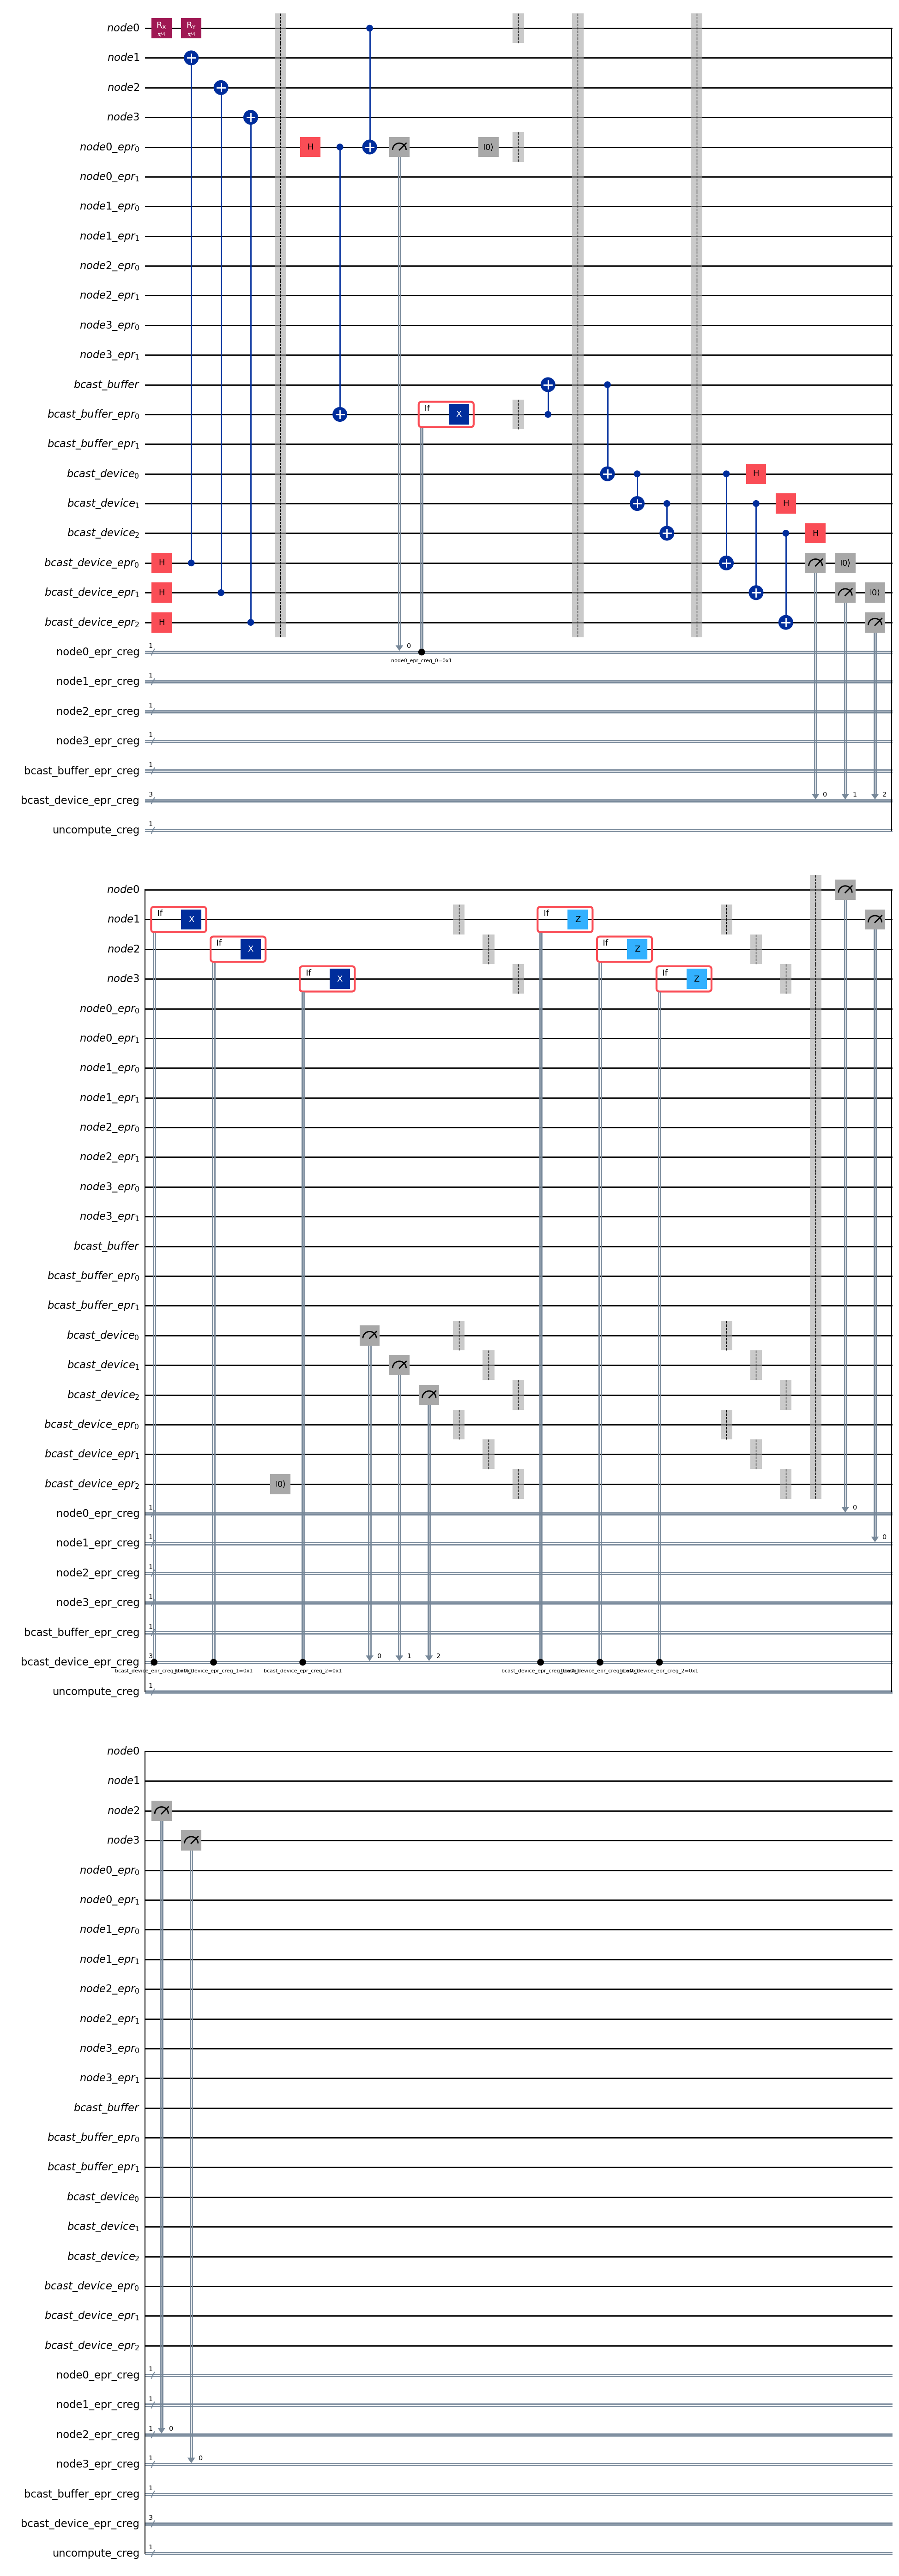

In [93]:
collective_circuit_tinthai.draw('mpl')

In [94]:
sim = AerSimulator()
collective_circuit_tinthai_ready2rn = transpile(collective_circuit_tinthai, backend=sim, optimization_level=3)
result = sim.run(collective_circuit_tinthai_ready2rn).result()
counts = result.get_counts()
# beautiful_print_result(collective_circuit_tinthai, counts)
# print(counts)
## ถ้าใส่ add_register(c0,c1,c2) ผลลัพธ์จะเป็น 'c2, c1, c0'

print("Node 0 Prob:")
prob_single_cbit(counts, target_index=6)
print("")

print("Node 1 Prob:")
prob_single_cbit(counts, target_index=5)
print("")

print("Node 2 Prob:")
prob_single_cbit(counts, target_index=4)
print("")

print("Node 3 Prob:")
prob_single_cbit(counts, target_index=3)
print("")

Node 0 Prob:
P(cbit[6] = 0) = 0.7764
P(cbit[6] = 1) = 0.2236

Node 1 Prob:
P(cbit[5] = 0) = 0.7764
P(cbit[5] = 1) = 0.2236

Node 2 Prob:
P(cbit[4] = 0) = 0.7764
P(cbit[4] = 1) = 0.2236

Node 3 Prob:
P(cbit[3] = 0) = 0.7764
P(cbit[3] = 1) = 0.2236



In [ ]:
from qiskit_aer import AerSimulator
from qiskit import transpile

# 1️⃣ ลบการวัดออก (เพื่อดูสถานะก่อน collapse)
circ_no_measure = collective_circuit_tinthai.remove_final_measurements(inplace=False)

# 2️⃣ บอกให้ simulator เก็บ statevector
circ_no_measure.save_statevector() 

# 3️⃣ ใช้ simulator แบบ statevector
sim_sv = AerSimulator(method='statevector')

# 4️⃣ transpile และรัน
ready_sv = transpile(circ_no_measure, sim_sv)
result_sv = sim_sv.run(ready_sv).result()

# 5️⃣ ดึงข้อมูล statevector ออกมา
statevector = result_sv.data(0)['statevector']
# print(statevector)
from qiskit.quantum_info import Statevector
import numpy as np

# statevector จากผล simulation
vec = Statevector(statevector)

# แสดงเฉพาะค่าสำคัญ
for i, amp in enumerate(vec.data):
    if not np.isclose(abs(amp), 0):  # ข้ามค่าที่แทบเป็นศูนย์
        print(f"|{i:0{vec.num_qubits}b}> : {amp}")

|000000000100000> : (0.8535533905932736+0.14644660940672627j)
|000000000101111> : (0.3535533905932737-0.35355339059327406j)


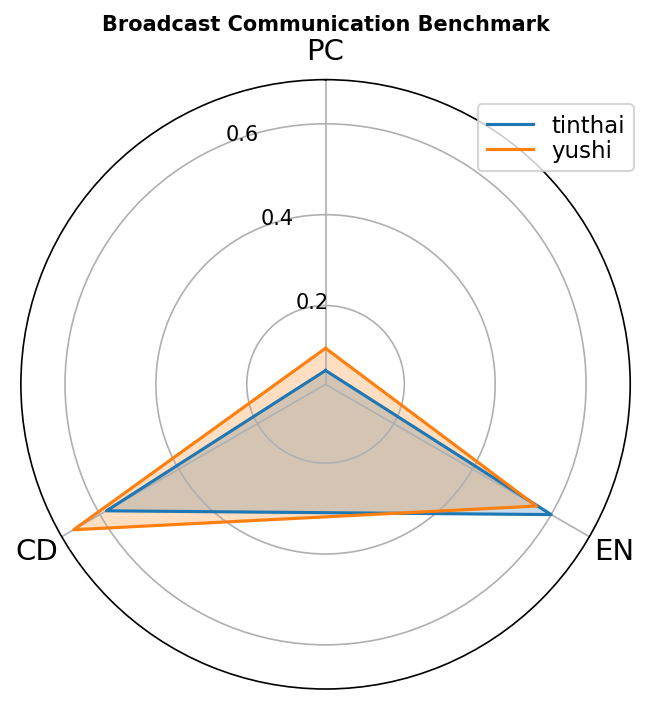

In [95]:
from supermarq import *

bcast_tinthai = [
  converters.compute_communication_with_qiskit(transpile(collective_circuit_tinthai, backend=AerSimulator(), optimization_level=3)),
  converters.compute_depth_with_qiskit(transpile(collective_circuit_tinthai, backend=AerSimulator(), optimization_level=3)),
  converters.compute_entanglement_with_qiskit(transpile(collective_circuit_tinthai, backend=AerSimulator(), optimization_level=3)),
]

bcast_yushi = [
  converters.compute_communication_with_qiskit(transpile(collective_class.q, backend=AerSimulator(), optimization_level=3)),
  converters.compute_depth_with_qiskit(transpile(collective_class.q, backend=AerSimulator(), optimization_level=3)),
  converters.compute_entanglement_with_qiskit(transpile(collective_class.q, backend=AerSimulator(), optimization_level=3)),
]

spoke_labels = ["PC", "CD", "EN"]
plotting.plot_benchmark(
    title= "Broadcast Communication Benchmark",
    labels=["tinthai", "yushi"],             # one label
    features=[bcast_tinthai, bcast_yushi],        # must be a list of feature lists
    spoke_labels=spoke_labels,
    show=True
)

In [ ]:
# import pandas as pd
# import seaborn as sns
# from collections import defaultdict

# # จำนวนครั้งที่ต้องการทดลอง
# NUM_TRIALS = 10

# # เก็บผลลัพธ์ทั้งหมดจากทุก trial (เก็บเป็น list ของค่าสำหรับแต่ละ backend+metric)
# all_results = defaultdict(lambda: defaultdict(list))

# print(f"Starting benchmark comparison with {NUM_TRIALS} trials across all backends...")
# print("=" * 80)

# backend_use = [FakeAuckland(), FakeBrisbane(), FakeCusco(), FakeKawasaki(), FakeKyiv(), FakeKyoto(), 
#                FakeQuebec(), FakeSherbrooke(), FakeTorino(), FakeAlgiers(), FakeHanoiV2(), 
#                FakePeekskill(), FakeLagosV2(), FakeNairobiV2()]

# for trial in range(NUM_TRIALS):
#     if (trial + 1) % 100 == 0:
#         print(f"Progress: {trial + 1}/{NUM_TRIALS} trials completed...")
    
#     for backend in backend_use:
#         backend_name = backend.name
        
#         try:
#             # Transpile circuits for both tinthai and yushi
#             tinthai_transpiled = transpile(collective_circuit_tinthai, backend=backend, optimization_level=3)
#             yushi_transpiled = transpile(collective_class.q, backend=backend, optimization_level=3)
            
#             # Calculate metrics for tinthai
#             tinthai_comm = converters.compute_communication_with_qiskit(tinthai_transpiled)
#             tinthai_depth = converters.compute_depth_with_qiskit(tinthai_transpiled)
#             tinthai_entang = converters.compute_entanglement_with_qiskit(tinthai_transpiled)
            
#             # Calculate metrics for yushi
#             yushi_comm = converters.compute_communication_with_qiskit(yushi_transpiled)
#             yushi_depth = converters.compute_depth_with_qiskit(yushi_transpiled)
#             yushi_entang = converters.compute_entanglement_with_qiskit(yushi_transpiled)
            
#             # Calculate differences (tinthai - yushi)
#             diff_comm = tinthai_comm - yushi_comm
#             diff_depth = tinthai_depth - yushi_depth
#             diff_entang = tinthai_entang - yushi_entang
            
#             # เก็บผลลัพธ์ของแต่ละ trial
#             all_results[backend_name]['PC'].append(diff_comm)
#             all_results[backend_name]['CD'].append(diff_depth)
#             all_results[backend_name]['EN'].append(diff_entang)
            
#         except Exception as e:
#             # หาก error ให้เก็บ NaN
#             all_results[backend_name]['PC'].append(np.nan)
#             all_results[backend_name]['CD'].append(np.nan)
#             all_results[backend_name]['EN'].append(np.nan)

# print("\n" + "=" * 80)
# print("All trials completed! Computing average results...")
# print("\n")

# # คำนวณค่าเฉลี่ยสำหรับแต่ละ backend และ metric
# comparison_results = []
# for backend_name in all_results.keys():
#     avg_comm = np.nanmean(all_results[backend_name]['PC'])  # nanmean จะข้าม NaN
#     avg_depth = np.nanmean(all_results[backend_name]['CD'])
#     avg_entang = np.nanmean(all_results[backend_name]['EN'])
    
#     # คำนวณ standard deviation เพื่อดูความแปรปรวน
#     std_comm = np.nanstd(all_results[backend_name]['PC'])
#     std_depth = np.nanstd(all_results[backend_name]['CD'])
#     std_entang = np.nanstd(all_results[backend_name]['EN'])
    
#     comparison_results.append({
#         'Backend': backend_name,
#         'PC': avg_comm,
#         'CD': avg_depth,
#         'EN': avg_entang,
#         'PC_std': std_comm,
#         'CD_std': std_depth,
#         'EN_std': std_entang
#     })

# # Create DataFrame for easier manipulation
# df_comparison = pd.DataFrame(comparison_results)
# df_comparison_display = df_comparison[['Backend', 'PC', 'CD', 'EN']].set_index('Backend')
# df_std = df_comparison[['Backend', 'PC_std', 'CD_std', 'EN_std']].set_index('Backend')

# print(f"Average Results over {NUM_TRIALS} trials (Tinthai - Yushi):")
# print("Positive = Tinthai has higher value, Negative = Yushi has higher value")
# print(df_comparison_display)
# print("\n")
# print("Standard Deviation:")
# print(df_std)
# print("\n")

# # Create heatmap
# fig, axes = plt.subplots(1, 2, figsize=(18, len(backend_use) * 0.5))

# # Heatmap สำหรับค่าเฉลี่ย
# sns.heatmap(df_comparison_display, 
#             annot=True,  # Show values
#             fmt='.3f',   # Format to 3 decimal places
#             cmap='RdYlGn_r',  # Red-Yellow-Green reversed
#             center=0,    # Center the colormap at 0
#             cbar_kws={'label': 'Avg Score Difference (Tinthai - Yushi)'},
#             linewidths=0.5,
#             ax=axes[0])

# axes[0].set_title(f'Average Performance Comparison ({NUM_TRIALS} trials)\n(Positive = Tinthai Higher, Negative = Yushi Higher)', 
#              fontsize=14, pad=20)
# axes[0].set_xlabel('Metrics', fontsize=12)
# axes[0].set_ylabel('Backend', fontsize=12)

# # Heatmap สำหรับ standard deviation
# sns.heatmap(df_std, 
#             annot=True,
#             fmt='.3f',
#             cmap='YlOrRd',  # Yellow to Red for std (higher = more variation)
#             cbar_kws={'label': 'Standard Deviation'},
#             linewidths=0.5,
#             ax=axes[1])

# axes[1].set_title(f'Standard Deviation ({NUM_TRIALS} trials)\n(Lower = More Consistent Results)', 
#              fontsize=14, pad=20)
# axes[1].set_xlabel('Metrics', fontsize=12)
# axes[1].set_ylabel('Backend', fontsize=12)

# plt.tight_layout()
# plt.show()

# # Summary statistics
# print("\nSummary Statistics:")
# print(df_comparison_display.describe())
# print("\n")

# # Count wins per approach
# print("Performance Analysis:")
# for metric in ['PC', 'CD', 'EN']:
#     tinthai_better = (df_comparison_display[metric] < 0).sum()
#     yushi_better = (df_comparison_display[metric] > 0).sum()
#     tie = (df_comparison_display[metric] == 0).sum()
    
#     avg_diff = df_comparison_display[metric].mean()
    
#     print(f"\n{metric}:")
#     print(f"  Tinthai performs better: {tinthai_better} backends (lower is better)")
#     print(f"  Yushi performs better: {yushi_better} backends (lower is better)")
#     print(f"  Tie: {tie} backends")
#     print(f"  Average difference: {avg_diff:.4f}")

In [ ]:
# # Visualization สำหรับการกระจายตัวของข้อมูล (Distribution Analysis)

# # 1. เตรียมข้อมูลสำหรับ plotting
# plot_data = []
# for backend_name in all_results.keys():
#     for metric_name in ['PC', 'CD', 'EN']:
#         for value in all_results[backend_name][metric_name]:
#             if not np.isnan(value):  # ข้าม NaN
#                 plot_data.append({
#                     'Backend': backend_name,
#                     'Metric': metric_name,
#                     'Value': value
#                 })

# df_plot = pd.DataFrame(plot_data)

# # 2. Distribution Plots แยกตาม Metric
# fig, axes = plt.subplots(3, 1, figsize=(16, 12))
# metrics = ['PC', 'CD', 'EN']
# metric_names = {
#     'PC': 'Program Communication',
#     'CD': 'Circuit Depth', 
#     'EN': 'Entanglement'
# }

# for idx, metric in enumerate(metrics):
#     ax = axes[idx]
#     metric_data = df_plot[df_plot['Metric'] == metric]
    
#     # สร้าง violin plot (แสดง distribution shape)
#     positions = []
#     data_to_plot = []
#     labels = []
    
#     for i, backend_name in enumerate(sorted(metric_data['Backend'].unique())):
#         backend_values = metric_data[metric_data['Backend'] == backend_name]['Value'].values
#         if len(backend_values) > 0:
#             positions.append(i)
#             data_to_plot.append(backend_values)
#             labels.append(backend_name)
    
#     # Violin plot
#     parts = ax.violinplot(data_to_plot, positions=positions, widths=0.7, 
#                           showmeans=True, showmedians=True)
    
#     # ปรับสี
#     for pc in parts['bodies']:
#         pc.set_facecolor('#8dd3c7')
#         pc.set_alpha(0.7)
    
#     ax.set_xticks(positions)
#     ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=9)
#     ax.set_ylabel('Score Difference\n(Tinthai - Yushi)', fontsize=11)
#     ax.set_title(f'{metric_names[metric]} Distribution across {NUM_TRIALS} trials', 
#                  fontsize=13, fontweight='bold')
#     ax.axhline(y=0, color='red', linestyle='--', alpha=0.5, linewidth=1)
#     ax.grid(axis='y', alpha=0.3)

# plt.tight_layout()
# plt.show()

# # 3. Box Plot สำหรับดู Outliers
# fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# for idx, metric in enumerate(metrics):
#     ax = axes[idx]
#     metric_data = df_plot[df_plot['Metric'] == metric]
    
#     # เตรียมข้อมูลสำหรับ box plot
#     data_by_backend = []
#     backend_labels = []
    
#     for backend_name in sorted(metric_data['Backend'].unique()):
#         backend_values = metric_data[metric_data['Backend'] == backend_name]['Value'].values
#         if len(backend_values) > 0:
#             data_by_backend.append(backend_values)
#             backend_labels.append(backend_name)
    
#     # สร้าง box plot
#     bp = ax.boxplot(data_by_backend, labels=backend_labels, patch_artist=True)
    
#     # ปรับสี
#     for patch in bp['boxes']:
#         patch.set_facecolor('#fb8072')
#         patch.set_alpha(0.6)
    
#     ax.set_xticklabels(backend_labels, rotation=45, ha='right', fontsize=9)
#     ax.set_ylabel('Score Difference (Tinthai - Yushi)', fontsize=11)
#     ax.set_title(f'{metric_names[metric]} - Box Plot', fontsize=13, fontweight='bold')
#     ax.axhline(y=0, color='red', linestyle='--', alpha=0.5, linewidth=1)
#     ax.grid(axis='y', alpha=0.3)

# plt.tight_layout()
# plt.show()

# # 4. Histogram รวมของแต่ละ Metric
# fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# for idx, metric in enumerate(metrics):
#     ax = axes[idx]
#     metric_data = df_plot[df_plot['Metric'] == metric]['Value']
    
#     # สร้าง histogram
#     ax.hist(metric_data, bins=30, alpha=0.7, color='#80b1d3', edgecolor='black')
#     ax.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero (Equal Performance)')
#     ax.axvline(x=metric_data.mean(), color='green', linestyle='-', linewidth=2, 
#                label=f'Mean: {metric_data.mean():.3f}')
#     ax.axvline(x=metric_data.median(), color='orange', linestyle='-', linewidth=2,
#                label=f'Median: {metric_data.median():.3f}')
    
#     ax.set_xlabel('Score Difference (Tinthai - Yushi)', fontsize=11)
#     ax.set_ylabel('Frequency', fontsize=11)
#     ax.set_title(f'{metric_names[metric]} - Overall Distribution', fontsize=13, fontweight='bold')
#     ax.legend(fontsize=9)
#     ax.grid(axis='y', alpha=0.3)

# plt.tight_layout()
# plt.show()

# # 5. Statistical Summary
# print("\n" + "=" * 80)
# print("STATISTICAL SUMMARY OF DISTRIBUTIONS")
# print("=" * 80)

# for metric in metrics:
#     metric_data = df_plot[df_plot['Metric'] == metric]['Value']
    
#     print(f"\n{metric_names[metric]}:")
#     print(f"  Count: {len(metric_data)}")
#     print(f"  Mean: {metric_data.mean():.6f}")
#     print(f"  Median: {metric_data.median():.6f}")
#     print(f"  Std Dev: {metric_data.std():.6f}")
#     print(f"  Min: {metric_data.min():.6f}")
#     print(f"  25th percentile: {metric_data.quantile(0.25):.6f}")
#     print(f"  75th percentile: {metric_data.quantile(0.75):.6f}")
#     print(f"  Max: {metric_data.max():.6f}")
#     print(f"  Skewness: {metric_data.skew():.6f}")
    
#     # นับจำนวนครั้งที่แต่ละแนวทาง (tinthai/yushi) ดีกว่า
#     tinthai_wins = (metric_data < 0).sum()
#     yushi_wins = (metric_data > 0).sum()
#     ties = (metric_data == 0).sum()
    
#     print(f"\n  Performance breakdown (across all trials & backends):")
#     print(f"    Tinthai better: {tinthai_wins} times ({tinthai_wins/len(metric_data)*100:.2f}%)")
#     print(f"    Yushi better: {yushi_wins} times ({yushi_wins/len(metric_data)*100:.2f}%)")
#     print(f"    Tie: {ties} times ({ties/len(metric_data)*100:.2f}%)")

# print("\n" + "=" * 80)

My code with supermarq

Starting benchmark comparison with 1024 trials across all backends...
Running in PARALLEL mode using -1 threads.


Benchmarking:   0%|          | 0/13312 [00:00<?, ?it/s]


Processing completed!
Captured 13312 valid trials.

Average Difference (Tinthai - Yushi):
                       PC        CD        EN
Backend                                      
aer_simulator   -0.048918 -0.083333  0.037500
fake_auckland    0.014804 -0.105821  0.089401
fake_brisbane    0.000770 -0.123344  0.013837
fake_cusco       0.000770 -0.113442  0.008815
fake_kawasaki    0.000770 -0.126796  0.014610
fake_kyiv        0.000770 -0.127593  0.010355
fake_kyoto       0.000770 -0.113257  0.012317
fake_quebec      0.000770 -0.117342  0.012902
fake_sherbrooke  0.000770 -0.127107  0.014142
fake_torino      0.000738 -0.112599  0.030012
fake_algiers     0.014804 -0.102007  0.089401
fake_hanoi       0.014804 -0.101966  0.089401
fake_peekskill   0.014804 -0.125956 -0.005941


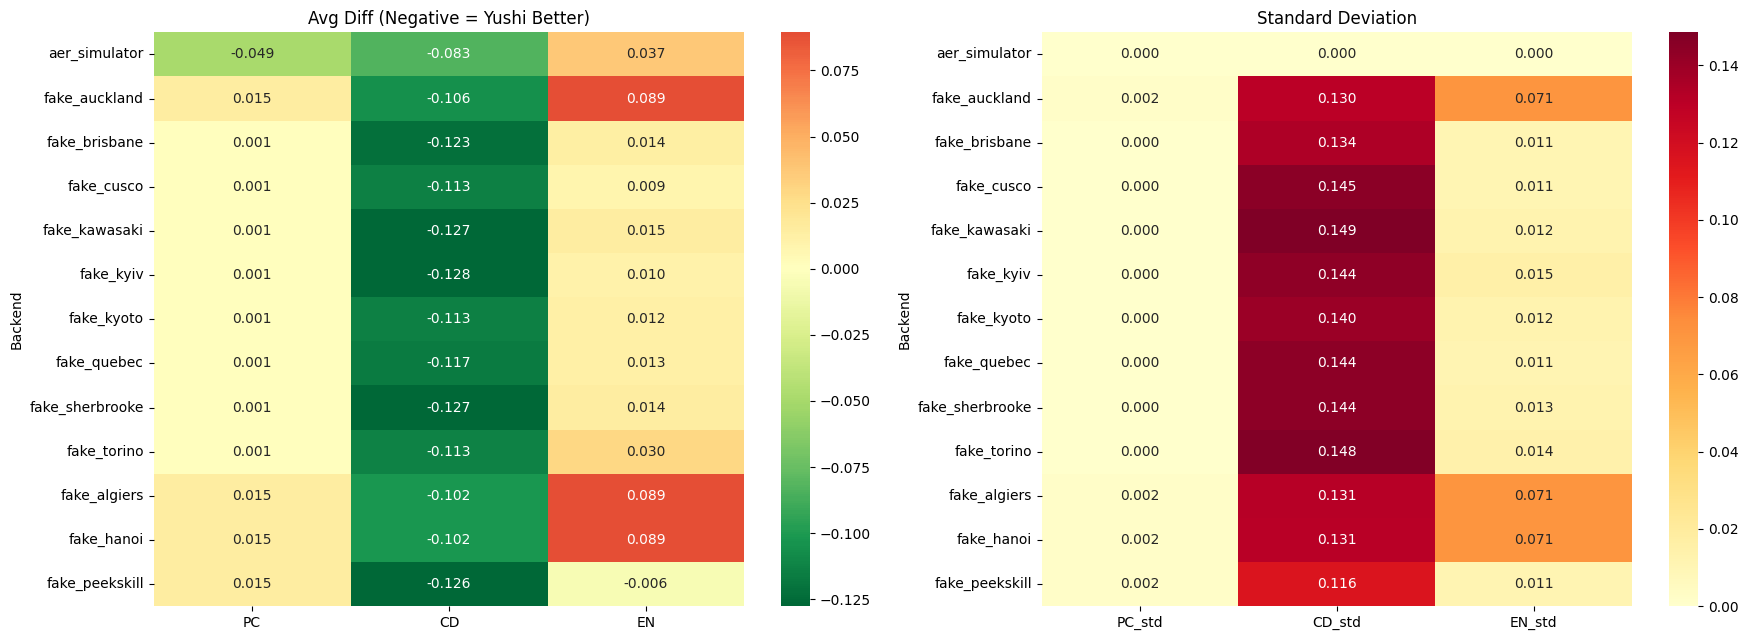

In [96]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from joblib import Parallel, delayed
from tqdm.notebook import tqdm

# ==========================================
# 1. SETUP
# ==========================================
NUM_TRIALS = 1024
N_JOBS = -1 

print(f"Starting benchmark comparison with {NUM_TRIALS} trials across all backends...")
print(f"Running in PARALLEL mode using {N_JOBS} threads.")
print("=" * 80)

backend_use = [AerSimulator(), FakeAuckland(), FakeBrisbane(), FakeCusco(), FakeKawasaki(), FakeKyiv(), FakeKyoto(), 
               FakeQuebec(), FakeSherbrooke(), FakeTorino(), FakeAlgiers(), FakeHanoiV2(), 
               FakePeekskill()]

# ==========================================
# 2. WORKER FUNCTION (Updated to return RAW values)
# ==========================================
def run_benchmark_task(trial_idx, backend):
    try:
        # Check Qubits
        if backend.configuration().n_qubits < collective_circuit_tinthai.num_qubits:
            return None 

        # Transpile
        tinthai_transpiled = transpile(collective_circuit_tinthai, backend=backend, optimization_level=3, seed_transpiler=trial_idx)
        yushi_transpiled = transpile(collective_class.q, backend=backend, optimization_level=3, seed_transpiler=trial_idx)
        
        # Calculate Metrics (Tinthai)
        t_comm = converters.compute_communication_with_qiskit(tinthai_transpiled)
        t_depth = converters.compute_depth_with_qiskit(tinthai_transpiled)
        t_entang = converters.compute_entanglement_with_qiskit(tinthai_transpiled)
        
        # Calculate Metrics (Yushi)
        y_comm = converters.compute_communication_with_qiskit(yushi_transpiled)
        y_depth = converters.compute_depth_with_qiskit(yushi_transpiled)
        y_entang = converters.compute_entanglement_with_qiskit(yushi_transpiled)
        
        # Return Dictionary with ALL RAW VALUES + DIFFS
        return {
            'backend': backend.name,
            # --- Raw Values (สำหรับ Distribution Plot) ---
            'Tinthai_PC': t_comm,
            'Yushi_PC': y_comm,
            'Tinthai_CD': t_depth,
            'Yushi_CD': y_depth,
            'Tinthai_EN': t_entang,
            'Yushi_EN': y_entang,
            
            # --- Differences (สำหรับ Heatmap) ---
            'Diff_PC': t_comm - y_comm,
            'Diff_CD': t_depth - y_depth,
            'Diff_EN': t_entang - y_entang
        }
    except Exception as e:
        # Return nan for all keys if error
        keys = ['Tinthai_PC', 'Yushi_PC', 'Tinthai_CD', 'Yushi_CD', 'Tinthai_EN', 'Yushi_EN', 
                'Diff_PC', 'Diff_CD', 'Diff_EN']
        err_dict = {'backend': backend.name}
        for k in keys: err_dict[k] = np.nan
        return err_dict

# ==========================================
# 3. EXECUTION
# ==========================================
tasks = [(t, b) for t in range(NUM_TRIALS) for b in backend_use]

results = Parallel(n_jobs=N_JOBS)(
    delayed(run_benchmark_task)(t, b) for t, b in tqdm(tasks, desc="Benchmarking")
)

# ==========================================
# 4. AGGREGATE RESULTS
# ==========================================
all_results = defaultdict(lambda: defaultdict(list))
raw_data_list = [] # List สำหรับสร้าง DataFrame แบบละเอียด

for res in results:
    if res is None: continue 
    
    bn = res['backend']
    
    # เก็บลง Dictionary รวม
    for key, val in res.items():
        if key != 'backend':
            all_results[bn][key].append(val)
            
    # เก็บลง List เพื่อทำ DataFrame สำหรับ Distribution (Long format)
    # เราจะข้าม NaN ไปเลยเพื่อให้ Clean
    if not np.isnan(res['Diff_PC']): # เช็คตัวเดียวก็พอ ถ้าตัวนึง nan ที่เหลือก็คง nan
        raw_data_list.append(res)

print("\n" + "=" * 80)
print("Processing completed!")

# สร้าง DataFrame แบบละเอียด (Raw Data Frame)
# ตารางนี้จะมี 1 แถวต่อ 1 Trial เอาไป Plot Distribution ได้เลย
df_raw = pd.DataFrame(raw_data_list)
print(f"Captured {len(df_raw)} valid trials.")

# ==========================================
# 5. HEATMAP VISUALIZATION (ใช้ค่า Diff เหมือนเดิม)
# ==========================================
comparison_results = []

for backend_name in all_results.keys():
    # ใช้ค่า Diff มาหา Average เพื่อทำ Heatmap
    avg_comm = np.nanmean(all_results[backend_name]['Diff_PC'])
    avg_depth = np.nanmean(all_results[backend_name]['Diff_CD'])
    avg_entang = np.nanmean(all_results[backend_name]['Diff_EN'])
    
    std_comm = np.nanstd(all_results[backend_name]['Diff_PC'])
    std_depth = np.nanstd(all_results[backend_name]['Diff_CD'])
    std_entang = np.nanstd(all_results[backend_name]['Diff_EN'])
    
    comparison_results.append({
        'Backend': backend_name,
        'PC': avg_comm, 'CD': avg_depth, 'EN': avg_entang,
        'PC_std': std_comm, 'CD_std': std_depth, 'EN_std': std_entang
    })

df_comparison = pd.DataFrame(comparison_results)

if not df_comparison.empty:
    df_comparison_display = df_comparison[['Backend', 'PC', 'CD', 'EN']].set_index('Backend')
    df_std = df_comparison[['Backend', 'PC_std', 'CD_std', 'EN_std']].set_index('Backend')

    print("\nAverage Difference (Tinthai - Yushi):")
    print(df_comparison_display)

    # Plot Heatmap
    fig, axes = plt.subplots(1, 2, figsize=(18, len(backend_use) * 0.5))
    sns.heatmap(df_comparison_display, annot=True, fmt='.3f', cmap='RdYlGn_r', center=0, ax=axes[0])
    axes[0].set_title('Avg Diff (Negative = Yushi Better)')
    
    sns.heatmap(df_std, annot=True, fmt='.3f', cmap='YlOrRd', ax=axes[1])
    axes[1].set_title('Standard Deviation')
    
    plt.tight_layout()
    plt.show()

else:
    print("No valid results.")

<>:89: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:109: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:116: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:116: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:116: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:144: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:147: SyntaxWarning: "\D" is an invalid escape sequence. Such sequenc

Generating academic summary tables...
>>> Figure 1: Medium-Scale Architectures


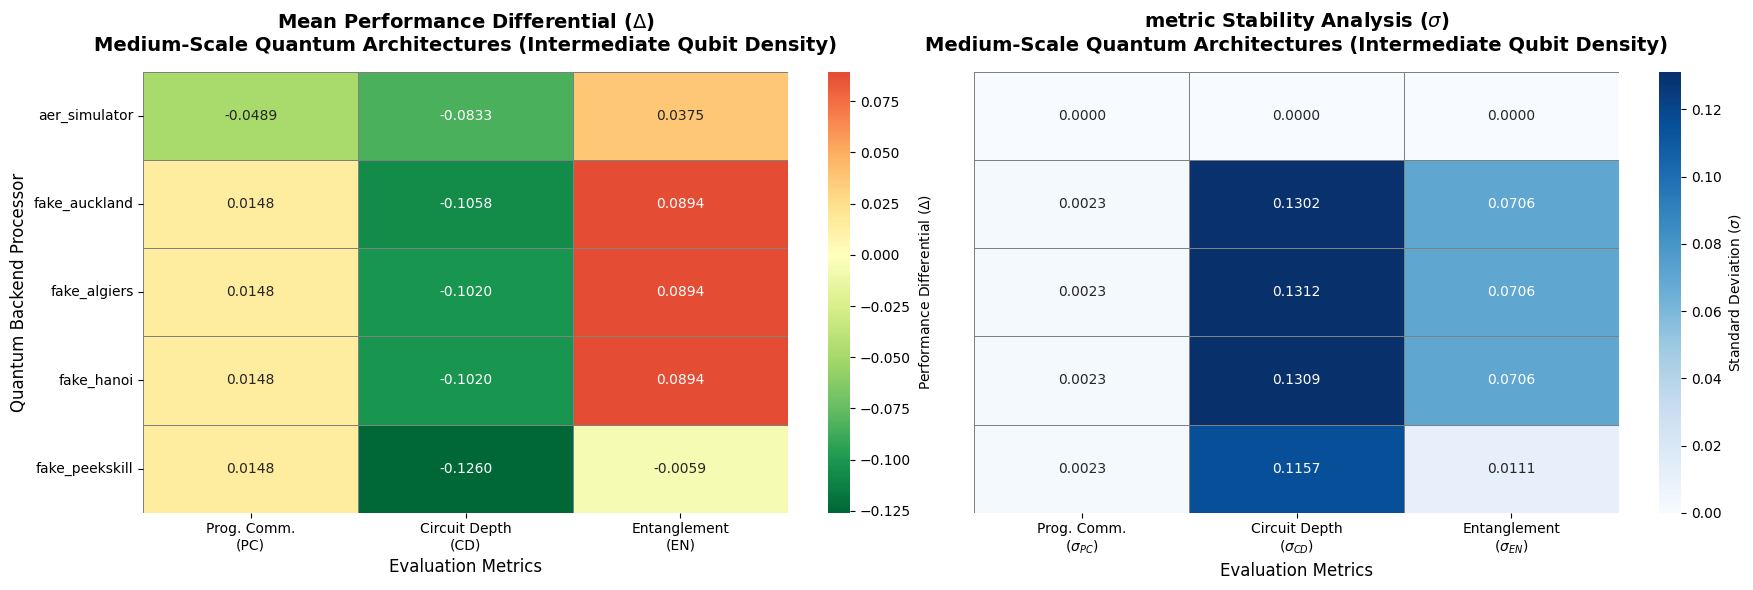



>>> Figure 2: Large-Scale Architectures


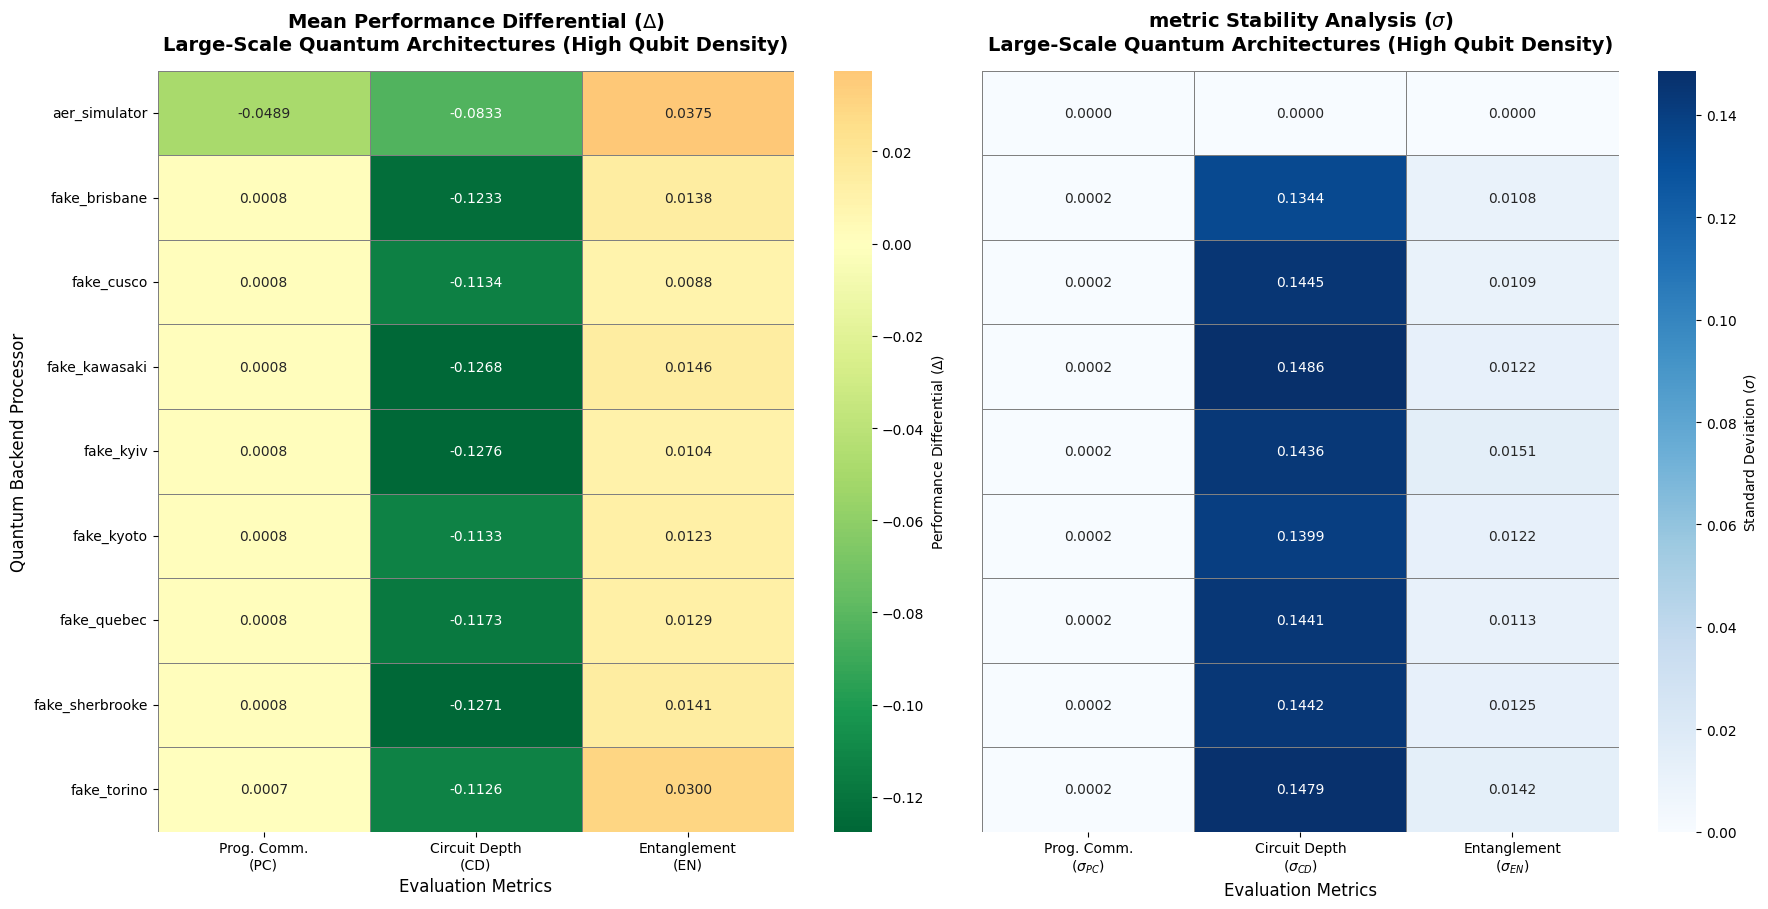


STATISTICAL SUMMARY TABLES

--- Medium-Scale Processors (Mean Performance $\Delta$) ---
                      PC        CD        EN
Backend                                     
aer_simulator  -0.048918 -0.083333  0.037500
fake_auckland   0.014804 -0.105821  0.089401
fake_algiers    0.014804 -0.102007  0.089401
fake_hanoi      0.014804 -0.101966  0.089401
fake_peekskill  0.014804 -0.125956 -0.005941

--- Large-Scale Processors (Mean Performance $\Delta$) ---
                       PC        CD        EN
Backend                                      
aer_simulator   -0.048918 -0.083333  0.037500
fake_brisbane    0.000770 -0.123344  0.013837
fake_cusco       0.000770 -0.113442  0.008815
fake_kawasaki    0.000770 -0.126796  0.014610
fake_kyiv        0.000770 -0.127593  0.010355
fake_kyoto       0.000770 -0.113257  0.012317
fake_quebec      0.000770 -0.117342  0.012902
fake_sherbrooke  0.000770 -0.127107  0.014142
fake_torino      0.000738 -0.112599  0.030012


In [97]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. Aggregation (รวบรวมข้อมูลรวมก่อน)
# ==========================================
print("Generating academic summary tables...")

comparison_results = []
for backend_name in all_results.keys():
    # Check data availability
    if not all_results[backend_name]['Diff_PC']:
        continue
        
    # Calculate Mean and Std
    avg_comm = np.nanmean(all_results[backend_name]['Diff_PC'])
    avg_depth = np.nanmean(all_results[backend_name]['Diff_CD'])
    avg_entang = np.nanmean(all_results[backend_name]['Diff_EN'])
    
    std_comm = np.nanstd(all_results[backend_name]['Diff_PC'])
    std_depth = np.nanstd(all_results[backend_name]['Diff_CD'])
    std_entang = np.nanstd(all_results[backend_name]['Diff_EN'])
    
    comparison_results.append({
        'Backend': backend_name,
        'PC': avg_comm, 'CD': avg_depth, 'EN': avg_entang,
        'PC_std': std_comm, 'CD_std': std_depth, 'EN_std': std_entang
    })

# Master DataFrames
df_main = pd.DataFrame(comparison_results).set_index('Backend')
df_mean = df_main[['PC', 'CD', 'EN']]
df_std = df_main[['PC_std', 'CD_std', 'EN_std']]

# ==========================================
# 2. Categorization Logic (แยก Medium vs Large)
# ==========================================
# หมายเหตุ: ชื่อ Backend ใน dict key มักจะเป็น lowercase (เช่น 'fake_auckland') 
# ต้องตรวจสอบให้ตรงกับที่เก็บใน all_results

medium_backends_list = [
    'aer_simulator', 'fake_auckland', 'fake_algiers', 'fake_hanoi', 'fake_peekskill', 
    'fake_lagos', 'fake_nairobi' # รวมตัวเล็กอื่นๆ เผื่อมี
]
large_backends_list = [
    'aer_simulator', 'fake_brisbane', 'fake_cusco', 'fake_kawasaki', 'fake_kyiv', 
    'fake_kyoto', 'fake_quebec', 'fake_sherbrooke', 'fake_torino'
]

# Filter DataFrames
# ใช้ intersection ของ index เพื่อป้องกัน error กรณี backend ไหนไม่มีผลลัพธ์
valid_medium = [b for b in medium_backends_list if b in df_mean.index]
valid_large = [b for b in large_backends_list if b in df_mean.index]

df_mean_medium = df_mean.loc[valid_medium]
df_std_medium = df_std.loc[valid_medium]

df_mean_large = df_mean.loc[valid_large]
df_std_large = df_std.loc[valid_large]

# ==========================================
# 3. Helper Function for Academic Plotting
# ==========================================
def plot_academic_heatmap(df_m, df_s, category_name):
    """
    Function to generate professional heatmaps for specific category
    """
    if df_m.empty:
        print(f"No data available for {category_name}")
        return

    # Setup Figure (2 Subplots: Mean vs Std)
    fig, axes = plt.subplots(1, 2, figsize=(18, len(df_m) * 0.8 + 2))
    
    # --- Plot 1: Mean Performance Differential ---
    sns.heatmap(df_m, 
                annot=True, 
                fmt='.4f', 
                cmap='RdYlGn_r', # Green = Negative (Better)
                center=0, 
                linewidths=0.5,
                linecolor='gray',
                cbar_kws={'label': r'Performance Differential ($\Delta$)'},
                ax=axes[0])
    
    # Academic Titles
    axes[0].set_title(f'Mean Performance Differential ($\Delta$)\n{category_name}', 
                      fontsize=14, fontweight='bold', pad=15)
    axes[0].set_xlabel('Evaluation Metrics', fontsize=12)
    axes[0].set_ylabel('Quantum Backend Processor', fontsize=12)
    
    # Rename X-ticks for professional look
    axes[0].set_xticklabels([
        'Prog. Comm.\n(PC)', 'Circuit Depth\n(CD)', 'Entanglement\n(EN)'
    ], rotation=0)

    # --- Plot 2: Stability (Standard Deviation) ---
    sns.heatmap(df_s, 
                annot=True, 
                fmt='.4f', 
                cmap='Blues', # Professional Blue tone for Std
                linewidths=0.5,
                linecolor='gray',
                cbar_kws={'label': r'Standard Deviation ($\sigma$)'},
                ax=axes[1])
    
    axes[1].set_title(f'metric Stability Analysis ($\sigma$)\n{category_name}', 
                      fontsize=14, fontweight='bold', pad=15)
    axes[1].set_xlabel('Evaluation Metrics', fontsize=12)
    axes[1].set_ylabel('') # Hide Y label for second plot
    axes[1].set_yticks([]) # Hide Y ticks
    
    axes[1].set_xticklabels([
        'Prog. Comm.\n($\sigma_{PC}$)', 'Circuit Depth\n($\sigma_{CD}$)', 'Entanglement\n($\sigma_{EN}$)'
    ], rotation=0)

    # Layout Adjustment
    plt.tight_layout()
    plt.show()

# ==========================================
# 4. Generate Plots
# ==========================================

print(">>> Figure 1: Medium-Scale Architectures")
plot_academic_heatmap(df_mean_medium, df_std_medium, 
                      "Medium-Scale Quantum Architectures (Intermediate Qubit Density)")

print("\n" + "="*80 + "\n")

print(">>> Figure 2: Large-Scale Architectures")
plot_academic_heatmap(df_mean_large, df_std_large, 
                      "Large-Scale Quantum Architectures (High Qubit Density)")

# ==========================================
# 5. Summary Tables (แยกตารางให้ดูง่าย)
# ==========================================
print("\n" + "="*80)
print("STATISTICAL SUMMARY TABLES")
print("="*80)

print("\n--- Medium-Scale Processors (Mean Performance $\Delta$) ---")
print(df_mean_medium)

print("\n--- Large-Scale Processors (Mean Performance $\Delta$) ---")
print(df_mean_large)

Data Prepared: 79872 rows
Medium-Scale Data: 30720 rows
Large-Scale Data: 55296 rows

>>> Processing: Medium-Scale Quantum Architectures (Intermediate Qubit Density)


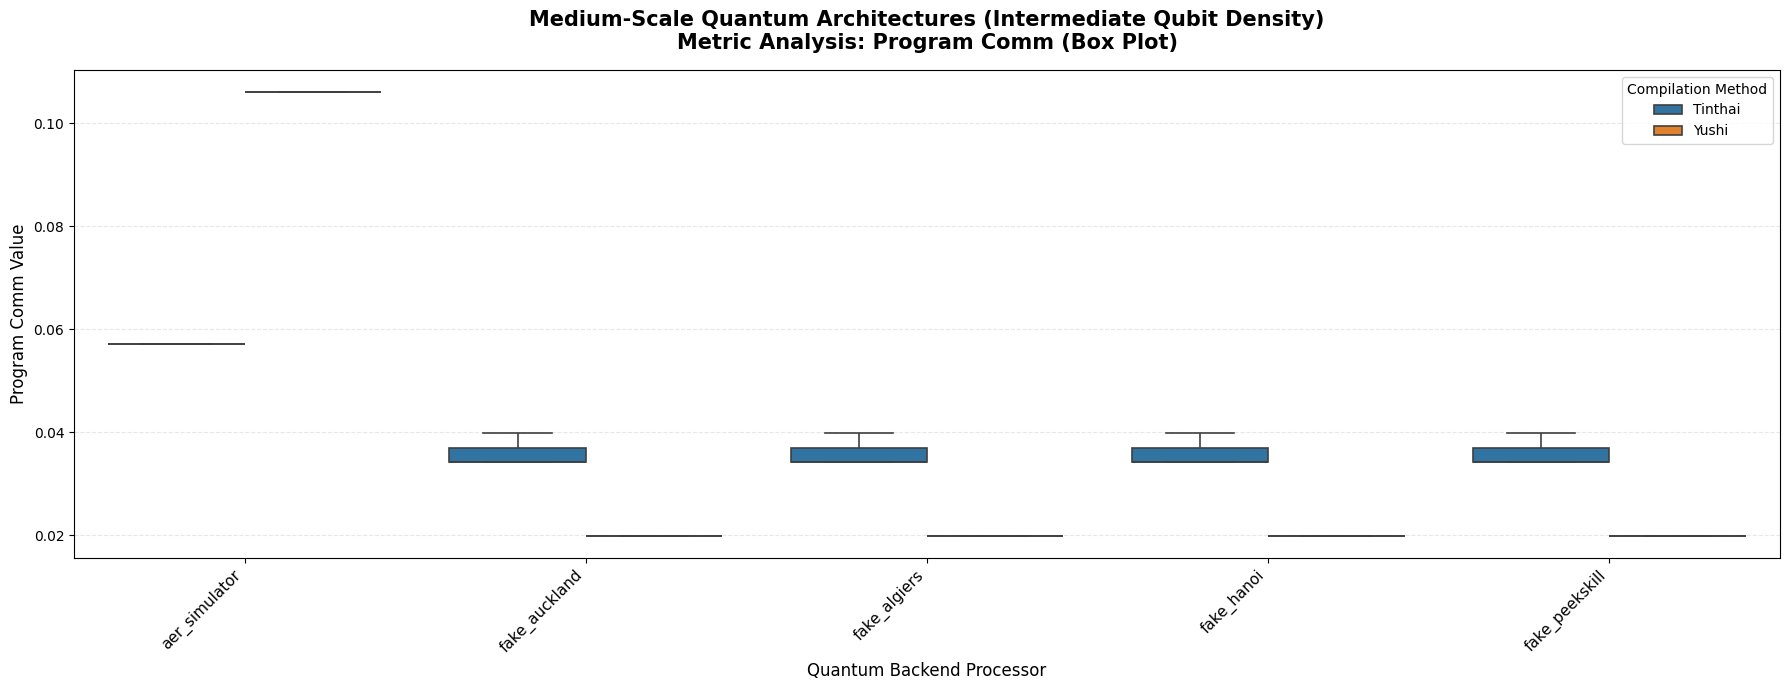

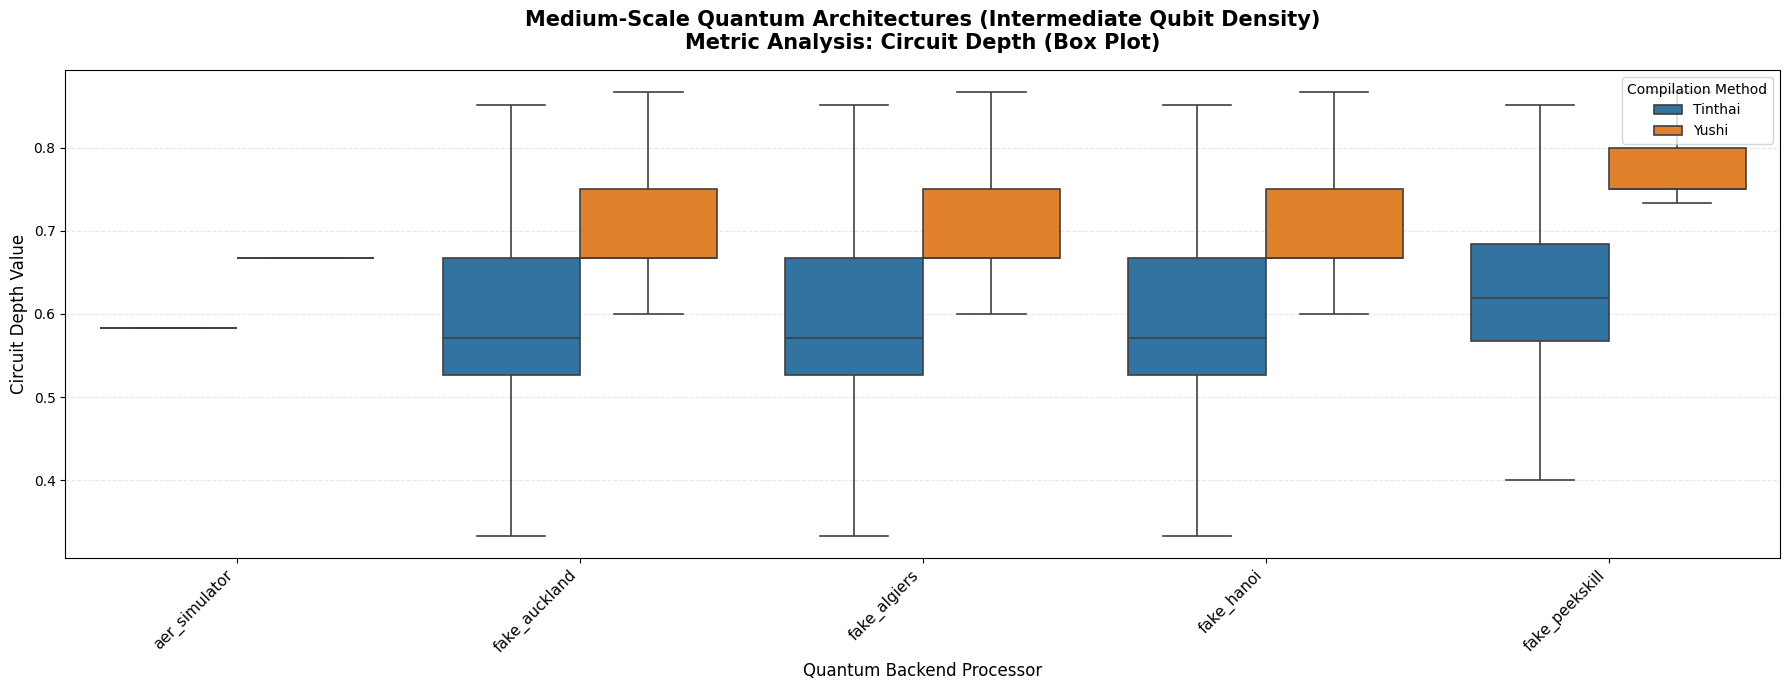

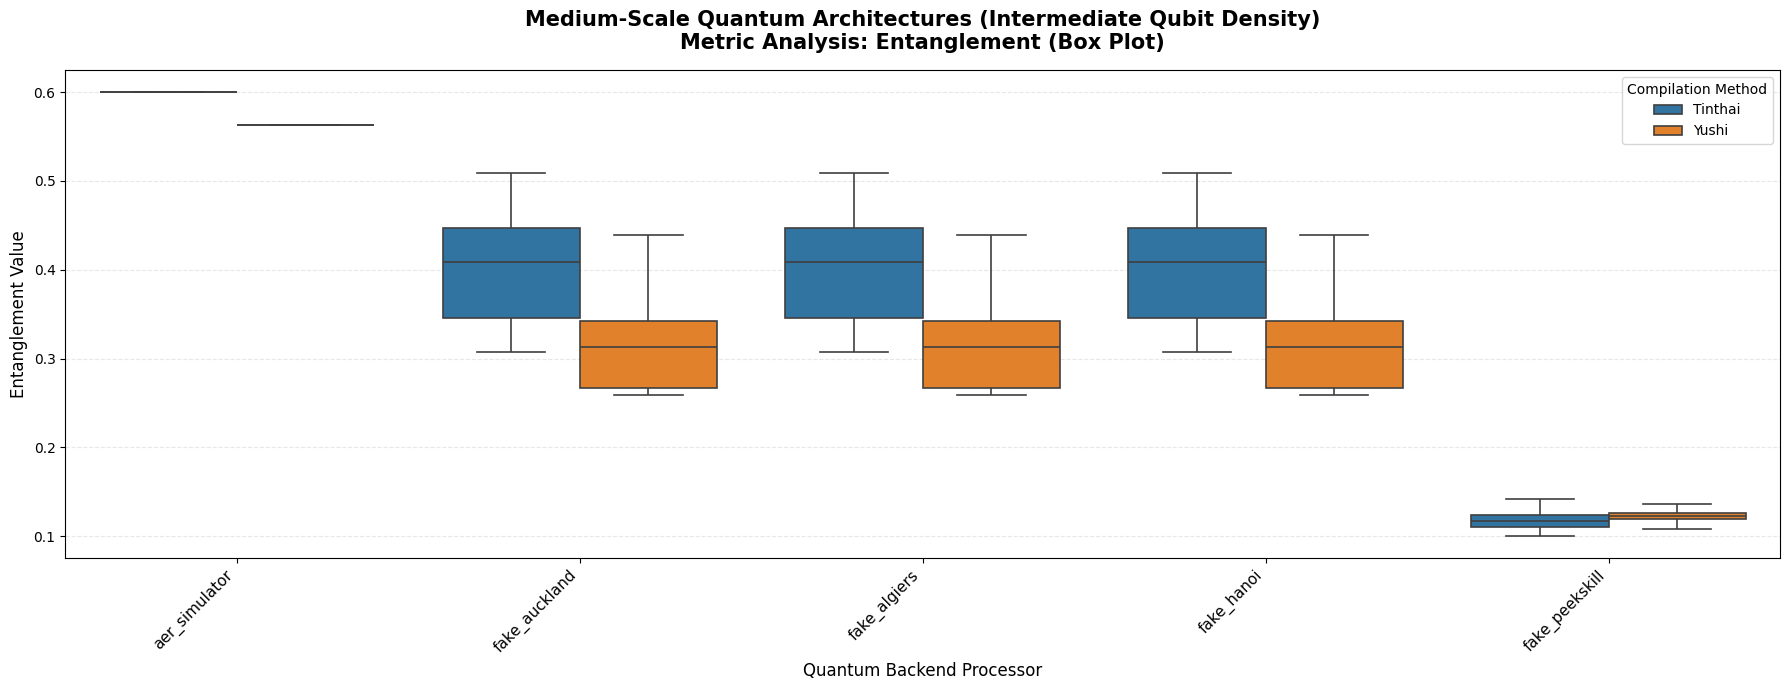

Generating Distribution Grid for Program Comm (Medium-Scale Quantum Architectures (Intermediate Qubit Density))...


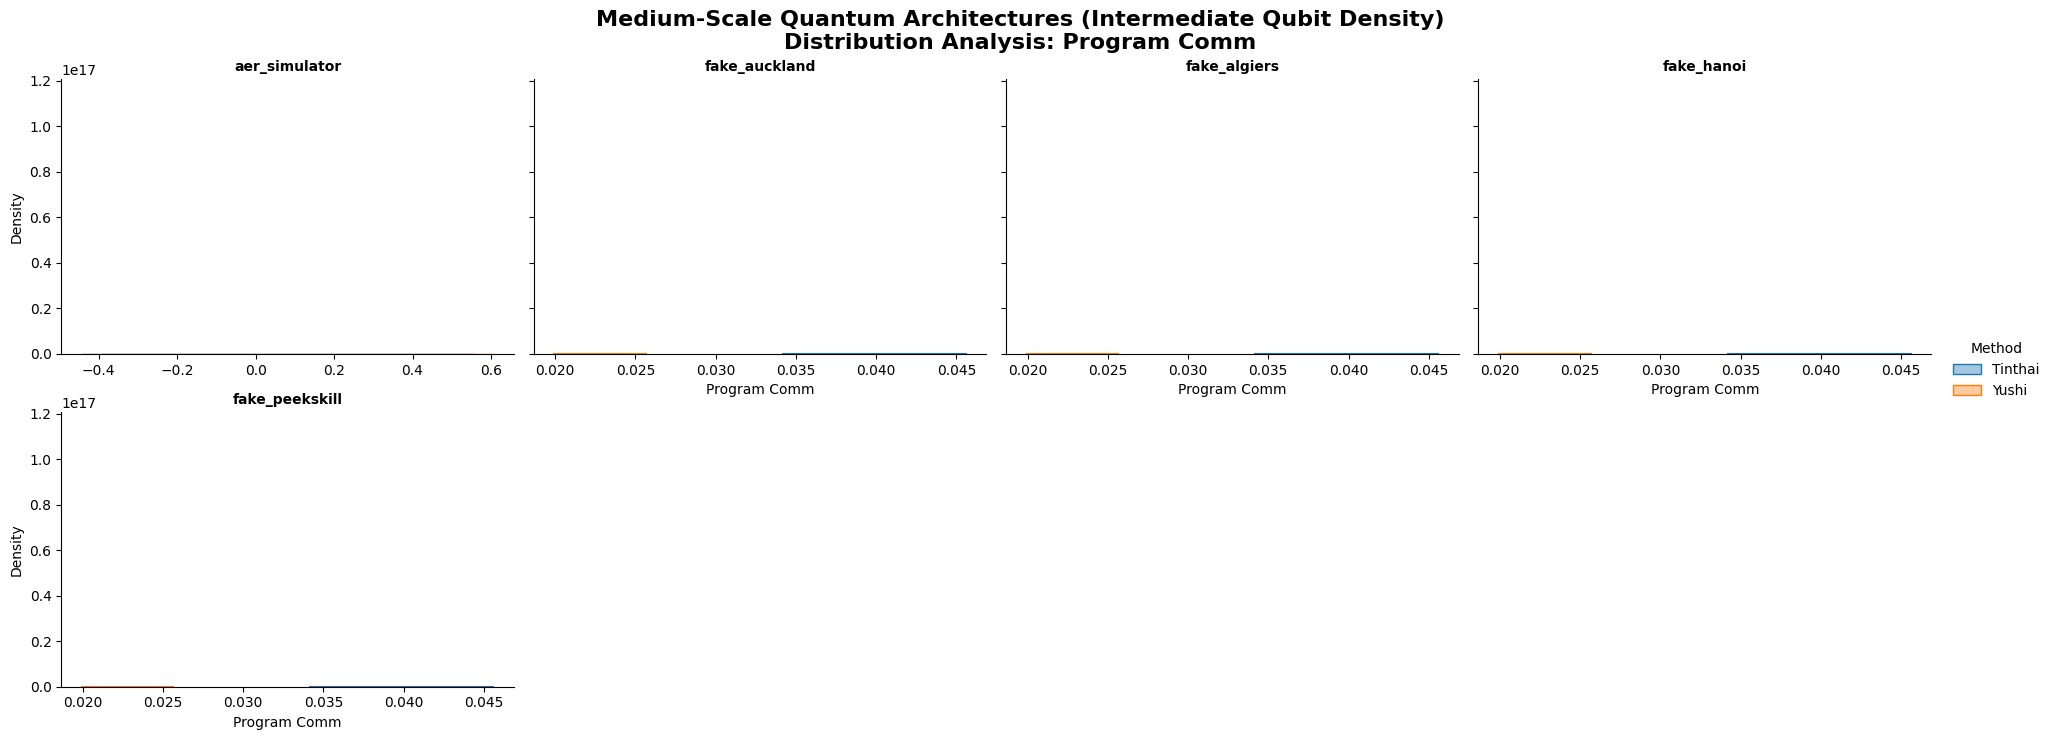

Generating Distribution Grid for Circuit Depth (Medium-Scale Quantum Architectures (Intermediate Qubit Density))...


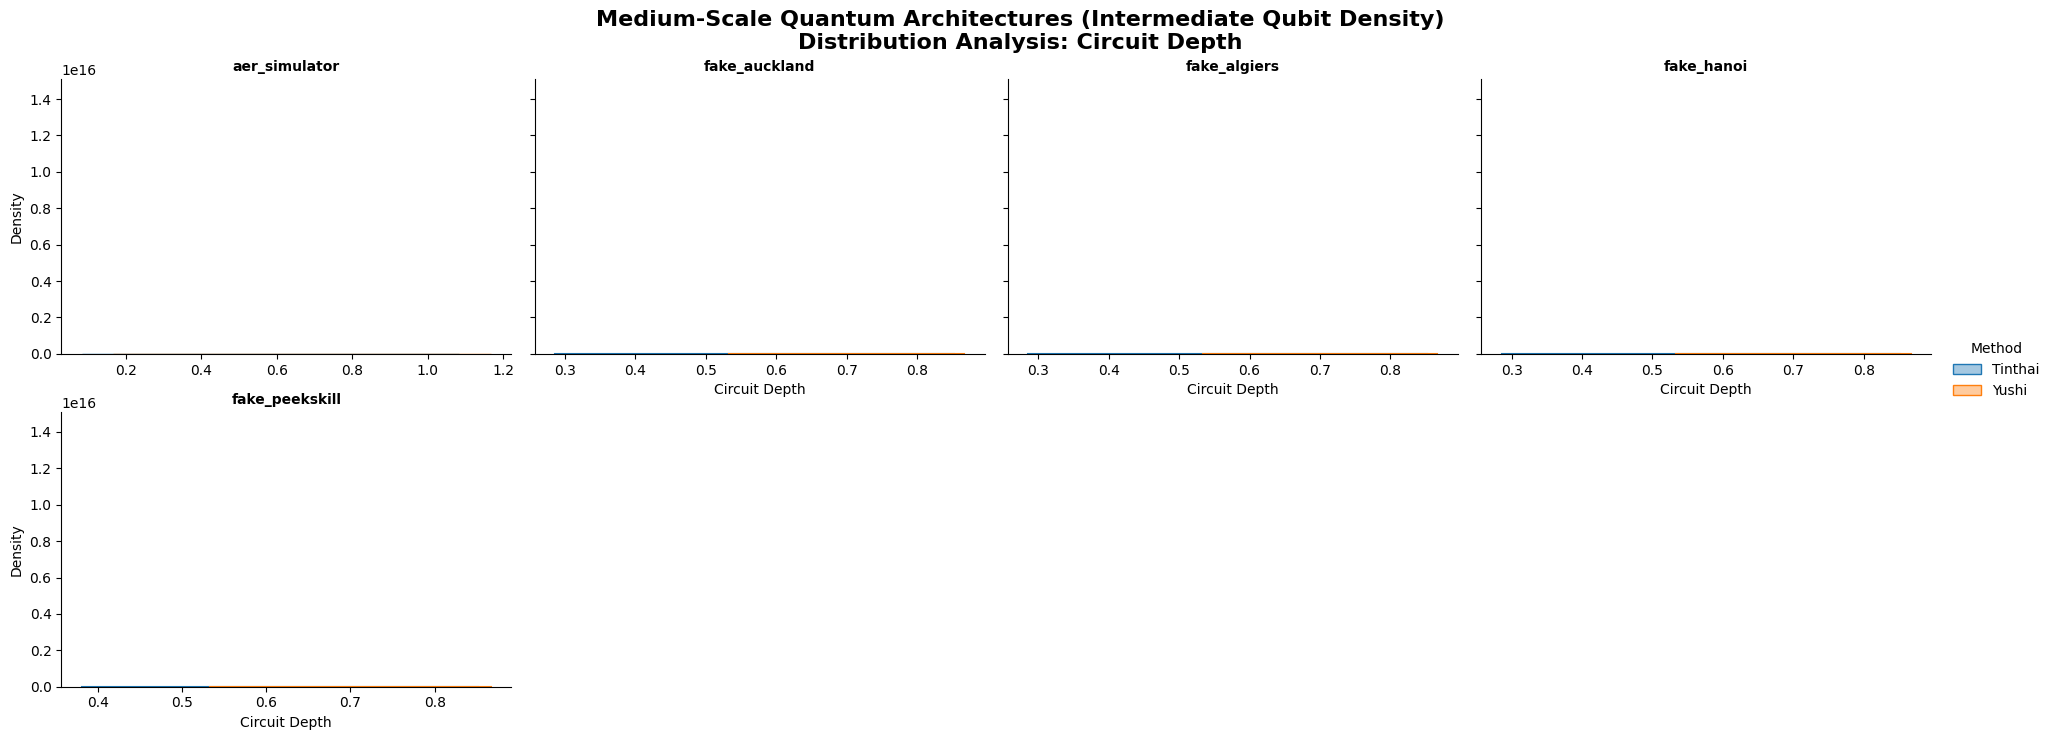

Generating Distribution Grid for Entanglement (Medium-Scale Quantum Architectures (Intermediate Qubit Density))...


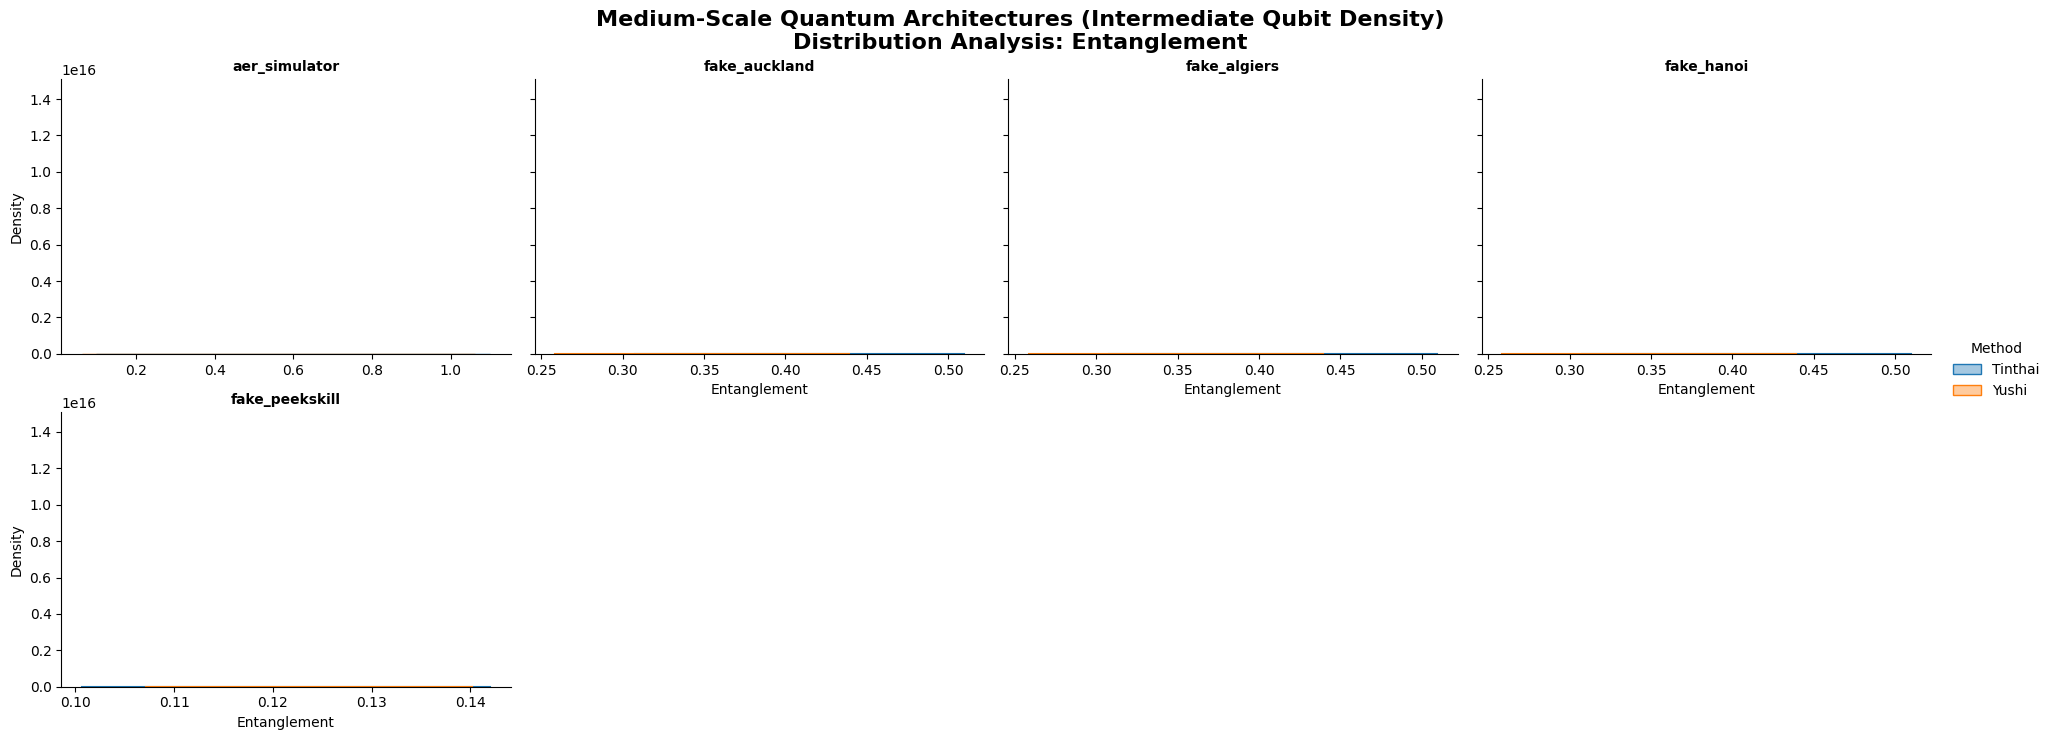


>>> Processing: Large-Scale Quantum Architectures (High Qubit Density)


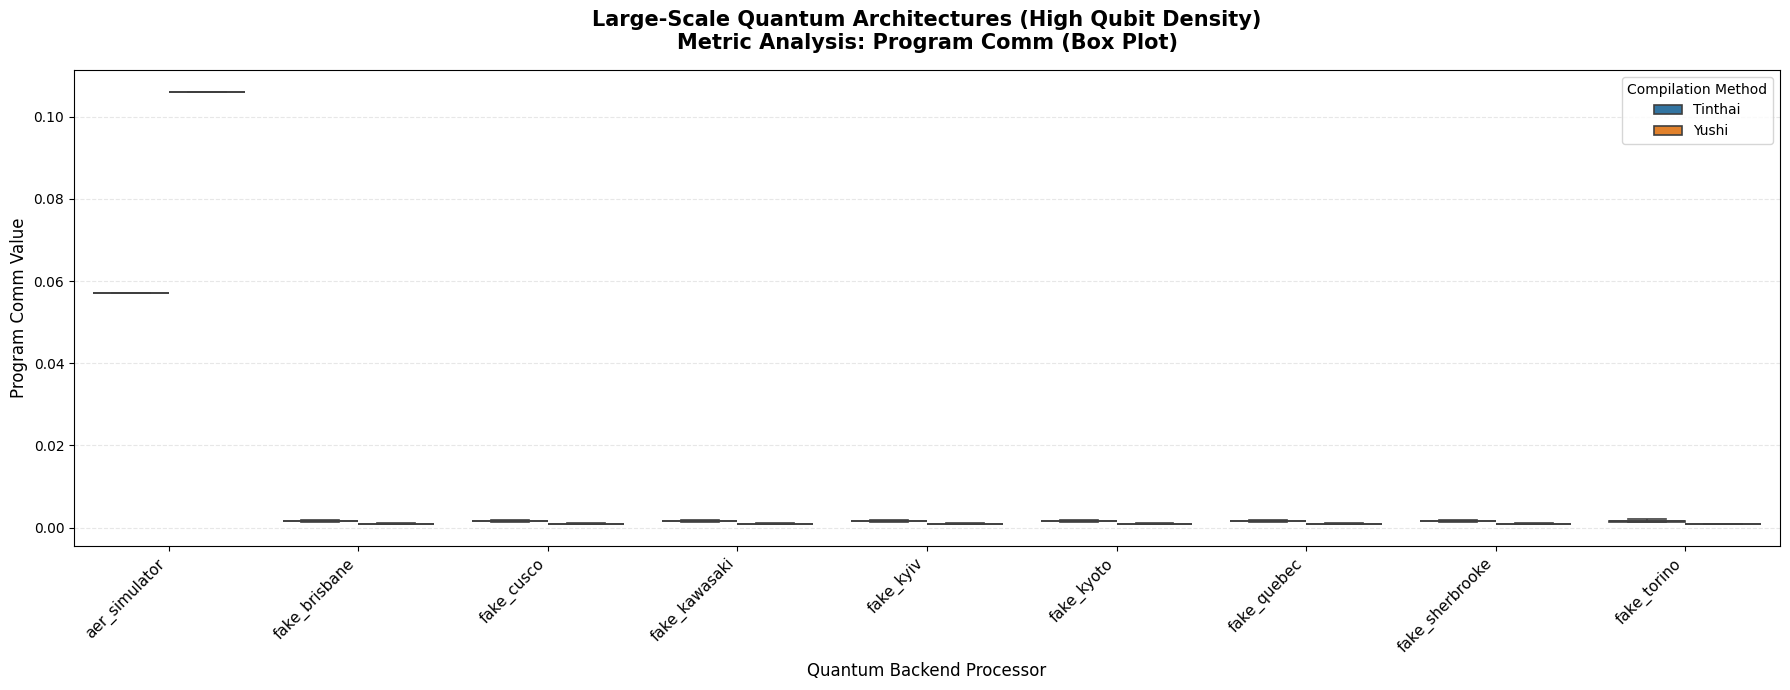

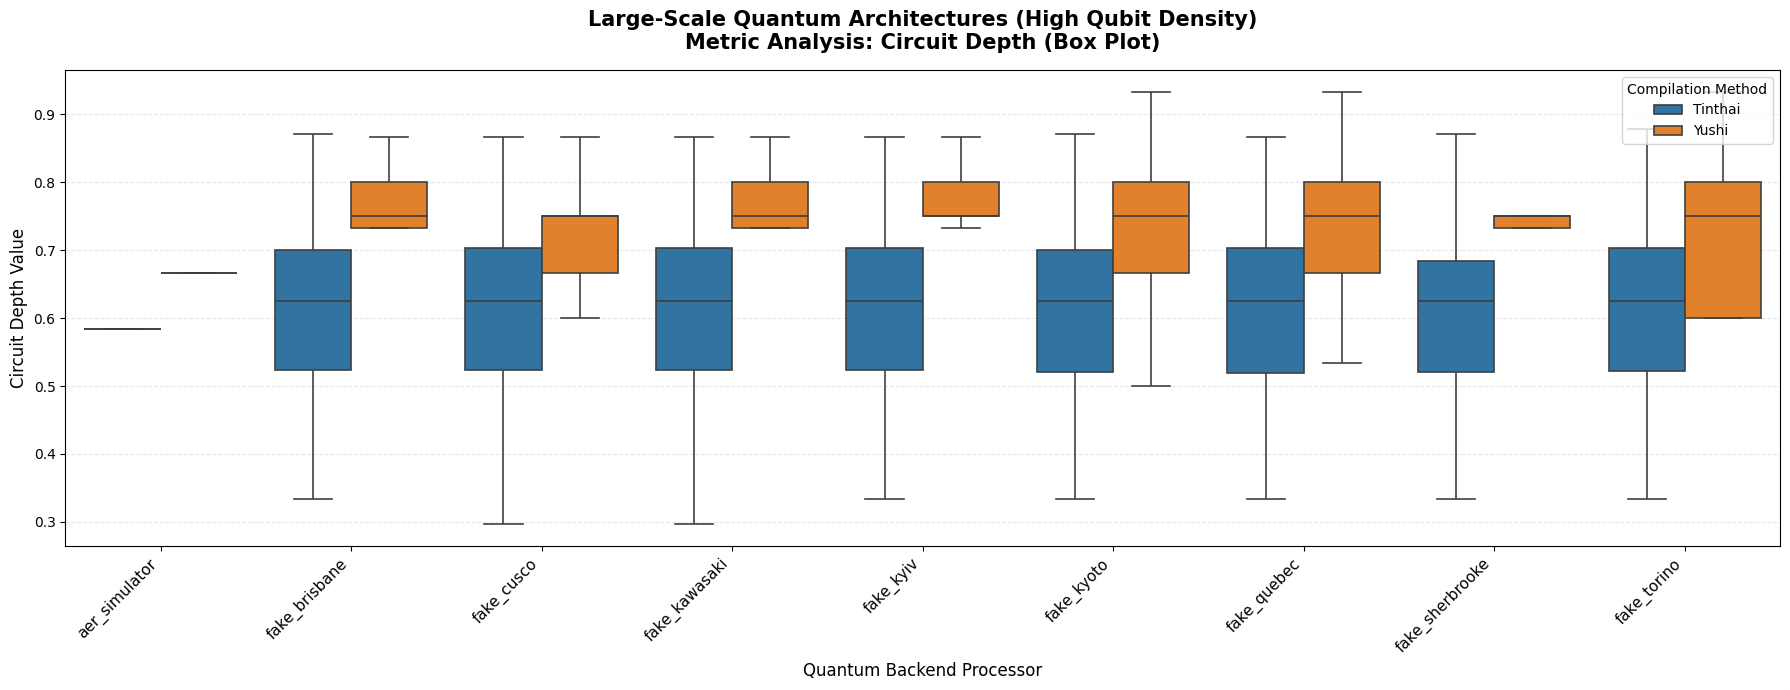

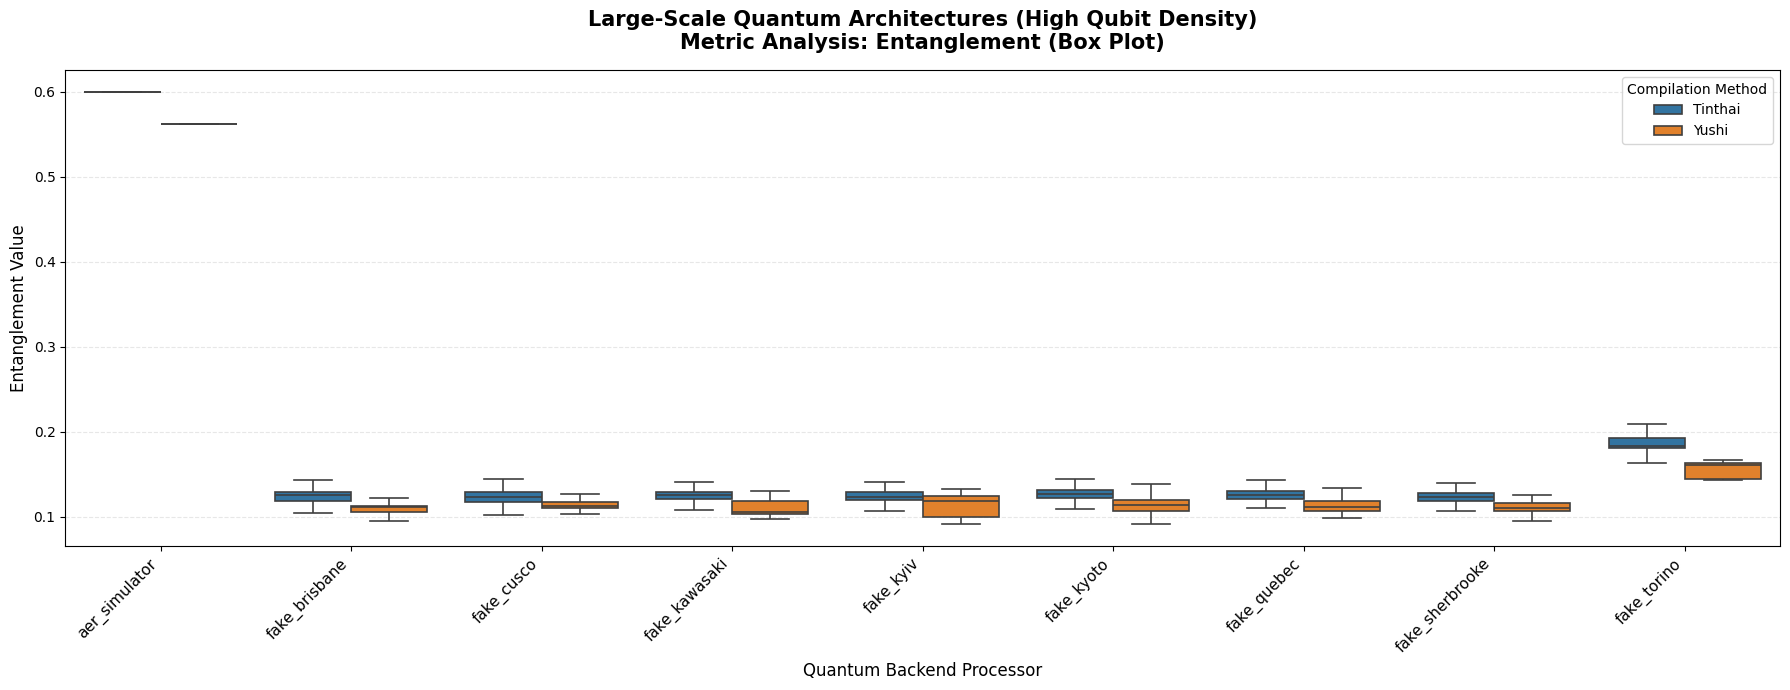

Generating Distribution Grid for Program Comm (Large-Scale Quantum Architectures (High Qubit Density))...


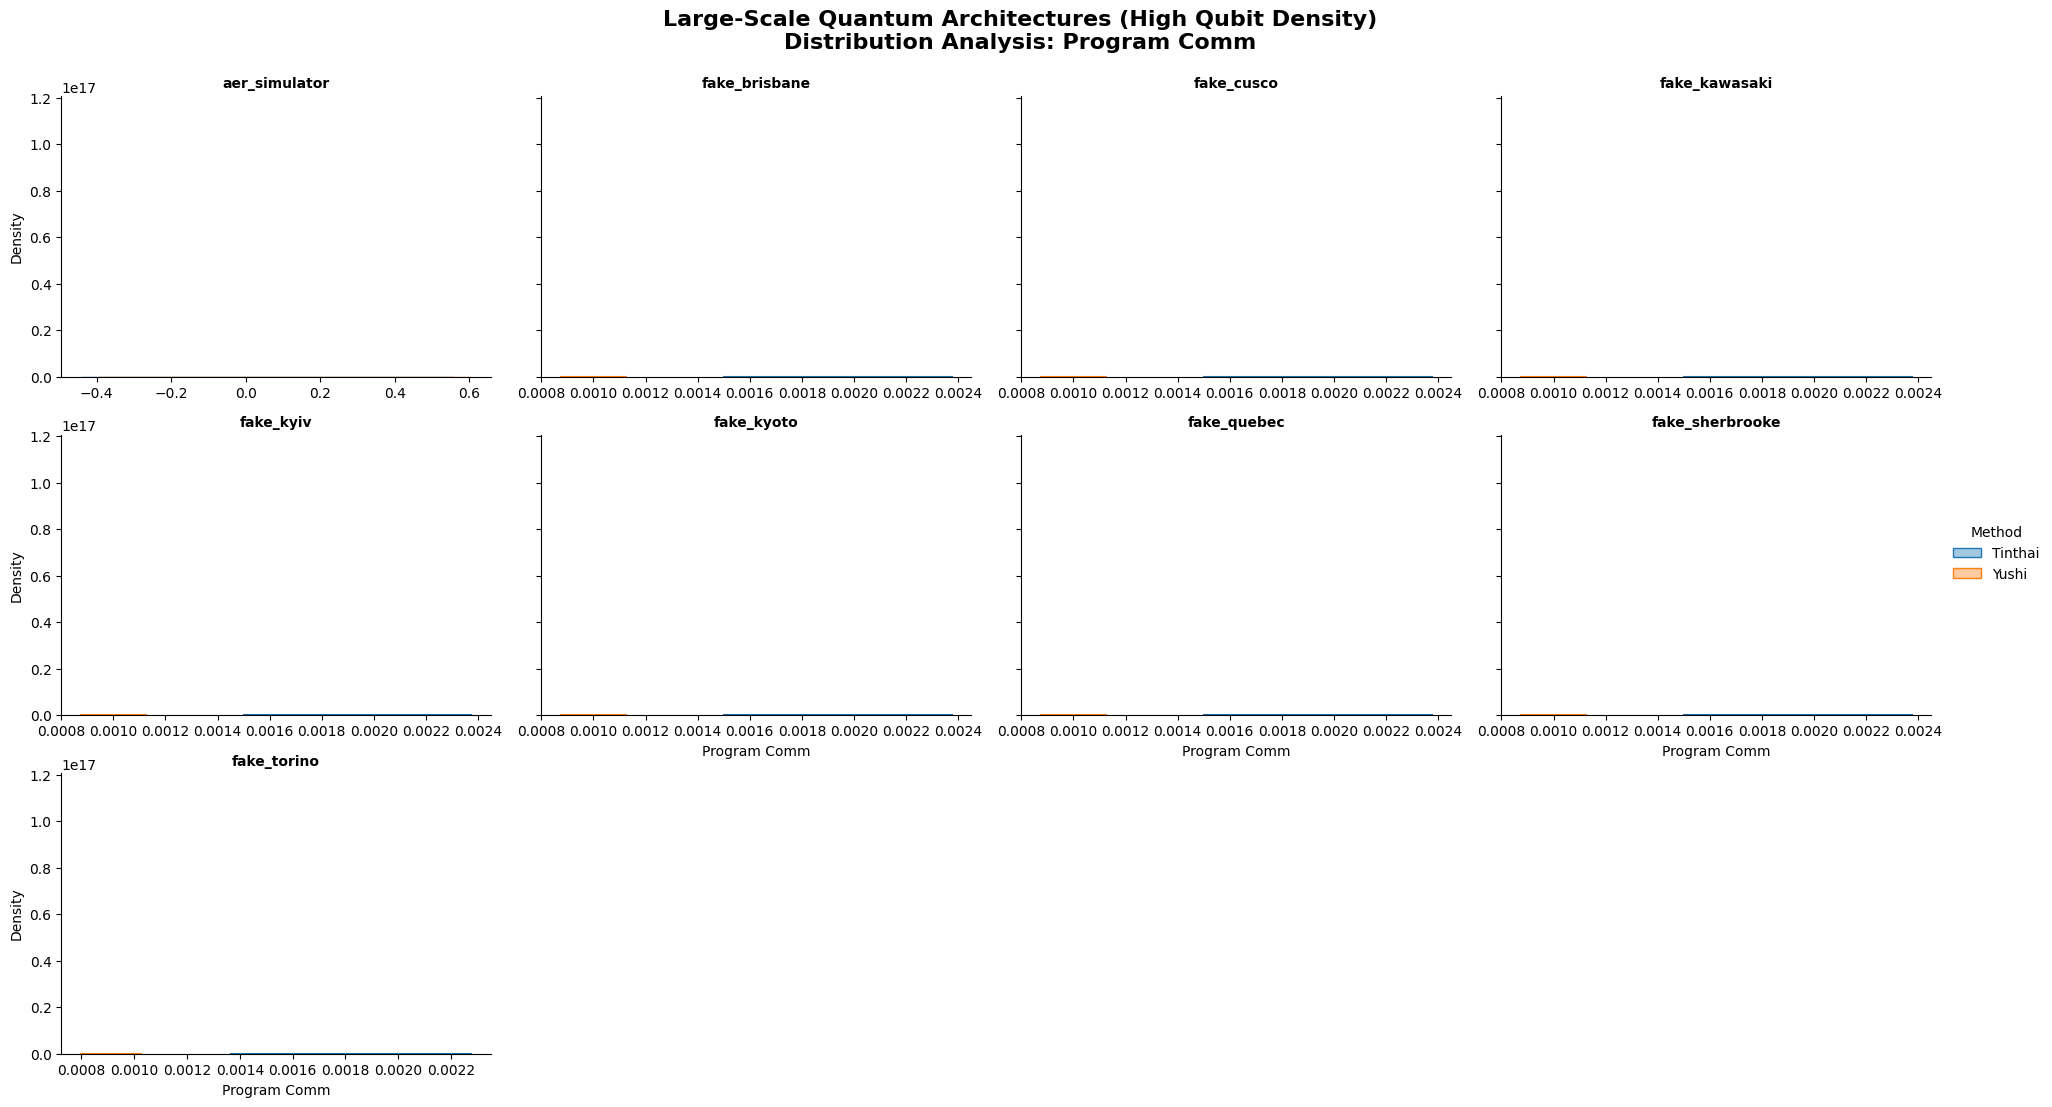

Generating Distribution Grid for Circuit Depth (Large-Scale Quantum Architectures (High Qubit Density))...


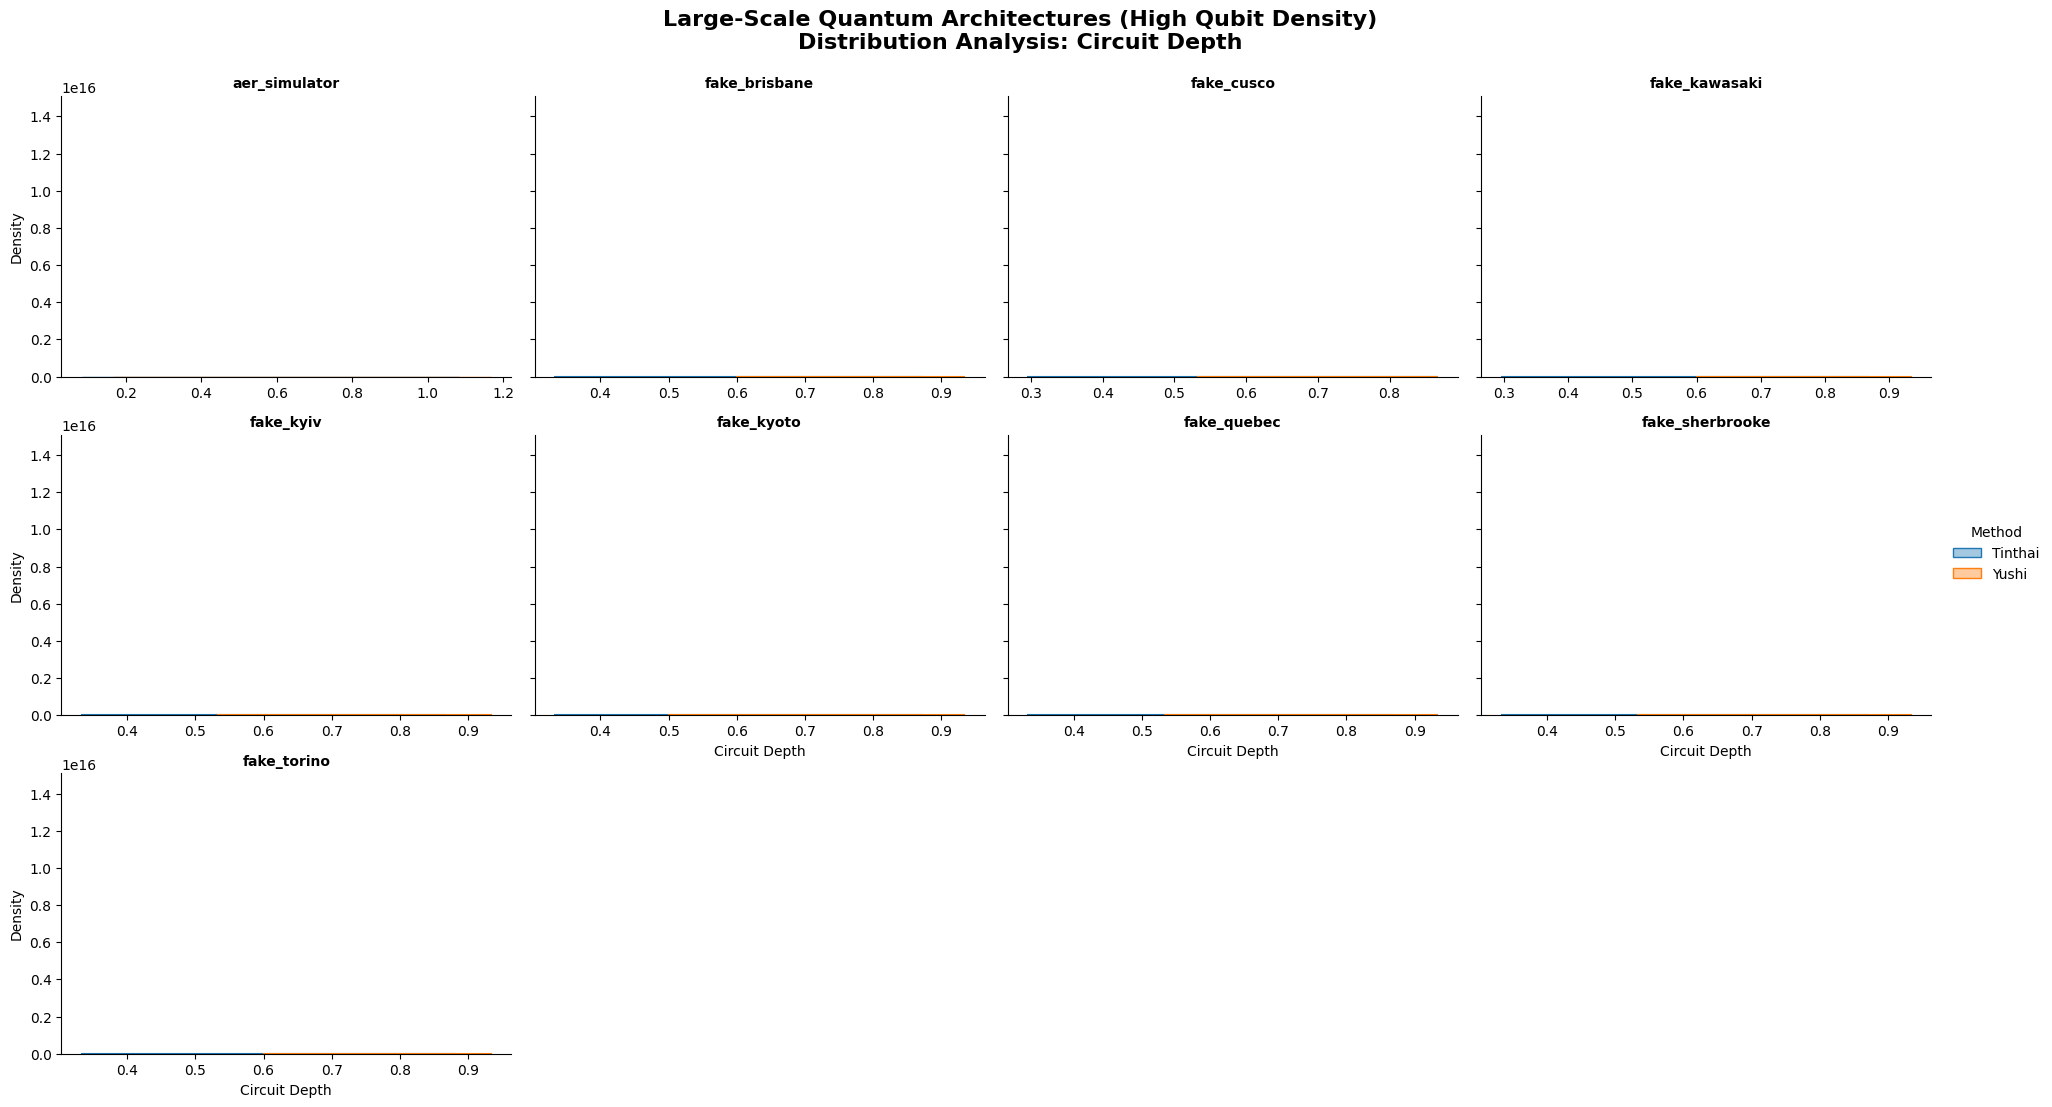

Generating Distribution Grid for Entanglement (Large-Scale Quantum Architectures (High Qubit Density))...


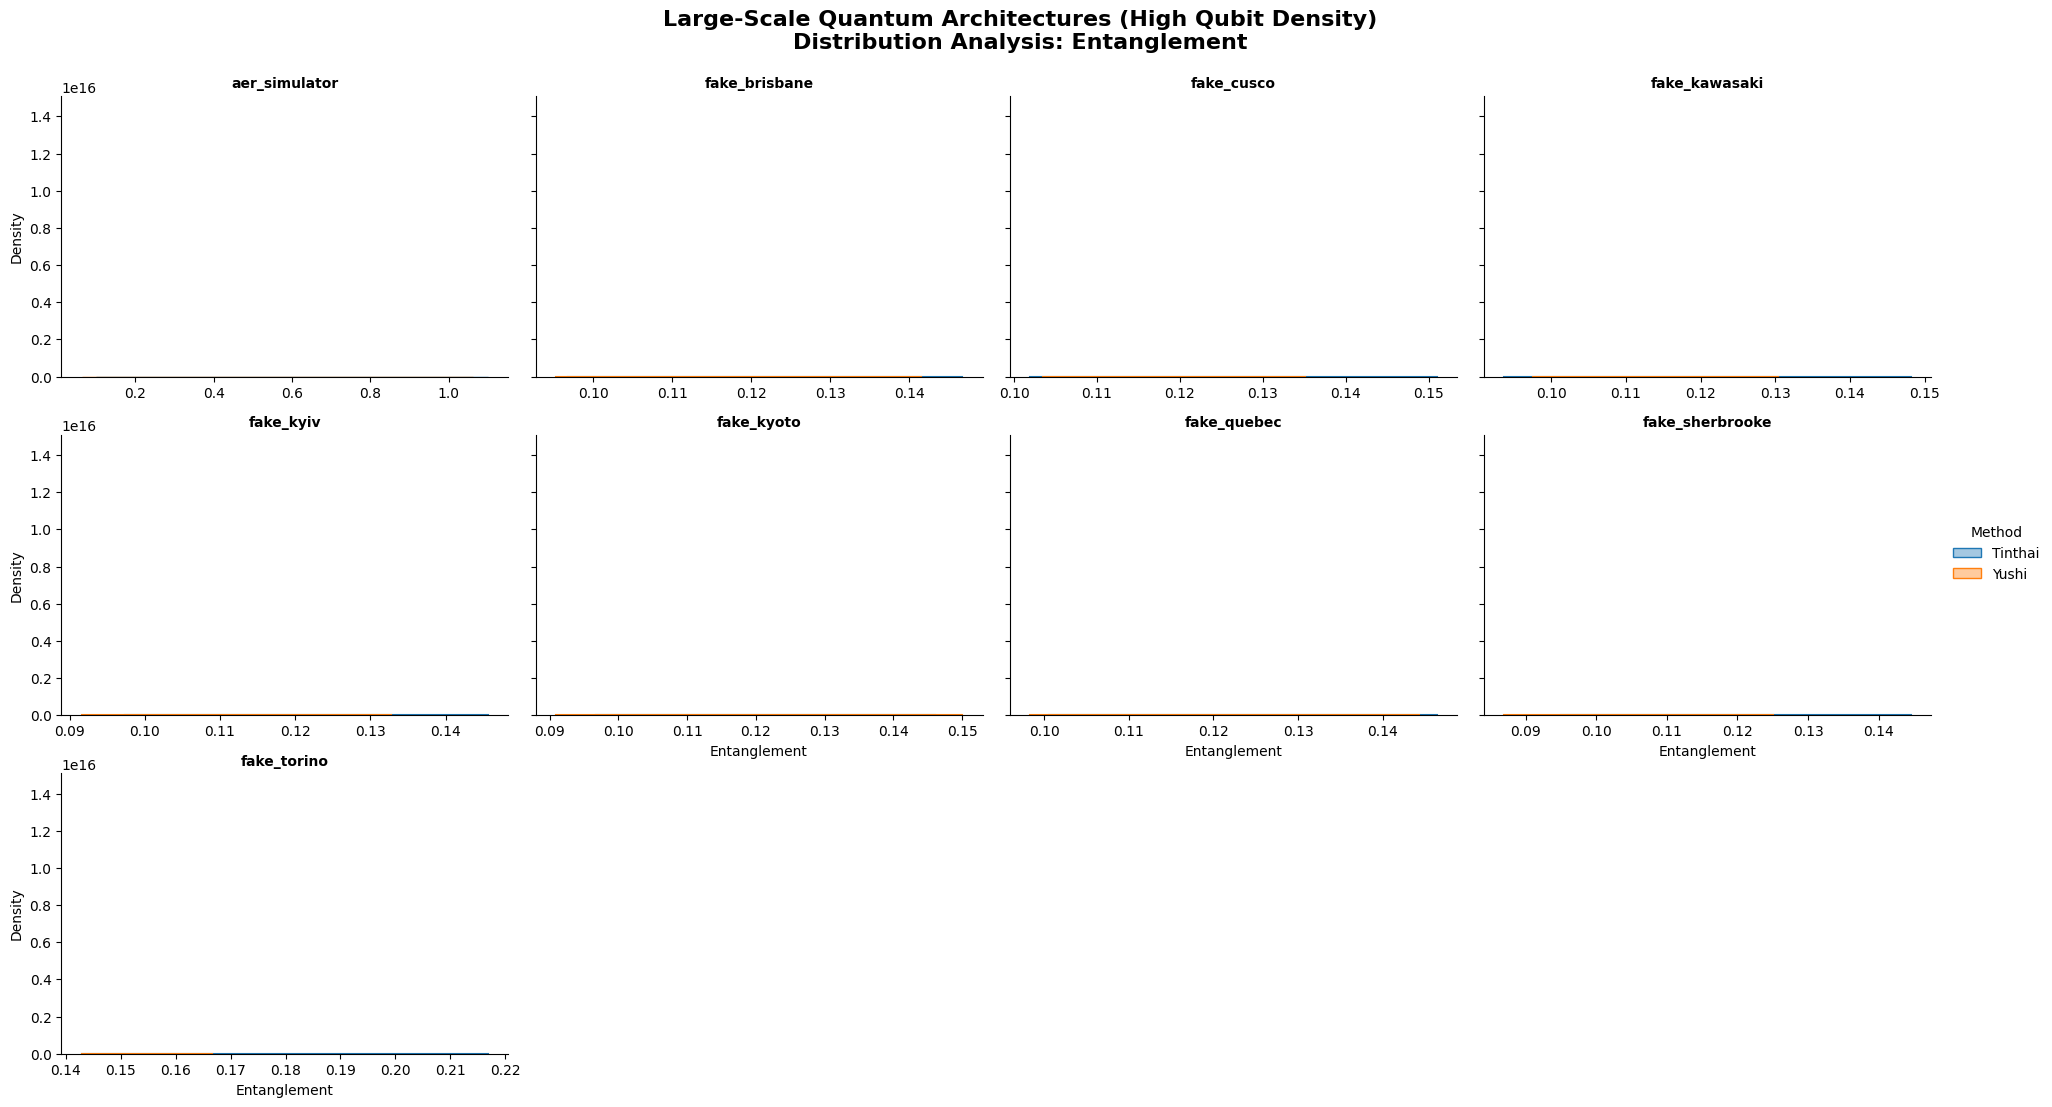

In [98]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# 1. เตรียมข้อมูล (Convert to Long Format)
# ==========================================
long_data = []

# ตรวจสอบว่ามี df_raw อยู่ไหม
if 'df_raw' in locals() and not df_raw.empty:
    for _, row in df_raw.iterrows():
        backend = row['backend']
        
        # Mapping ข้อมูล
        long_data.append({'Backend': backend, 'Metric': 'Program Comm', 'Method': 'Tinthai', 'Value': row['Tinthai_PC']})
        long_data.append({'Backend': backend, 'Metric': 'Program Comm', 'Method': 'Yushi',   'Value': row['Yushi_PC']})
        
        long_data.append({'Backend': backend, 'Metric': 'Circuit Depth', 'Method': 'Tinthai', 'Value': row['Tinthai_CD']})
        long_data.append({'Backend': backend, 'Metric': 'Circuit Depth', 'Method': 'Yushi',   'Value': row['Yushi_CD']})
        
        long_data.append({'Backend': backend, 'Metric': 'Entanglement',  'Method': 'Tinthai', 'Value': row['Tinthai_EN']})
        long_data.append({'Backend': backend, 'Metric': 'Entanglement',  'Method': 'Yushi',   'Value': row['Yushi_EN']})

    df_long = pd.DataFrame(long_data)
    print(f"Data Prepared: {len(df_long)} rows")
else:
    print("❌ Error: ไม่พบตัวแปร df_raw")

# ==========================================
# 2. แยกประเภท Backend (Categorization)
# ==========================================
# ใช้ตัวเล็ก (lowercase) ให้ตรงกับ backend.name
medium_backends_list = [
    'aer_simulator', 'fake_auckland', 'fake_algiers', 'fake_hanoi', 'fake_peekskill',
    'fake_lagos', 'fake_nairobi' # ใส่เพิ่มให้ครบตามกลุ่ม qubit ใกล้เคียงกัน
]

large_backends_list = [
    'aer_simulator', 'fake_brisbane', 'fake_cusco', 'fake_kawasaki', 'fake_kyiv',
    'fake_kyoto', 'fake_quebec', 'fake_sherbrooke', 'fake_torino'
]

# แยก DataFrame
df_medium = df_long[df_long['Backend'].isin(medium_backends_list)]
df_large = df_long[df_long['Backend'].isin(large_backends_list)]

print(f"Medium-Scale Data: {len(df_medium)} rows")
print(f"Large-Scale Data: {len(df_large)} rows")

# กำหนดสี
colors = {'Tinthai': '#1f77b4', 'Yushi': '#ff7f0e'}
metrics_list = ['Program Comm', 'Circuit Depth', 'Entanglement']

# ==========================================
# 3. สร้างฟังก์ชันสำหรับ Plot (จะได้ใช้ซ้ำได้)
# ==========================================
def plot_category_analysis(df_subset, category_title):
    if df_subset.empty:
        print(f"⚠️ No data for {category_title}")
        return

    print(f"\n{'='*80}")
    print(f">>> Processing: {category_title}")
    print(f"{'='*80}")

    # --- PART A: BOX PLOTS (Side-by-Side per Backend) ---
    for metric in metrics_list:
        plt.figure(figsize=(18, 7)) # ปรับขนาดให้เหมาะกับจำนวนเครื่อง
        
        data_metric = df_subset[df_subset['Metric'] == metric]
        
        # Boxplot
        sns.boxplot(data=data_metric, x='Backend', y='Value', hue='Method', 
                    palette=colors, showfliers=False, linewidth=1.2)
        
        plt.title(f'{category_title}\nMetric Analysis: {metric} (Box Plot)', fontsize=15, fontweight='bold', pad=15)
        plt.ylabel(f'{metric} Value', fontsize=12)
        plt.xlabel('Quantum Backend Processor', fontsize=12)
        plt.xticks(rotation=45, ha='right', fontsize=11)
        plt.grid(axis='y', alpha=0.3, linestyle='--')
        plt.legend(title='Compilation Method', loc='upper right')
        plt.tight_layout()
        plt.show()

    # --- PART B: DISTRIBUTION GRIDS (FacetGrid) ---
    for metric in metrics_list:
        print(f"Generating Distribution Grid for {metric} ({category_title})...")
        
        data_metric = df_subset[df_subset['Metric'] == metric]
        
        # ปรับ col_wrap ตามจำนวนข้อมูล (Large เยอะกว่าอาจจะขยายแถว)
        n_cols = 4 
        
        g = sns.FacetGrid(data_metric, col="Backend", hue="Method", 
                          col_wrap=n_cols, height=3.5, aspect=1.4, palette=colors, sharex=False)
        
        # Map Histplot + KDE
        g.map(sns.histplot, "Value", kde=True, stat="density", common_norm=False, alpha=0.4, element="step")
        
        # Customize
        g.add_legend(title="Method")
        g.fig.suptitle(f'{category_title}\nDistribution Analysis: {metric}', fontsize=16, y=1.05, fontweight='bold')
        
        g.set_axis_labels(f"{metric}", "Density")
        g.set_titles("{col_name}", fontweight='bold')
        
        plt.show()

# ==========================================
# 4. เรียกใช้งานฟังก์ชัน (Execution)
# ==========================================

# 4.1 Plot สำหรับ Medium-Scale
plot_category_analysis(df_medium, "Medium-Scale Quantum Architectures (Intermediate Qubit Density)")

# 4.2 Plot สำหรับ Large-Scale
plot_category_analysis(df_large, "Large-Scale Quantum Architectures (High Qubit Density)")